# E-commerce Product Analysis Project

The following analysis is performed on dataset from Kaggle.

##### Credits:

https://www.kaggle.com/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop

https://rees46.com/

**Project goal is to analyze user behavior in an e-commerce cosmetics shop and identify factors associated with successful purchases.**

## Business Context

The dataset contains user event history from an online cosmetics store.

Users interact with products through several types of events:

view — product viewed;
cart — product added to cart;
remove_from_cart — product removed from cart;
purchase — product purchased.

The business wants to understand:

*How do users move through the shopping funnel, where are potential customers lost, and what user/product characteristics are associated with a higher probability of purchase?*

The final goal is **to identify product opportunities that could potentially improve purchase conversion.**

## Import Required Python Libraries

In [63]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

## Dataset Installation

In [2]:
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

dataset_path = kagglehub.dataset_download(
    "mkechinov/ecommerce-events-history-in-cosmetics-shop",
    output_dir=str(data_dir.resolve()),
)

print(f"Dataset downloaded to: {dataset_path}")

Dataset downloaded to: /Users/likanikolaidi/ecommerce-product-analysis/data


## Dataset Properties Description

**event_time**	Time when event happened at (in UTC).

**event_type**	Four kinds of event: purchase, cart, view, remove_from_cart.

**product_id**	ID of a product

**category_id**	Product's category ID

**category_code**	Product's category taxonomy (code name) if it was possible to make it. Usually present for meaningful categories and skipped for different kinds of accessories.

**brand**	Downcased string of brand name. Can be missed.

**price**	Float price of a product. Present.

**user_id**	Permanent user ID.

**user_session**  Temporary user's session ID. Same for each user's session. Is changed every time user come back to online store from a long pause.

## Data Inspection

In [3]:
csv_files = sorted(data_dir.rglob("*.csv"))
for file in csv_files:
    print(file.name, f"{file.stat().st_size / 1e9:.2f} GB")

2019-Dec.csv 0.42 GB
2019-Nov.csv 0.55 GB
2019-Oct.csv 0.48 GB
2020-Feb.csv 0.49 GB
2020-Jan.csv 0.50 GB


In [4]:
sample = pd.read_csv(csv_files[0], nrows=100_000)
sample.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00 UTC,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18
2,2019-12-01 00:00:02 UTC,cart,4958,1487580009471148064,NaN,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554
3,2019-12-01 00:00:05 UTC,view,5848413,1487580007675986893,NaN,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4
4,2019-12-01 00:00:07 UTC,view,5824148,1487580005511725929,NaN,NaN,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5


In [5]:
# inspecting the sample
print(sample.shape)
print(sample.columns)
print(sample.dtypes)
print(sample.isna().sum())

(100000, 9)
Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='str')
event_time           str
event_type           str
product_id         int64
category_id        int64
category_code        str
brand                str
price            float64
user_id            int64
user_session         str
dtype: object
event_time           0
event_type           0
product_id           0
category_id          0
category_code    98309
brand            43558
price                0
user_id              0
user_session        43
dtype: int64


For the computational resource economy the whole exploratory pipline will be first set up for one month data only

In [6]:
oct_df = pd.read_csv("data/2019-Oct.csv")
oct_df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,cart,5773203,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
1,2019-10-01 00:00:03 UTC,cart,5773353,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
2,2019-10-01 00:00:07 UTC,cart,5881589,2151191071051219817,NaN,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9
3,2019-10-01 00:00:07 UTC,cart,5723490,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
4,2019-10-01 00:00:15 UTC,cart,5881449,1487580013522845895,NaN,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9


## Data Quality Checks

Includes duplicates, date range, event types, and counts of unique users, sessions, products, categories, and brands.

In [7]:
df = oct_df

In [8]:
EXPECTED_COLUMNS = {
    "event_time",
    "event_type",
    "product_id",
    "category_id",
    "category_code",
    "brand",
    "price",
    "user_id",
    "user_session",
}

EXPECTED_EVENT_TYPES = {
    "view",
    "cart",
    "remove_from_cart",
    "purchase",
}


def run_data_quality_checks(df):
    missing_columns = EXPECTED_COLUMNS - set(df.columns)

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    event_time = pd.to_datetime(
        df["event_time"],
        errors="coerce",
        utc=True,
    )

    overview = pd.Series({
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": df.duplicated().sum(),
        "invalid_event_times": event_time.isna().sum(),
        "date_min": event_time.min(),
        "date_max": event_time.max(),
        "unique_users": df["user_id"].nunique(dropna=True),
        "unique_sessions": df["user_session"].nunique(dropna=True),
        "unique_products": df["product_id"].nunique(dropna=True),
        "unique_categories": df["category_id"].nunique(dropna=True),
        "unique_brands": df["brand"].nunique(dropna=True),
        "non_positive_prices": df["price"].le(0).sum(),
    }, name="value")

    missing_values = (
        pd.DataFrame({
            "missing_count": df.isna().sum(),
            "missing_percent": df.isna().mean().mul(100),
        })
        .sort_values("missing_percent", ascending=False)
    )

    data_types = df.dtypes.rename("data_type").to_frame()

    event_distribution = (
        df["event_type"]
        .value_counts(dropna=False)
        .rename_axis("event_type")
        .to_frame("event_count")
    )
    event_distribution["percent"] = (
        event_distribution["event_count"]
        .div(len(df))
        .mul(100)
    )

    unexpected_events = sorted(
        set(df["event_type"].dropna().unique())
        - EXPECTED_EVENT_TYPES
    )

    return {
        "overview": overview,
        "data_types": data_types,
        "missing_values": missing_values,
        "event_distribution": event_distribution,
        "unexpected_events": unexpected_events,
    }

In [9]:
quality_report = run_data_quality_checks(df)

display(quality_report["overview"])
display(quality_report["data_types"])
display(quality_report["missing_values"])
display(quality_report["event_distribution"])

print(
    "Unexpected event types:",
    quality_report["unexpected_events"],
)

rows                                     4102283
columns                                        9
duplicate_rows                            213155
invalid_event_times                            0
date_min               2019-10-01 00:00:00+00:00
date_max               2019-10-31 23:59:54+00:00
unique_users                              399664
unique_sessions                           873960
unique_products                            41899
unique_categories                            490
unique_brands                                240
non_positive_prices                         6086
Name: value, dtype: object

,data_type
event_time,str
event_type,str
product_id,int64
category_id,int64
category_code,str
brand,str
price,float64
user_id,int64
user_session,str


,missing_count,missing_percent
category_code,4034806,98.355135
brand,1659261,40.447258
user_session,637,0.015528
event_time,0,0.000000
event_type,0,0.000000
category_id,0,0.000000
product_id,0,0.000000
price,0,0.000000
user_id,0,0.000000


,event_count,percent
event_type,,
view,1862164,45.393358
cart,1232385,30.041443
remove_from_cart,762110,18.577704
purchase,245624,5.987495


Unexpected event types: []


### Investigating questionable records

These records' analysis include duplicate rows (which can legitimately occur) and invalid (negative) prices.

In [10]:
duplicate_mask = df.duplicated(keep=False)

display(
    df.loc[duplicate_mask, "event_type"]
    .value_counts()
    .to_frame("rows_in_duplicate_groups")
)

display(
    df.loc[duplicate_mask]
    .sort_values(
        ["user_id", "user_session", "product_id", "event_time"]
    )
    .head(30)
)

,rows_in_duplicate_groups
event_type,
remove_from_cart,363653
cart,53670
purchase,686
view,228


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
137746,2019-10-01 22:06:07 UTC,remove_from_cart,5739036,1487580008246412266,NaN,kapous,3.32,8846226,ddd23270-792c-49f3-9ae2-d86f5080a5eb
137748,2019-10-01 22:06:07 UTC,remove_from_cart,5739036,1487580008246412266,NaN,kapous,3.32,8846226,ddd23270-792c-49f3-9ae2-d86f5080a5eb
137684,2019-10-01 22:05:27 UTC,remove_from_cart,5812138,1487580013413793985,NaN,art-visage,4.68,8846226,ddd23270-792c-49f3-9ae2-d86f5080a5eb
137685,2019-10-01 22:05:27 UTC,remove_from_cart,5812138,1487580013413793985,NaN,art-visage,4.68,8846226,ddd23270-792c-49f3-9ae2-d86f5080a5eb
266253,2019-10-02 14:43:55 UTC,remove_from_cart,5709126,1487580011752849537,NaN,elskin,4.21,8846226,f835c9a8-cb8a-4201-85d4-00565bcc84ad
266256,2019-10-02 14:43:55 UTC,remove_from_cart,5709126,1487580011752849537,NaN,elskin,4.21,8846226,f835c9a8-cb8a-4201-85d4-00565bcc84ad
266393,2019-10-02 14:44:45 UTC,remove_from_cart,5823668,1487580008246412266,NaN,kapous,7.60,8846226,f835c9a8-cb8a-4201-85d4-00565bcc84ad
266396,2019-10-02 14:44:45 UTC,remove_from_cart,5823668,1487580008246412266,NaN,kapous,7.60,8846226,f835c9a8-cb8a-4201-85d4-00565bcc84ad
3535082,2019-10-27 16:00:04 UTC,remove_from_cart,5807805,1487580005713052531,NaN,ingarden,4.44,10280338,fbacb4a3-2141-4f43-b9e5-97c911c7e770
3535083,2019-10-27 16:00:04 UTC,remove_from_cart,5807805,1487580005713052531,NaN,ingarden,4.44,10280338,fbacb4a3-2141-4f43-b9e5-97c911c7e770


In [11]:
invalid_prices = df.loc[df["price"] <= 0]

display(invalid_prices["price"].describe())
display(invalid_prices["event_type"].value_counts())
display(invalid_prices.sample(5))
display(invalid_prices.loc[invalid_prices["price"] <= -20])

count    6086.000000
mean       -0.091285
std         1.906700
min       -79.370000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.000000
Name: price, dtype: float64

event_type
view                5372
cart                 540
remove_from_cart     154
purchase              20
Name: count, dtype: int64

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
1907354,2019-10-14 15:09:49 UTC,view,5893077,1487580013388628160,NaN,NaN,0.0,478982345,f7c4a338-721f-4835-a18b-7757cb6b557c
2712597,2019-10-21 06:16:48 UTC,view,5896443,1487580007575323592,NaN,NaN,0.0,553753653,912d8dac-9929-414c-a59e-5f0fcbfa5302
419487,2019-10-03 14:42:55 UTC,view,5892741,1487580010242900029,NaN,NaN,0.0,553753653,86b227fd-f3aa-44e8-b332-f16bfa7a0ec9
2699752,2019-10-21 00:39:31 UTC,view,5896494,1487580013732561106,NaN,NaN,0.0,385864576,122bf7b3-03ba-40a6-8efa-af45faf3bc23
1358856,2019-10-10 05:29:43 UTC,view,5893487,1487580011702517887,NaN,NaN,0.0,539462974,9fbcc59a-5622-7f55-48ee-7e23801d82f9


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
112860,2019-10-01 19:10:56 UTC,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,552507528,dcdd60c6-1a70-442d-bfb2-0252879054ad
436918,2019-10-03 17:37:04 UTC,purchase,5716859,1487580014042939619,NaN,NaN,-47.62,555414763,479149eb-1807-4178-8f6b-87c642350735
1519246,2019-10-11 10:27:19 UTC,purchase,5716859,1487580014042939619,NaN,NaN,-47.62,543647038,85e11d74-6583-4eab-b50c-ff86dbb25d97
1783312,2019-10-13 16:46:01 UTC,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,559820267,f178c995-f004-4040-b26d-b1cca0f9657d
1924072,2019-10-14 17:33:24 UTC,purchase,5716861,1487580014042939619,NaN,NaN,-79.37,541122983,b60f777d-afca-4299-8548-273b810d6130
2143762,2019-10-16 11:41:06 UTC,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,461943726,beefa8fb-a3d1-48ca-97e9-9c95b05ee997
3135434,2019-10-24 08:10:06 UTC,purchase,5716859,1487580014042939619,NaN,NaN,-47.62,545859098,95ed1875-cb64-443d-90bb-17d0dc596c10
3502423,2019-10-27 11:24:32 UTC,purchase,5716859,1487580014042939619,NaN,NaN,-47.62,564627373,81d564e9-55b3-4929-9132-6353cab08a97
3608726,2019-10-28 07:41:54 UTC,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,385939606,2255291d-8060-4ce9-934c-458a3bd0b944
3798007,2019-10-29 14:34:24 UTC,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,554081558,4b84a8f9-97d7-4eb1-b120-7b34ddfe9a85


This analysis provides following conclusions:

- The concentration of duplicate rows in cart-removal events suggests these may represent quantity changes or repeated actions rather than random file duplication. Because timestamps only have one-second precision, two legitimate events can also appear identical.

- Zero-price rows often also lack brand/category information, suggesting incomplete product-catalog records. Negative purchase prices are more concerning, but the dataset does not provide enough evidence to classify them as returns, discounts, or errors and the amount of these rows is relatively small.

## Cleaning Pipeline

In [12]:
def clean_event_data(raw_df, drop_exact_duplicates=False):
    clean_df = raw_df.copy()

    # Parse timestamps consistently as UTC
    clean_df["event_time"] = pd.to_datetime(
        clean_df["event_time"],
        errors="coerce",
        utc=True,
    )

    # Standardize text values
    text_columns = ["event_type", "category_code", "brand", "user_session"]

    for column in text_columns:
        clean_df[column] = (
            clean_df[column]
            .astype("string")
            .str.strip()
        )
        clean_df[column] = clean_df[column].mask(
            clean_df[column].eq(""),
            pd.NA,
        )

    clean_df["event_type"] = clean_df["event_type"].str.lower()
    clean_df["brand"] = clean_df["brand"].str.lower()
    clean_df["category_code"] = clean_df["category_code"].str.lower()

    # Validate essential fields
    essential_columns = [
        "event_time",
        "event_type",
        "product_id",
        "category_id",
        "price",
        "user_id",
    ]

    clean_df = clean_df.dropna(subset=essential_columns)

    # Flag valid prices
    clean_df["is_valid_price"] = clean_df["price"] > 0

    # Useful time fields for later aggregation
    clean_df["event_date"] = clean_df["event_time"].dt.floor("D")
    clean_df["event_month"] = (
    clean_df["event_time"]
    .dt.tz_localize(None)
    .dt.to_period("M")
)

    # Duplicate removal remains optional
    if drop_exact_duplicates:
        clean_df = clean_df.drop_duplicates(ignore_index=True)

    return clean_df

In [13]:
clean_df = clean_event_data(
    df,
    drop_exact_duplicates=False,
)

clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4102283 entries, 0 to 4102282
Data columns (total 12 columns):
 #   Column          Dtype              
---  ------          -----              
 0   event_time      datetime64[us, UTC]
 1   event_type      string             
 2   product_id      int64              
 3   category_id     int64              
 4   category_code   string             
 5   brand           string             
 6   price           float64            
 7   user_id         int64              
 8   user_session    string             
 9   is_valid_price  bool               
 10  event_date      datetime64[us, UTC]
 11  event_month     period[M]          
dtypes: bool(1), datetime64[us, UTC](2), float64(1), int64(3), period[M](1), string(4)
memory usage: 348.2 MB


## Event Overview

This section measures total recorded activity, number of recorded event rows by event type.

In [14]:
EVENT_ORDER = [
    "view",
    "cart",
    "remove_from_cart",
    "purchase",
]

event_overview = (
    df.groupby("event_type")
    .agg(
        event_count=("event_type", "size"),
        unique_users=("user_id", "nunique"),
        unique_sessions=("user_session", "nunique"),
    )
    .reindex(EVENT_ORDER)
    .reset_index()
)

event_overview["event_percent"] = (
    event_overview["event_count"]
    .div(event_overview["event_count"].sum())
    .mul(100)
)

event_overview

display(
    event_overview.style.format({
        "event_count": "{:,.0f}",
        "event_percent": "{:.2f}%",
        "unique_users": "{:,.0f}",
        "unique_sessions": "{:,.0f}",
    })
)

,event_type,event_count,unique_users,unique_sessions,event_percent
0,view,"1,862,164","388,331","826,147",45.39%
1,cart,"1,232,385","133,818","228,145",30.04%
2,remove_from_cart,"762,110","47,090","91,973",18.58%
3,purchase,"245,624","25,762","29,326",5.99%


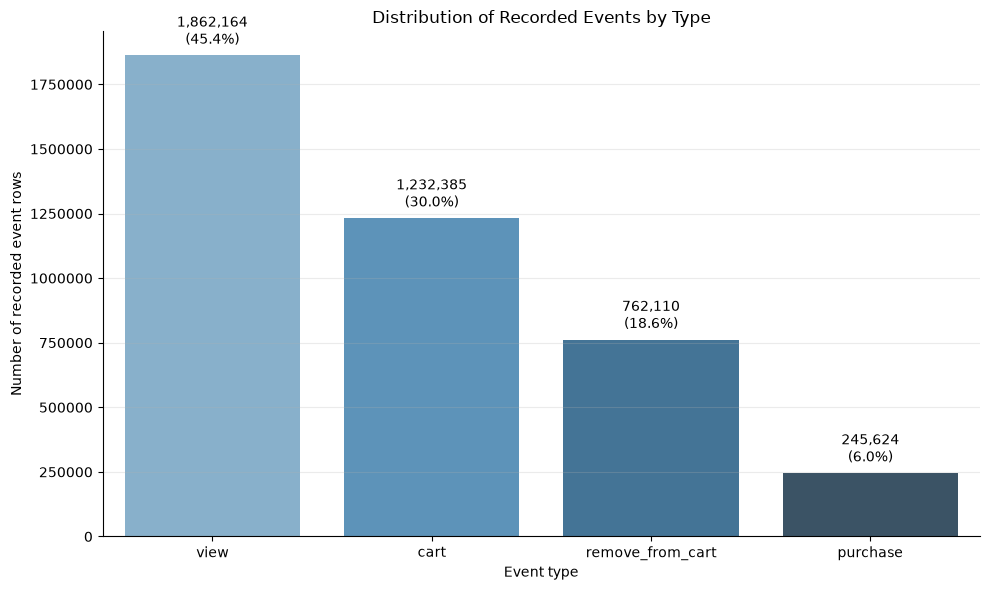

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=event_overview,
    x="event_type",
    y="event_count",
    hue="event_type",
    order=EVENT_ORDER,
    palette="Blues_d",
    legend=False,
    ax=ax,
)

for bar, row in zip(ax.patches, event_overview.itertuples()):
    ax.annotate(
        f"{row.event_count:,.0f}\n({row.event_percent:.1f}%)",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("Distribution of Recorded Events by Type")
ax.set_xlabel("Event type")
ax.set_ylabel("Number of recorded event rows")
ax.ticklabel_format(style="plain", axis="y")
ax.grid(axis="y", alpha=0.25)

sns.despine()
plt.tight_layout()
plt.show()

#### Duplicate Sensivity Check

The exact duplicates were not excluded from the counts above, so additional check is required.

In [16]:
deduplicated_counts = (
    df.drop_duplicates()
    ["event_type"]
    .value_counts()
    .reindex(EVENT_ORDER)
)

duplicate_sensitivity = (
    event_overview[
        ["event_type", "event_count"]
    ]
    .set_index("event_type")
    .rename(columns={"event_count": "raw_event_rows"})
)

duplicate_sensitivity["exact_deduplicated_rows"] = (
    deduplicated_counts
)

duplicate_sensitivity["excess_rows"] = (
    duplicate_sensitivity["raw_event_rows"]
    - duplicate_sensitivity["exact_deduplicated_rows"]
)

duplicate_sensitivity["excess_percent"] = (
    duplicate_sensitivity["excess_rows"]
    .div(duplicate_sensitivity["raw_event_rows"])
    .mul(100)
)

display(
    duplicate_sensitivity.style.format({
        "raw_event_rows": "{:,.0f}",
        "exact_deduplicated_rows": "{:,.0f}",
        "excess_rows": "{:,.0f}",
        "excess_percent": "{:.2f}%",
    })
)

,raw_event_rows,exact_deduplicated_rows,excess_rows,excess_percent
event_type,,,,
view,"1,862,164","1,862,050",114,0.01%
cart,"1,232,385","1,204,218","28,167",2.29%
remove_from_cart,"762,110","577,579","184,531",24.21%
purchase,"245,624","245,281",343,0.14%


Views are the most frequent recorded event, followed by cart and remove-from-cart events. Purchases represent the smallest share. These event percentages are not conversion rates because users and sessions can generate repeated events. Exact duplicates are especially concentrated in cart-removal activity, so raw counts are retained while the deduplicated results are reported as a sensitivity check.

## Product Funnel

This section uses a strict, ordered user-product funnel. Each (user_id, product_id) pair is counted once, regardless of repeated events.

The funnel unit is a user-product interaction during the observation period. A pair reaches cart only if a cart event occurs after its view, and reaches purchase only if a purchase occurs after that cart.

#### Prepare ordered funnel events

In [17]:
FUNNEL_EVENTS = ["view", "cart", "purchase"]
FUNNEL_KEYS = ["user_id", "product_id"]

funnel_events = (
    df.loc[
        df["event_type"].isin(FUNNEL_EVENTS),
        FUNNEL_KEYS + ["event_time", "event_type"],
    ]
    .copy()
)

funnel_events["event_time"] = pd.to_datetime(
    funnel_events["event_time"],
    errors="coerce",
    utc=True,
)

funnel_events = (
    funnel_events
    .dropna(subset=FUNNEL_KEYS + ["event_time", "event_type"])
    .sort_values("event_time", kind="stable")
    .reset_index(drop=True)
)

# Provides an unambiguous order when events share a timestamp.
funnel_events["event_order"] = np.arange(len(funnel_events))

#### Finding the first view for each pair

In [18]:
first_views = (
    funnel_events.loc[
        funnel_events["event_type"].eq("view")
    ]
    .drop_duplicates(FUNNEL_KEYS, keep="first")
    [FUNNEL_KEYS + ["event_time", "event_order"]]
    .rename(columns={
        "event_time": "first_view_time",
        "event_order": "first_view_order",
    })
)
first_views.head()

,user_id,product_id,first_view_time,first_view_order
9,474232307,5875317,2019-10-01 00:00:26+00:00,9
10,555446068,5692917,2019-10-01 00:00:28+00:00,10
14,546705258,5819638,2019-10-01 00:00:48+00:00,14
16,507355498,5856191,2019-10-01 00:00:53+00:00,16
22,543446752,5733176,2019-10-01 00:01:11+00:00,22


Every row in first_views represents one funnel unit.

#### Finding the first cart after the view

In [19]:
cart_candidates = (
    funnel_events.loc[
        funnel_events["event_type"].eq("cart")
    ]
    .merge(
        first_views[
            FUNNEL_KEYS + ["first_view_order"]
        ],
        on=FUNNEL_KEYS,
        how="inner",
    )
)

cart_candidates = cart_candidates.loc[
    cart_candidates["event_order"]
    > cart_candidates["first_view_order"]
]

first_carts = (
    cart_candidates
    .sort_values("event_order")
    .drop_duplicates(FUNNEL_KEYS, keep="first")
    [FUNNEL_KEYS + ["event_time", "event_order"]]
    .rename(columns={
        "event_time": "first_cart_time",
        "event_order": "first_cart_order",
    })
)

first_carts.head()

,user_id,product_id,first_cart_time,first_cart_order
9,474232307,5875317,2019-10-01 00:01:13+00:00,24
13,520558067,5597836,2019-10-01 00:02:08+00:00,41
14,546705258,5775980,2019-10-01 00:02:57+00:00,59
16,401329661,5852507,2019-10-01 00:03:26+00:00,69
17,429681830,5881589,2019-10-01 00:03:31+00:00,70


An earlier cart without a preceding view does not qualify, but a later cart after a view does.

#### Finding the first purchase after cart

In [20]:
purchase_candidates = (
    funnel_events.loc[
        funnel_events["event_type"].eq("purchase")
    ]
    .merge(
        first_carts[
            FUNNEL_KEYS + ["first_cart_order"]
        ],
        on=FUNNEL_KEYS,
        how="inner",
    )
)

purchase_candidates = purchase_candidates.loc[
    purchase_candidates["event_order"]
    > purchase_candidates["first_cart_order"]
]

first_purchases = (
    purchase_candidates
    .sort_values("event_order")
    .drop_duplicates(FUNNEL_KEYS, keep="first")
    [FUNNEL_KEYS + ["event_time", "event_order"]]
    .rename(columns={
        "event_time": "first_purchase_time",
        "event_order": "first_purchase_order",
    })
)

first_purchases.head()

,user_id,product_id,first_purchase_time,first_purchase_order
0,474232307,5875317,2019-10-01 00:06:35+00:00,146
7,385985999,5587756,2019-10-01 00:21:42+00:00,539
8,385985999,5692866,2019-10-01 00:21:42+00:00,540
9,509896854,5884577,2019-10-01 00:40:00+00:00,796
10,446404021,5849033,2019-10-01 00:55:17+00:00,1017


#### Assembling the funnel table

Repeated views, carts, or purchases do not inflate the funnel because each pair has only one row.

In [21]:
user_product_funnel = (
    first_views
    .merge(
        first_carts,
        on=FUNNEL_KEYS,
        how="left",
    )
    .merge(
        first_purchases,
        on=FUNNEL_KEYS,
        how="left",
    )
)

user_product_funnel["reached_view"] = True
user_product_funnel["reached_cart"] = (
    user_product_funnel["first_cart_time"].notna()
)
user_product_funnel["reached_purchase"] = (
    user_product_funnel["first_purchase_time"].notna()
)

user_product_funnel.head()

,user_id,product_id,first_view_time,first_view_order,first_cart_time,first_cart_order,first_purchase_time,first_purchase_order,reached_view,reached_cart,reached_purchase
0,474232307,5875317,2019-10-01 00:00:26+00:00,9,2019-10-01 00:01:13+00:00,24.0,2019-10-01 00:06:35+00:00,146.0,True,True,True
1,555446068,5692917,2019-10-01 00:00:28+00:00,10,NaT,NaN,NaT,NaN,True,False,False
2,546705258,5819638,2019-10-01 00:00:48+00:00,14,NaT,NaN,NaT,NaN,True,False,False
3,507355498,5856191,2019-10-01 00:00:53+00:00,16,NaT,NaN,NaT,NaN,True,False,False
4,543446752,5733176,2019-10-01 00:01:11+00:00,22,NaT,NaN,NaT,NaN,True,False,False


#### Calculating stage counts and conversion

In [22]:
view_count = len(user_product_funnel)

cart_count = (
    user_product_funnel["reached_cart"].sum()
)

purchase_count = (
    user_product_funnel["reached_purchase"].sum()
)

view_to_cart = (
    cart_count / view_count
    if view_count
    else np.nan
)

cart_to_purchase = (
    purchase_count / cart_count
    if cart_count
    else np.nan
)

view_to_purchase = (
    purchase_count / view_count
    if view_count
    else np.nan
)

conversion_metrics = pd.DataFrame({
    "metric": [
        "View → Cart",
        "Cart → Purchase",
        "View → Purchase",
    ],
    "numerator": [
        cart_count,
        purchase_count,
        purchase_count,
    ],
    "denominator": [
        view_count,
        cart_count,
        view_count,
    ],
    "conversion_rate": [
        view_to_cart,
        cart_to_purchase,
        view_to_purchase,
    ],
})

display(
    conversion_metrics.style.format({
        "numerator": "{:,.0f}",
        "denominator": "{:,.0f}",
        "conversion_rate": "{:.2%}",
    })
)

,metric,numerator,denominator,conversion_rate
0,View → Cart,"226,240","1,402,922",16.13%
1,Cart → Purchase,"55,353","226,240",24.47%
2,View → Purchase,"55,353","1,402,922",3.95%


#### Visualizing the funnel

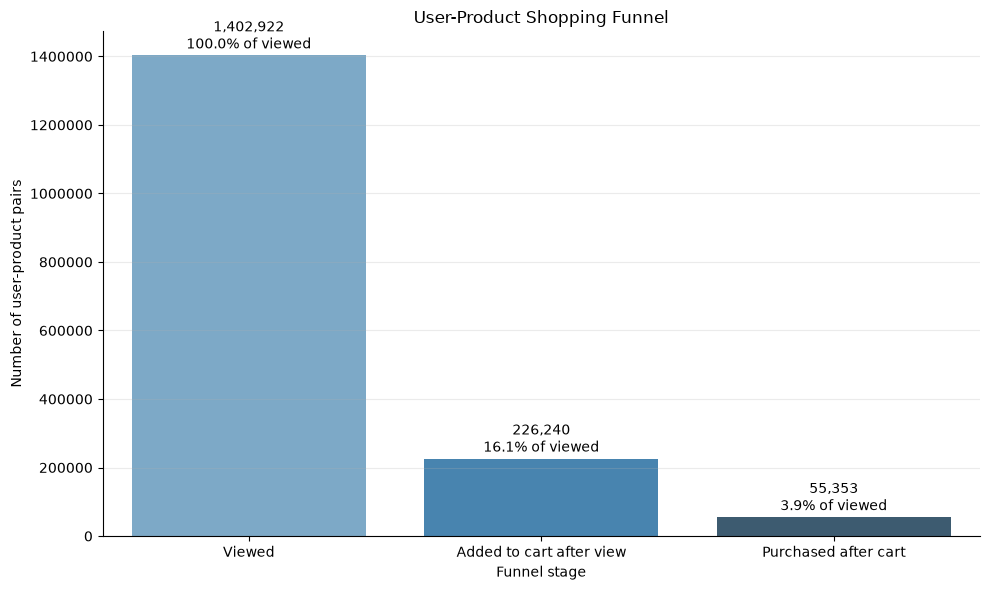

In [23]:
funnel_stages = pd.DataFrame({
    "stage": [
        "Viewed",
        "Added to cart after view",
        "Purchased after cart",
    ],
    "user_product_pairs": [
        view_count,
        cart_count,
        purchase_count,
    ],
})

funnel_stages["percent_of_viewed"] = (
    funnel_stages["user_product_pairs"]
    .div(view_count)
    .mul(100)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=funnel_stages,
    x="stage",
    y="user_product_pairs",
    hue="stage",
    palette="Blues_d",
    legend=False,
    ax=ax,
)

for bar, row in zip(ax.patches, funnel_stages.itertuples()):
    ax.annotate(
        (
            f"{row.user_product_pairs:,.0f}\n"
            f"{row.percent_of_viewed:.1f}% of viewed"
        ),
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
    )

ax.set_title("User-Product Shopping Funnel")
ax.set_xlabel("Funnel stage")
ax.set_ylabel("Number of user-product pairs")
ax.ticklabel_format(style="plain", axis="y")
ax.grid(axis="y", alpha=0.25)

sns.despine()
plt.tight_layout()
plt.show()

#### Metric interpretation
- View → Cart: among viewed user-product pairs, how many later reached cart. This measures whether product interest progresses to purchase intent.
- Cart → Purchase: among pairs that reached cart after viewing, how many were later purchased. This measures completion after purchase intent.
- View → Purchase: among viewed pairs, how many completed the entire ordered funnel. This is the end-to-end conversion rate.


The user-product funnel answers the question:

**How effectively does interest in a particular product lead to its purchase?**

So according to the key end-to-end metric the conversion rate is 3.95%.

## Session-Level Funnel

Defining the unit as one (user_id, user_session) pair. Repeated events are reduced to Boolean stage indicators.

#### Building session-level flags

In [24]:
SESSION_KEYS = ["user_id", "user_session"]

missing_session_rows = df["user_session"].isna().sum()

print(f"Rows excluded because session is missing: {missing_session_rows:,}")

Rows excluded because session is missing: 637


In [25]:
session_events = (
    df.loc[
        df["user_session"].notna(),
        SESSION_KEYS + ["event_type"],
    ]
    .copy()
)

session_events["has_view"] = (
    session_events["event_type"].eq("view")
)

session_events["has_cart"] = (
    session_events["event_type"].eq("cart")
)

session_events["has_purchase"] = (
    session_events["event_type"].eq("purchase")
)

session_funnel = (
    session_events
    .groupby(SESSION_KEYS, as_index=False)
    .agg(
        has_view=("has_view", "max"),
        has_cart=("has_cart", "max"),
        has_purchase=("has_purchase", "max"),
    )
)

session_funnel.head()

,user_id,user_session,has_view,has_cart,has_purchase
0,4103071,8930ec72-36b0-4be9-80c7-af93b9f477c6,True,True,False
1,8846226,ddd23270-792c-49f3-9ae2-d86f5080a5eb,True,True,False
2,8846226,f835c9a8-cb8a-4201-85d4-00565bcc84ad,True,True,False
3,9794320,1be8fa80-8036-4d95-93da-494a08d82cb5,True,True,False
4,9794320,9f8afcc5-abe6-47a6-93d5-290d350cea5e,True,False,False


#### Creating nested funnel stages

This is a presence-based funnel: the events must occur in the same session, but their exact order is not enforced.

In [26]:
session_funnel["reached_view"] = (
    session_funnel["has_view"]
)

session_funnel["reached_cart"] = (
    session_funnel["has_view"]
    & session_funnel["has_cart"]
)

session_funnel["reached_purchase"] = (
    session_funnel["has_view"]
    & session_funnel["has_cart"]
    & session_funnel["has_purchase"]
)

#### Calculating session conversion

In [27]:
session_view_count = (
    session_funnel["reached_view"].sum()
)

session_cart_count = (
    session_funnel["reached_cart"].sum()
)

session_purchase_count = (
    session_funnel["reached_purchase"].sum()
)

session_view_to_cart = (
    session_cart_count / session_view_count
    if session_view_count
    else np.nan
)

session_cart_to_purchase = (
    session_purchase_count / session_cart_count
    if session_cart_count
    else np.nan
)

session_view_to_purchase = (
    session_purchase_count / session_view_count
    if session_view_count
    else np.nan
)

session_conversion_metrics = pd.DataFrame({
    "metric": [
        "View → Cart",
        "Cart → Purchase",
        "View → Purchase",
    ],
    "numerator": [
        session_cart_count,
        session_purchase_count,
        session_purchase_count,
    ],
    "denominator": [
        session_view_count,
        session_cart_count,
        session_view_count,
    ],
    "conversion_rate": [
        session_view_to_cart,
        session_cart_to_purchase,
        session_view_to_purchase,
    ],
})

display(
    session_conversion_metrics.style.format({
        "numerator": "{:,.0f}",
        "denominator": "{:,.0f}",
        "conversion_rate": "{:.2%}",
    })
)

,metric,numerator,denominator,conversion_rate
0,View → Cart,"190,750","826,170",23.09%
1,Cart → Purchase,"20,487","190,750",10.74%
2,View → Purchase,"20,487","826,170",2.48%


#### Investigating sessions entering mid-funnel

Some sessions may contain cart or purchase events without a view.

In [28]:
session_entry_diagnostics = pd.Series({
    "all_sessions": len(session_funnel),
    "sessions_without_view": (
        ~session_funnel["has_view"]
    ).sum(),
    "cart_without_view": (
        session_funnel["has_cart"]
        & ~session_funnel["has_view"]
    ).sum(),
    "purchase_without_view": (
        session_funnel["has_purchase"]
        & ~session_funnel["has_view"]
    ).sum(),
    "purchase_without_cart": (
        session_funnel["has_purchase"]
        & ~session_funnel["has_cart"]
    ).sum(),
})

display(session_entry_diagnostics)

all_sessions             873984
sessions_without_view     47814
cart_without_view         37397
purchase_without_view      7127
purchase_without_cart      5135
dtype: int64

#### Visualizing the session funnels

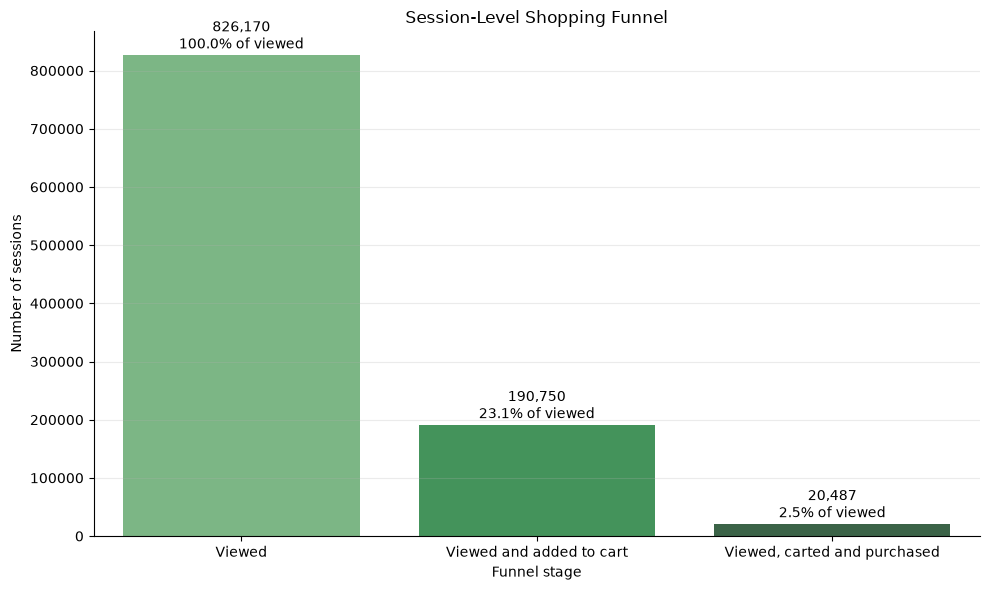

In [29]:
session_stages = pd.DataFrame({
    "stage": [
        "Viewed",
        "Viewed and added to cart",
        "Viewed, carted and purchased",
    ],
    "sessions": [
        session_view_count,
        session_cart_count,
        session_purchase_count,
    ],
})

session_stages["percent_of_viewed"] = (
    session_stages["sessions"]
    .div(session_view_count)
    .mul(100)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=session_stages,
    x="stage",
    y="sessions",
    hue="stage",
    palette="Greens_d",
    legend=False,
    ax=ax,
)

for bar, row in zip(ax.patches, session_stages.itertuples()):
    ax.annotate(
        f"{row.sessions:,.0f}\n"
        f"{row.percent_of_viewed:.1f}% of viewed",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
    )

ax.set_title("Session-Level Shopping Funnel")
ax.set_xlabel("Funnel stage")
ax.set_ylabel("Number of sessions")
ax.ticklabel_format(style="plain", axis="y")
ax.grid(axis="y", alpha=0.25)

sns.despine()
plt.tight_layout()
plt.show()

## Comparing both funnels

In [30]:
funnel_comparison = (
    conversion_metrics[
        ["metric", "conversion_rate"]
    ]
    .rename(columns={
        "conversion_rate": "user_product_rate"
    })
    .merge(
        session_conversion_metrics[
            ["metric", "conversion_rate"]
        ].rename(columns={
            "conversion_rate": "session_rate"
        }),
        on="metric",
        how="inner",
    )
)

funnel_comparison["difference_pp"] = (
    funnel_comparison["session_rate"]
    - funnel_comparison["user_product_rate"]
).mul(100)

display(
    funnel_comparison.style.format({
        "user_product_rate": "{:.2%}",
        "session_rate": "{:.2%}",
        "difference_pp": "{:+.2f} pp",
    })
)

,metric,user_product_rate,session_rate,difference_pp
0,View → Cart,16.13%,23.09%,+6.96 pp
1,Cart → Purchase,24.47%,10.74%,-13.73 pp
2,View → Purchase,3.95%,2.48%,-1.47 pp


Neither rate is inherently more correct as they measure different product questions.

The perspectives differ because:
- The user-product funnel requires progression for the same product, but events may span multiple sessions.
- The session funnel requires events within one visit, but the viewed, carted and purchased products can differ.
- A session can include many products and many repeated events.
- Some sessions begin at cart or purchase because earlier product activity occurred in another session.
- The session funnel has a shorter conversion window; the user-product funnel uses the entire observation period.

Important notice: in the future analysis user-product funnel is mostly going to be used as session funnel short conversion window in our case does not provide needed level of accuracy due to the limited amount of time included in the taken dataset.

## Conversion by Product Characteristics

This section is using the existing strict user_product_funnel. Product characteristics are coming from the pair’s first view so that they are measured at funnel entry.

In [31]:
from matplotlib.ticker import PercentFormatter

CHARACTERISTIC_COLUMNS = [
    "price",
    "category_id",
    "category_code",
    "brand",
]

first_view_characteristics = (
    df.loc[
        df["event_type"].eq("view"),
        FUNNEL_KEYS + ["event_time"] + CHARACTERISTIC_COLUMNS,
    ]
    .assign(
        event_time=lambda data: pd.to_datetime(
            data["event_time"],
            errors="coerce",
            utc=True,
        )
    )
    .dropna(subset=["event_time"])
    .sort_values("event_time", kind="stable")
    .drop_duplicates(FUNNEL_KEYS, keep="first")
    .rename(columns={
        "price": "view_price",
        "category_id": "view_category_id",
        "category_code": "view_category_code",
        "brand": "view_brand",
    })
)

characteristic_funnel = (
    user_product_funnel
    .merge(
        first_view_characteristics.drop(
            columns="event_time"
        ),
        on=FUNNEL_KEYS,
        how="left",
        validate="one_to_one",
    )
)

assert len(characteristic_funnel) == len(user_product_funnel)

In [32]:
def calculate_segment_conversion(data, segment):
    summary = (
        data.groupby(
            segment,
            observed=True,
            dropna=False,
        )
        .agg(
            viewed_pairs=("reached_view", "sum"),
            carted_pairs=("reached_cart", "sum"),
            purchased_pairs=("reached_purchase", "sum"),
        )
        .reset_index()
    )

    summary["view_to_cart"] = (
        summary["carted_pairs"]
        .div(summary["viewed_pairs"])
    )

    summary["cart_to_purchase"] = (
        summary["purchased_pairs"]
        .div(summary["carted_pairs"].replace(0, np.nan))
    )

    summary["view_to_purchase"] = (
        summary["purchased_pairs"]
        .div(summary["viewed_pairs"])
    )

    return summary

### Price analysis

#### Inspecting the price distribution

Inspecting prices at the user-product level, not across repeated event rows.

In [33]:
price_funnel = characteristic_funnel.loc[
    characteristic_funnel["view_price"] > 0
].copy()

invalid_price_pairs = (
    characteristic_funnel["view_price"] <= 0
).sum()

print(f"Valid-price pairs: {len(price_funnel):,}")
print(f"Non-positive-price pairs excluded: {invalid_price_pairs:,}")

display(
    price_funnel["view_price"].describe(
        percentiles=[
            0.01,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

Valid-price pairs: 1,398,705
Non-positive-price pairs excluded: 4,217


count    1.398705e+06
mean     1.215032e+01
std      2.504162e+01
min      5.000000e-02
1%       4.000000e-01
10%      1.430000e+00
25%      2.780000e+00
50%      5.060000e+00
75%      1.000000e+01
90%      2.357000e+01
95%      5.000000e+01
99%      1.377800e+02
max      3.076000e+02
Name: view_price, dtype: float64

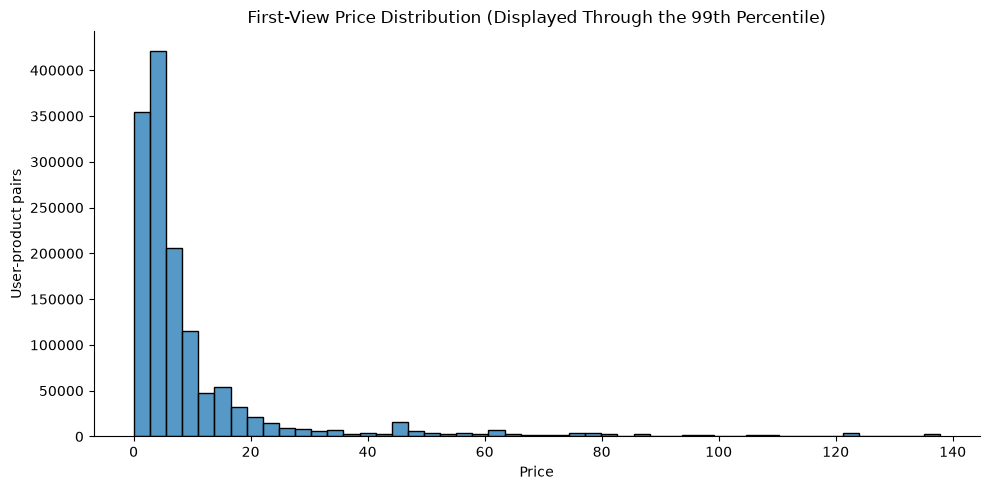

In [34]:
price_99th_percentile = (
    price_funnel["view_price"].quantile(0.99)
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=price_funnel.loc[
        price_funnel["view_price"] <= price_99th_percentile
    ],
    x="view_price",
    bins=50,
    ax=ax,
)

ax.set_title(
    "First-View Price Distribution "
    "(Displayed Through the 99th Percentile)"
)
ax.set_xlabel("Price")
ax.set_ylabel("User-product pairs")

sns.despine()
plt.tight_layout()
plt.show()

#### Creating data-driven price buckets

In [35]:
_, price_edges = pd.qcut(
    price_funnel["view_price"],
    q=5,
    retbins=True,
    duplicates="drop",
)

number_of_buckets = len(price_edges) - 1

PRICE_LABELS = {
    5: [
        "Low",
        "Medium-low",
        "Medium",
        "Medium-high",
        "High",
    ],
    4: [
        "Low",
        "Medium-low",
        "Medium-high",
        "High",
    ],
    3: ["Low", "Medium", "High"],
    2: ["Low", "High"],
}

if number_of_buckets not in PRICE_LABELS:
    raise ValueError(
        "Price distribution does not contain enough "
        "distinct values for meaningful buckets."
    )

price_labels = PRICE_LABELS[number_of_buckets]

price_funnel["price_bucket"] = pd.cut(
    price_funnel["view_price"],
    bins=price_edges,
    labels=price_labels,
    include_lowest=True,
)

price_bucket_boundaries = pd.DataFrame({
    "price_bucket": price_labels,
    "lower_boundary": price_edges[:-1],
    "upper_boundary": price_edges[1:],
})

display(price_bucket_boundaries)

,price_bucket,lower_boundary,upper_boundary
0,Low,0.05,2.38
1,Medium-low,2.38,4.11
2,Medium,4.11,6.19
3,Medium-high,6.19,12.38
4,High,12.38,307.60


#### Calculating price conversion

In [36]:
price_conversion = calculate_segment_conversion(
    price_funnel,
    "price_bucket",
)

display(
    price_conversion.style.format({
        "viewed_pairs": "{:,.0f}",
        "carted_pairs": "{:,.0f}",
        "purchased_pairs": "{:,.0f}",
        "view_to_cart": "{:.2%}",
        "cart_to_purchase": "{:.2%}",
        "view_to_purchase": "{:.2%}",
    })
)

,price_bucket,viewed_pairs,carted_pairs,purchased_pairs,view_to_cart,cart_to_purchase,view_to_purchase
0,Low,"290,252","56,587","15,971",19.50%,28.22%,5.50%
1,Medium-low,"275,224","48,933","11,439",17.78%,23.38%,4.16%
2,Medium,"281,270","49,324","11,256",17.54%,22.82%,4.00%
3,Medium-high,"272,895","42,728","10,053",15.66%,23.53%,3.68%
4,High,"279,064","28,523","6,595",10.22%,23.12%,2.36%


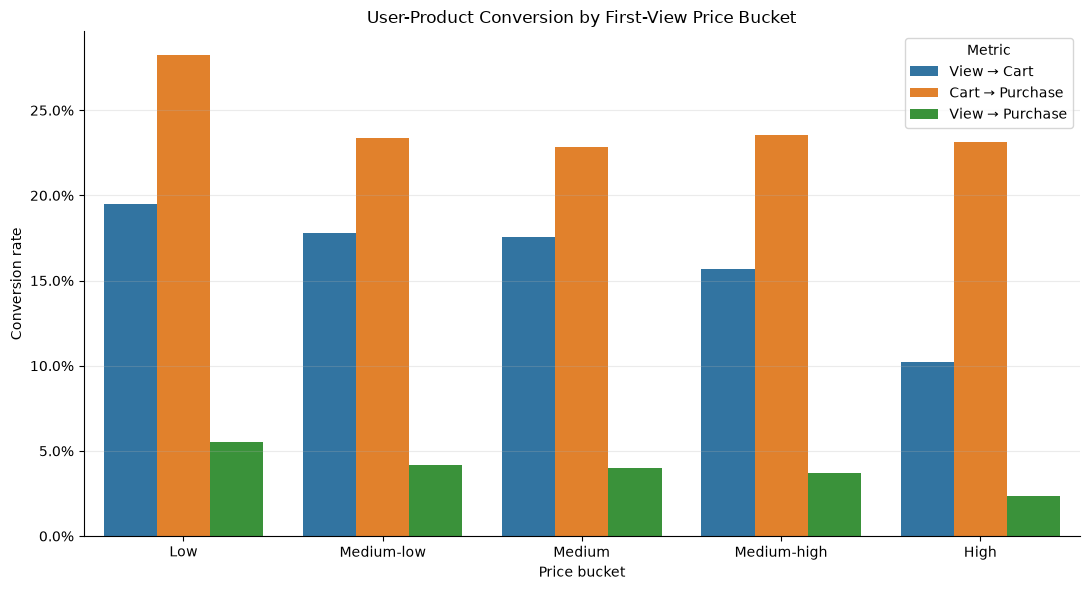

In [37]:
price_conversion_long = price_conversion.melt(
    id_vars=["price_bucket"],
    value_vars=[
        "view_to_cart",
        "cart_to_purchase",
        "view_to_purchase",
    ],
    var_name="metric",
    value_name="conversion_rate",
)

PRICE_METRIC_LABELS = {
    "view_to_cart": "View → Cart",
    "cart_to_purchase": "Cart → Purchase",
    "view_to_purchase": "View → Purchase",
}

price_conversion_long["metric"] = (
    price_conversion_long["metric"]
    .map(PRICE_METRIC_LABELS)
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=price_conversion_long,
    x="price_bucket",
    y="conversion_rate",
    hue="metric",
    order=price_labels,
    ax=ax,
)

ax.set_title("User-Product Conversion by First-View Price Bucket")
ax.set_xlabel("Price bucket")
ax.set_ylabel("Conversion rate")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Metric")

sns.despine()
plt.tight_layout()
plt.show()

#### Intermediate Conclusions

Price is negatively associated with product conversion. The strongest difference occurs at the view-to-cart stage: high-price products have a 9.28 p.p. lower view-to-cart conversion than low-price products (10.22% vs. 19.50%). In contrast, cart-to-purchase conversion differs much less between the two groups (23.12% vs. 28.22%).

Important notice is that price buckets are quantile-based, so it may affect accuracy.

### Category analysis

Category IDs are available for most events, but human-readable category codes are missing for approximately 98% of records. Therefore, category analysis uses category IDs and focuses on relative differences between categories rather than semantic interpretation of individual categories.

#### Calculating category conversion and inspecting volume

In [38]:
category_conversion_all = calculate_segment_conversion(
    characteristic_funnel,
    "view_category_id",
)

display(
    category_conversion_all[
        ["viewed_pairs", "carted_pairs"]
    ].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95]
    )
)

,viewed_pairs,carted_pairs
count,489.000000,489.000000
mean,2868.961145,462.658487
std,6534.177248,1012.308828
min,1.000000,0.000000
50%,784.000000,147.000000
75%,2350.000000,420.000000
90%,6738.400000,1192.000000
95%,10944.800000,1832.000000
max,59769.000000,10053.000000


In [39]:
MIN_CATEGORY_VIEWS = 1_000
MIN_CATEGORY_CARTS = 200
TOP_CATEGORY_COUNT = 15

category_conversion = (
    category_conversion_all.loc[
        (
            category_conversion_all["viewed_pairs"]
            >= MIN_CATEGORY_VIEWS
        )
        & (
            category_conversion_all["carted_pairs"]
            >= MIN_CATEGORY_CARTS
        )
    ]
    .nlargest(
        TOP_CATEGORY_COUNT,
        "viewed_pairs",
    )
    .copy()
)

category_conversion["category_label"] = (
    category_conversion["view_category_id"]
    .astype("string")
)

display(
    category_conversion.style.format({
        "viewed_pairs": "{:,.0f}",
        "carted_pairs": "{:,.0f}",
        "purchased_pairs": "{:,.0f}",
        "view_to_cart": "{:.2%}",
        "cart_to_purchase": "{:.2%}",
        "view_to_purchase": "{:.2%}",
    })
)

,view_category_id,viewed_pairs,carted_pairs,purchased_pairs,view_to_cart,cart_to_purchase,view_to_purchase,category_label
97,1487580007675986893,"59,769","10,053","2,303",16.82%,22.91%,3.85%,1487580007675986893
10,1487580005092295511,"56,525","8,716","2,193",15.42%,25.16%,3.88%,1487580005092295511
30,1487580005671109489,"38,563","6,757","1,703",17.52%,25.20%,4.42%,1487580005671109489
122,1487580008246412266,"37,319","5,203","1,203",13.94%,23.12%,3.22%,1487580008246412266
50,1487580006300255120,"35,824","1,954",513,5.45%,26.25%,1.43%,1487580006300255120
51,1487580006317032337,"34,469","6,148","1,851",17.84%,30.11%,5.37%,1487580006317032337
307,1487580013841613016,"33,898","5,329",904,15.72%,16.96%,2.67%,1487580013841613016
13,1487580005268456287,"33,805","4,755","1,407",14.07%,29.59%,4.16%,1487580005268456287
312,1487580013950664926,"33,463","2,236",599,6.68%,26.79%,1.79%,1487580013950664926
336,1602943681873052386,"33,106","4,535","1,055",13.70%,23.26%,3.19%,1602943681873052386


#### Visualizing category conversion

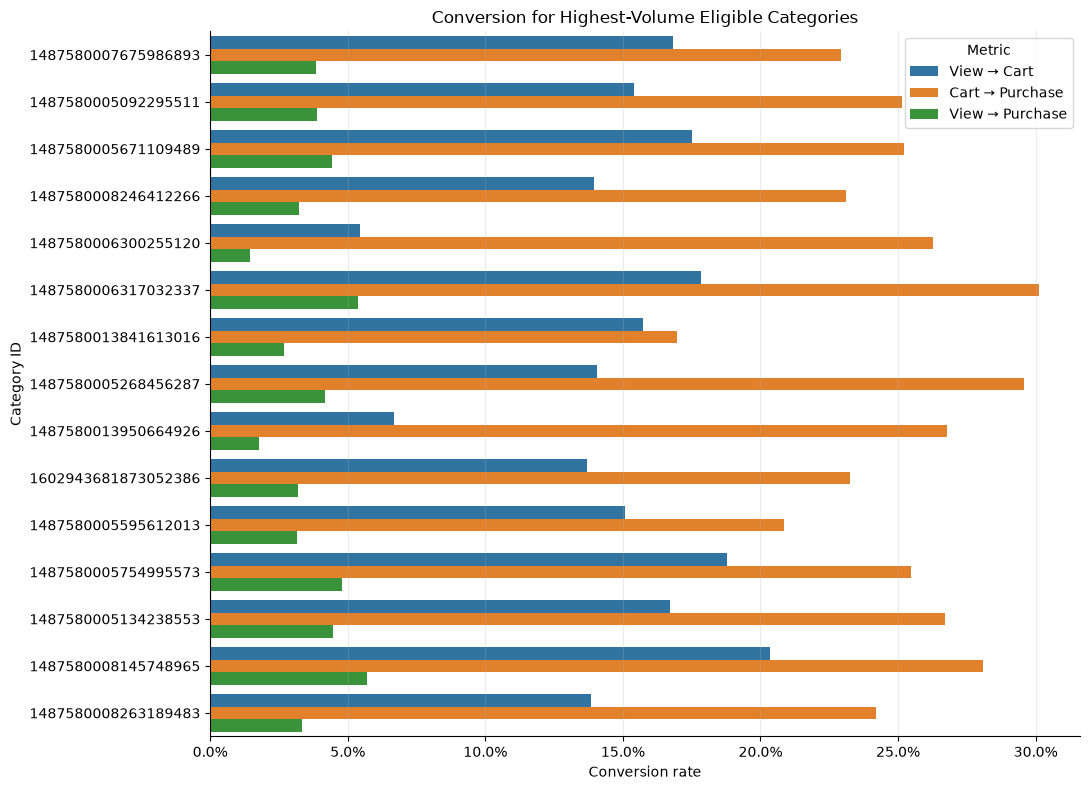

In [40]:
category_conversion_long = category_conversion.melt(
    id_vars=["category_label", "viewed_pairs"],
    value_vars=[
        "view_to_cart",
        "cart_to_purchase",
        "view_to_purchase",
    ],
    var_name="metric",
    value_name="conversion_rate",
)

category_conversion_long["metric"] = (
    category_conversion_long["metric"]
    .map(PRICE_METRIC_LABELS)
)

category_order = (
    category_conversion
    .sort_values("viewed_pairs", ascending=False)
    ["category_label"]
)

fig, ax = plt.subplots(figsize=(11, 8))

sns.barplot(
    data=category_conversion_long,
    y="category_label",
    x="conversion_rate",
    hue="metric",
    order=category_order,
    ax=ax,
)

ax.set_title(
    "Conversion for Highest-Volume Eligible Categories"
)
ax.set_xlabel("Conversion rate")
ax.set_ylabel("Category ID")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="x", alpha=0.25)
ax.legend(title="Metric")

sns.despine()
plt.tight_layout()
plt.show()

The difference between conversion among different categories is drastical so future analysis combining categories with other factors is needed.

Observation to investigate:

Some categories demonstrate high cart-to-purchase conversion and relatively low view-to-cart conversion. It may be caused not by checkout problems, but rather be an issue with persuading the user to add the item to the cart

### Brand analysis

#### Preparing known brands

The data contains missing brands so it needs additional cleaning in order to avoid them.

In [41]:
brand_funnel = characteristic_funnel.copy()

brand_funnel["view_brand"] = (
    brand_funnel["view_brand"]
    .astype("string")
    .str.strip()
    .str.lower()
    .replace("", pd.NA)
)

missing_brand_percent = (
    brand_funnel["view_brand"]
    .isna()
    .mean()
    * 100
)

print(
    f"Pairs with missing first-view brand: "
    f"{missing_brand_percent:.2f}%"
)

Pairs with missing first-view brand: 40.13%


#### Selecting high-volume brands

In [42]:
brand_conversion_all = calculate_segment_conversion(
    brand_funnel.dropna(subset=["view_brand"]),
    "view_brand",
)

display(
    brand_conversion_all[
        ["viewed_pairs", "carted_pairs"]
    ].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95]
    )
)

,viewed_pairs,carted_pairs
count,239.000000,239.000000
mean,3514.635983,565.481172
std,9644.871556,1556.853789
min,1.000000,0.000000
50%,482.000000,84.000000
75%,2202.000000,345.500000
90%,8194.200000,1443.800000
95%,17241.800000,2410.400000
max,88745.000000,14643.000000


In [43]:
MIN_BRAND_VIEWS = 1_000
MIN_BRAND_CARTS = 200
TOP_BRAND_COUNT = 10

brand_conversion = (
    brand_conversion_all.loc[
        (
            brand_conversion_all["viewed_pairs"]
            >= MIN_BRAND_VIEWS
        )
        & (
            brand_conversion_all["carted_pairs"]
            >= MIN_BRAND_CARTS
        )
    ]
    .nlargest(
        TOP_BRAND_COUNT,
        "viewed_pairs",
    )
    .copy()
)

display(
    brand_conversion.style.format({
        "viewed_pairs": "{:,.0f}",
        "carted_pairs": "{:,.0f}",
        "purchased_pairs": "{:,.0f}",
        "view_to_cart": "{:.2%}",
        "cart_to_purchase": "{:.2%}",
        "view_to_purchase": "{:.2%}",
    })
)

,view_brand,viewed_pairs,carted_pairs,purchased_pairs,view_to_cart,cart_to_purchase,view_to_purchase
196,runail,"88,745","14,643","4,445",16.50%,30.36%,5.01%
105,irisk,"65,279","10,741","2,843",16.45%,26.47%,4.36%
153,masura,"58,240","9,458","2,119",16.24%,22.40%,3.64%
92,grattol,"46,483","6,720","1,648",14.46%,24.52%,3.55%
28,bpw.style,"33,436","5,781","1,546",17.29%,26.74%,4.62%
71,estel,"28,588","4,305","1,212",15.06%,28.15%,4.24%
100,ingarden,"26,379","4,691","1,123",17.78%,23.94%,4.26%
114,kapous,"24,634","3,149",906,12.78%,28.77%,3.68%
109,jessnail,"20,309","1,965",471,9.68%,23.97%,2.32%
36,concept,"19,536","2,507",688,12.83%,27.44%,3.52%


#### Visualizing brand conversion

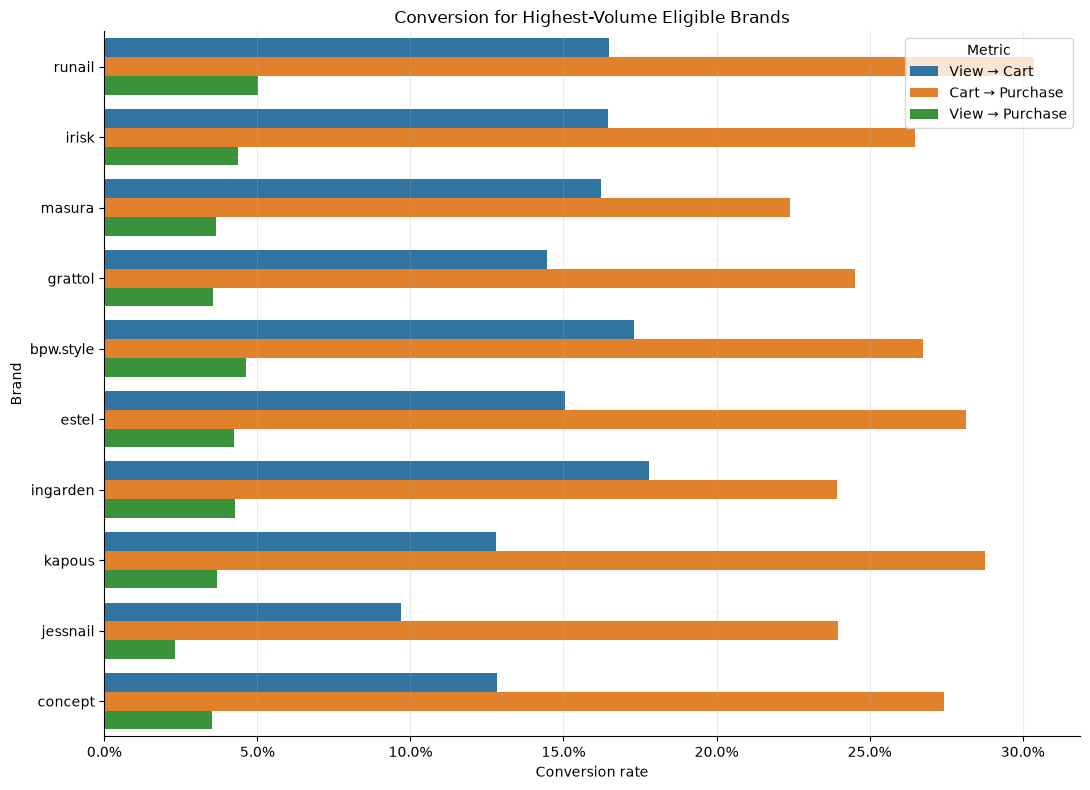

In [44]:
brand_conversion_long = brand_conversion.melt(
    id_vars=["view_brand", "viewed_pairs"],
    value_vars=[
        "view_to_cart",
        "cart_to_purchase",
        "view_to_purchase",
    ],
    var_name="metric",
    value_name="conversion_rate",
)

brand_conversion_long["metric"] = (
    brand_conversion_long["metric"]
    .map(PRICE_METRIC_LABELS)
)

brand_order = (
    brand_conversion
    .sort_values("viewed_pairs", ascending=False)
    ["view_brand"]
)

fig, ax = plt.subplots(figsize=(11, 8))

sns.barplot(
    data=brand_conversion_long,
    y="view_brand",
    x="conversion_rate",
    hue="metric",
    order=brand_order,
    ax=ax,
)

ax.set_title(
    "Conversion for Highest-Volume Eligible Brands"
)
ax.set_xlabel("Conversion rate")
ax.set_ylabel("Brand")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="x", alpha=0.25)
ax.legend(title="Metric")

sns.despine()
plt.tight_layout()
plt.show()

Some brands have relatively low view-to-cart conversion but relatively normal cart-to-purchase conversion, suggesting that the main drop-off occurs before users add products to their cart. Yet due to the significant differences in brands sample sizes future statistical analysis is mandatory.

*Brand-level analysis is based only on products with a recorded brand, so results may not be representative of the entire product catalog.*

Hypothesis to test:

The lower conversion of high-priced products persist within brands

### Category by price analysis

Here the conversion rates among top 5 biggest categories are investigated by distributing products into price buckets.

In [45]:
TOP_CATEGORY_COUNT = 5

top_category_volume = (
    characteristic_funnel
    .groupby("view_category_id", dropna=True)
    .agg(
        total_viewed_pairs=("reached_view", "sum"),
    )
    .nlargest(
        TOP_CATEGORY_COUNT,
        "total_viewed_pairs",
    )
)

top_category_ids = top_category_volume.index.tolist()

display(
    top_category_volume.style.format({
        "total_viewed_pairs": "{:,.0f}",
    })
)

,total_viewed_pairs
view_category_id,
1487580007675986893,"59,769"
1487580005092295511,"56,525"
1487580005671109489,"38,563"
1487580008246412266,"37,319"
1487580006300255120,"35,824"


In [46]:
category_price_data = price_funnel.loc[
    price_funnel["view_category_id"]
    .isin(top_category_ids)
].copy()

bucket_order = list(
    category_price_data["price_bucket"]
    .cat.categories
)

In [47]:
category_price_counts = (
    category_price_data
    .groupby(
        ["view_category_id", "price_bucket"],
        observed=True,
    )
    .agg(
        viewed_pairs=("reached_view", "sum"),
        carted_pairs=("reached_cart", "sum"),
        purchased_pairs=("reached_purchase", "sum"),
    )
)

In [48]:
complete_category_price_index = pd.MultiIndex.from_product(
    [
        top_category_ids,
        bucket_order,
    ],
    names=[
        "view_category_id",
        "price_bucket",
    ],
)

category_price_conversion = (
    category_price_counts
    .reindex(
        complete_category_price_index,
        fill_value=0,
    )
    .reset_index()
)

##### Calculating conversion rates

In [49]:
category_price_conversion["view_to_cart"] = (
    category_price_conversion["carted_pairs"]
    .div(
        category_price_conversion[
            "viewed_pairs"
        ].replace(0, np.nan)
    )
)

category_price_conversion["cart_to_purchase"] = (
    category_price_conversion["purchased_pairs"]
    .div(
        category_price_conversion[
            "carted_pairs"
        ].replace(0, np.nan)
    )
)

category_price_conversion["view_to_purchase"] = (
    category_price_conversion["purchased_pairs"]
    .div(
        category_price_conversion[
            "viewed_pairs"
        ].replace(0, np.nan)
    )
)

In [50]:
category_price_conversion["category_view_total"] = (
    category_price_conversion
    .groupby("view_category_id")
    ["viewed_pairs"]
    .transform("sum")
)

category_price_conversion["view_share_within_category"] = (
    category_price_conversion["viewed_pairs"]
    .div(
        category_price_conversion[
            "category_view_total"
        ].replace(0, np.nan)
    )
)

In [51]:
category_price_conversion["category_label"] = (
    category_price_conversion[
        "view_category_id"
    ]
    .astype("string")
)

category_order = [
    str(category_id)
    for category_id in top_category_ids
]

category_price_conversion["category_label"] = pd.Categorical(
    category_price_conversion["category_label"],
    categories=category_order,
    ordered=True,
)

category_price_conversion = (
    category_price_conversion
    .sort_values(
        ["category_label", "price_bucket"]
    )
)

In [52]:
category_price_conversion["price_bucket"] = pd.Categorical(
    category_price_conversion["price_bucket"],
    categories=bucket_order,
    ordered=True,
)

category_price_table = (
    category_price_conversion[
        [
            "category_label",
            "price_bucket",
            "viewed_pairs",
            "view_share_within_category",
            "carted_pairs",
            "purchased_pairs",
            "view_to_cart",
            "cart_to_purchase",
            "view_to_purchase",
        ]
    ]
    .sort_values(
        ["category_label", "price_bucket"]
    )
)

display(
    category_price_table.style.format({
        "viewed_pairs": "{:,.0f}",
        "view_share_within_category": "{:.2%}",
        "carted_pairs": "{:,.0f}",
        "purchased_pairs": "{:,.0f}",
        "view_to_cart": "{:.2%}",
        "cart_to_purchase": "{:.2%}",
        "view_to_purchase": "{:.2%}",
    })
)

,category_label,price_bucket,viewed_pairs,view_share_within_category,carted_pairs,purchased_pairs,view_to_cart,cart_to_purchase,view_to_purchase
0,1487580007675986893,Low,"58,149",97.72%,"9,942","2,279",17.10%,22.92%,3.92%
1,1487580007675986893,Medium-low,0,0.00%,0,0,nan%,nan%,nan%
2,1487580007675986893,Medium,0,0.00%,0,0,nan%,nan%,nan%
3,1487580007675986893,Medium-high,"1,355",2.28%,89,16,6.57%,17.98%,1.18%
4,1487580007675986893,High,0,0.00%,0,0,nan%,nan%,nan%
5,1487580005092295511,Low,707,1.25%,100,15,14.14%,15.00%,2.12%
6,1487580005092295511,Medium-low,"2,879",5.10%,437,88,15.18%,20.14%,3.06%
7,1487580005092295511,Medium,"11,371",20.15%,"2,082",510,18.31%,24.50%,4.49%
8,1487580005092295511,Medium-high,"33,067",58.61%,"4,688","1,229",14.18%,26.22%,3.72%
9,1487580005092295511,High,"8,399",14.89%,"1,403",350,16.70%,24.95%,4.17%


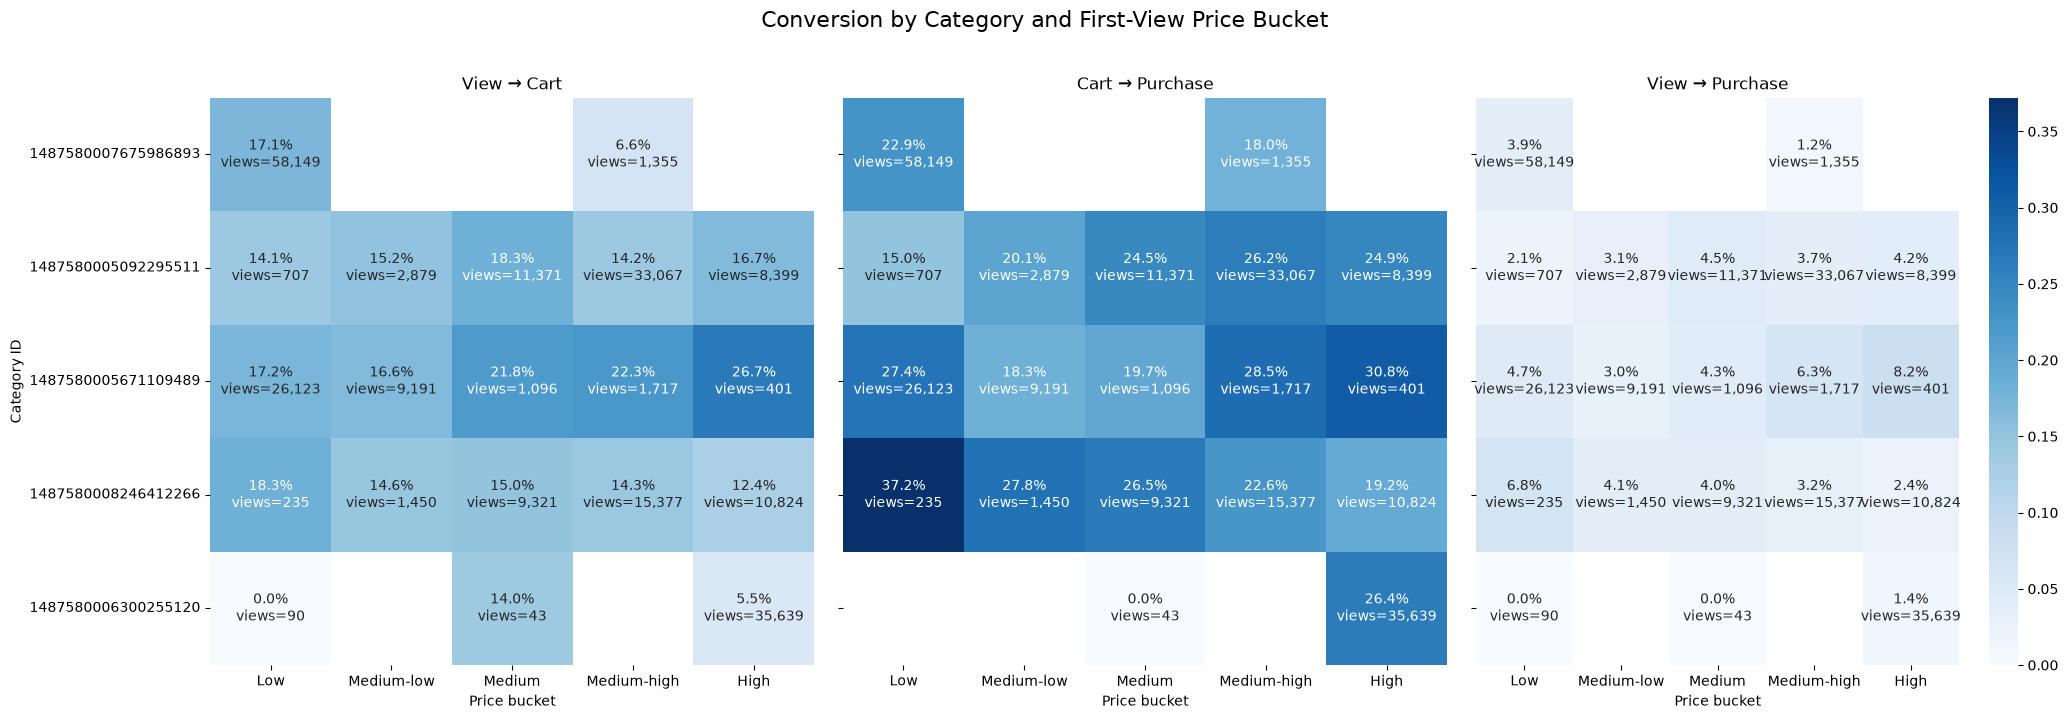

In [53]:
METRIC_TITLES = {
    "view_to_cart": "View → Cart",
    "cart_to_purchase": "Cart → Purchase",
    "view_to_purchase": "View → Purchase",
}

rate_columns = list(METRIC_TITLES)

shared_maximum = np.nanmax(
    category_price_conversion[
        rate_columns
    ].to_numpy()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 7),
    sharey=True,
)

for index, (metric, title) in enumerate(
    METRIC_TITLES.items()
):
    rate_matrix = (
        category_price_conversion
        .pivot(
            index="category_label",
            columns="price_bucket",
            values=metric,
        )
        .reindex(
            index=category_order,
            columns=bucket_order,
        )
    )

    view_matrix = (
        category_price_conversion
        .pivot(
            index="category_label",
            columns="price_bucket",
            values="viewed_pairs",
        )
        .reindex(
            index=category_order,
            columns=bucket_order,
        )
    )

    annotations = pd.DataFrame(
        "",
        index=rate_matrix.index,
        columns=rate_matrix.columns,
    )

    for category in rate_matrix.index:
        for bucket in rate_matrix.columns:
            rate = rate_matrix.loc[category, bucket]
            views = view_matrix.loc[category, bucket]

            if pd.notna(rate) and views > 0:
                annotations.loc[category, bucket] = (
                    f"{rate:.1%}\n"
                    f"views={views:,.0f}"
                )
            else:
                annotations.loc[category, bucket] = (
                    "No data"
                )

    sns.heatmap(
        rate_matrix,
        annot=annotations,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=shared_maximum,
        mask=rate_matrix.isna(),
        cbar=index == 2,
        ax=axes[index],
    )

    axes[index].set_title(title)
    axes[index].set_xlabel("Price bucket")
    axes[index].set_ylabel(
        "Category ID" if index == 0 else ""
    )

fig.suptitle(
    "Conversion by Category and First-View Price Bucket",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()
plt.show()

#### Intermediate Conclusions

The negative relationship between price and conversion observed at the aggregate level is not consistent across product categories.

Within some categories, higher-priced products actually show higher conversion, while in others conversion decreases with price. This suggests that category composition plays an important role in the aggregate price-conversion relationship.

## Brand by price analysis

Here the conversion rates among top 10 biggest brands are investigated by distributing products into price buckets.

In [54]:
TOP_BRAND_COUNT = 10

top_brand_names = (
    brand_conversion
    .sort_values("viewed_pairs", ascending=False)
    .head(TOP_BRAND_COUNT)
    ["view_brand"]
    .astype("string")
    .tolist()
)

top_brand_names

['runail',
 'irisk',
 'masura',
 'grattol',
 'bpw.style',
 'estel',
 'ingarden',
 'kapous',
 'jessnail',
 'concept']

##### Preparing brand-price data

In [55]:
brand_price_data = price_funnel.copy()

brand_price_data["view_brand"] = (
    brand_price_data["view_brand"]
    .astype("string")
    .str.strip()
    .str.lower()
    .replace("", pd.NA)
)

brand_price_data = brand_price_data.loc[
    brand_price_data["view_brand"]
    .isin(top_brand_names)
]

bucket_order = list(
    brand_price_data["price_bucket"]
    .cat.categories
)

In [56]:
brand_price_counts = (
    brand_price_data
    .groupby(
        ["view_brand", "price_bucket"],
        observed=True,
    )
    .agg(
        viewed_pairs=("reached_view", "sum"),
        carted_pairs=("reached_cart", "sum"),
        purchased_pairs=("reached_purchase", "sum"),
    )
)

complete_brand_price_index = pd.MultiIndex.from_product(
    [top_brand_names, bucket_order],
    names=["view_brand", "price_bucket"],
)

brand_price_conversion = (
    brand_price_counts
    .reindex(
        complete_brand_price_index,
        fill_value=0,
    )
    .reset_index()
)

brand_price_conversion["view_to_cart"] = (
    brand_price_conversion["carted_pairs"]
    .div(
        brand_price_conversion[
            "viewed_pairs"
        ].replace(0, np.nan)
    )
)

brand_price_conversion["cart_to_purchase"] = (
    brand_price_conversion["purchased_pairs"]
    .div(
        brand_price_conversion[
            "carted_pairs"
        ].replace(0, np.nan)
    )
)

brand_price_conversion["view_to_purchase"] = (
    brand_price_conversion["purchased_pairs"]
    .div(
        brand_price_conversion[
            "viewed_pairs"
        ].replace(0, np.nan)
    )
)

##### Visualizing the heatmaps

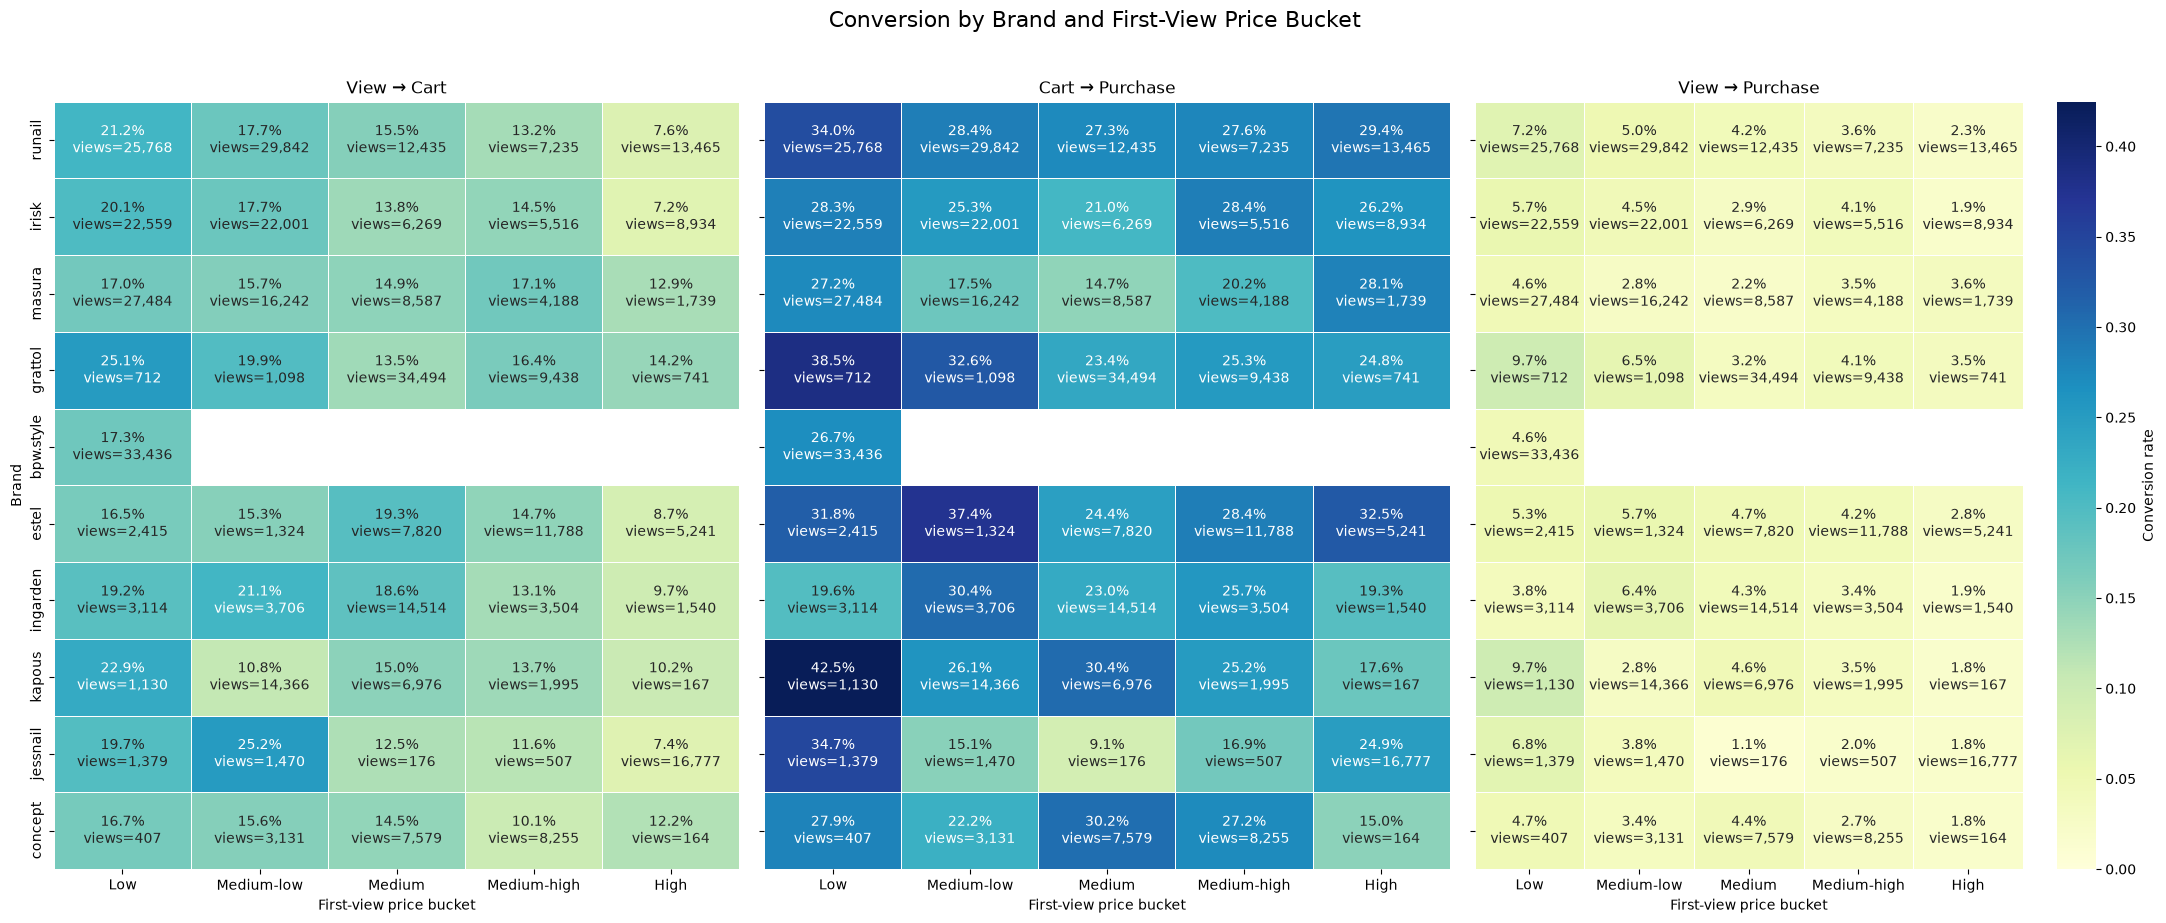

In [57]:
BRAND_METRIC_TITLES = {
    "view_to_cart": "View → Cart",
    "cart_to_purchase": "Cart → Purchase",
    "view_to_purchase": "View → Purchase",
}

shared_maximum = np.nanmax(
    brand_price_conversion[
        list(BRAND_METRIC_TITLES)
    ].to_numpy()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 9),
    sharey=True,
)

for index, (metric, title) in enumerate(
    BRAND_METRIC_TITLES.items()
):
    rate_matrix = (
        brand_price_conversion
        .pivot(
            index="view_brand",
            columns="price_bucket",
            values=metric,
        )
        .reindex(
            index=top_brand_names,
            columns=bucket_order,
        )
    )

    view_matrix = (
        brand_price_conversion
        .pivot(
            index="view_brand",
            columns="price_bucket",
            values="viewed_pairs",
        )
        .reindex(
            index=top_brand_names,
            columns=bucket_order,
        )
    )

    annotations = pd.DataFrame(
        "",
        index=rate_matrix.index,
        columns=rate_matrix.columns,
    )

    for brand in rate_matrix.index:
        for bucket in rate_matrix.columns:
            rate = rate_matrix.loc[brand, bucket]
            views = view_matrix.loc[brand, bucket]

            if pd.notna(rate) and views > 0:
                annotations.loc[brand, bucket] = (
                    f"{rate:.1%}\n"
                    f"views={views:,.0f}"
                )
            else:
                annotations.loc[brand, bucket] = "—"

    sns.heatmap(
        rate_matrix,
        annot=annotations,
        fmt="",
        cmap="YlGnBu",
        vmin=0,
        vmax=shared_maximum,
        mask=rate_matrix.isna(),
        linewidths=0.5,
        linecolor="white",
        cbar=index == 2,
        cbar_kws={
            "label": "Conversion rate"
        } if index == 2 else None,
        ax=axes[index],
    )

    axes[index].set_title(title)
    axes[index].set_xlabel("First-view price bucket")
    axes[index].set_ylabel(
        "Brand" if index == 0 else ""
    )

fig.suptitle(
    "Conversion by Brand and First-View Price Bucket",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()
plt.show()

Key findings:

- Runail: View → Purchase falls from 7.2% in Low to 2.3% in High.
- View → Cart falls sharply: 21.2% → 7.6%.
- Cart → Purchase falls only modestly: 34.0% → 29.4%.
- Irisk: View → Purchase declines from 5.7% to 1.9%, again mainly because View → Cart falls from 20.1% to 7.2%.
- Masura: The pattern is less linear. Conversion falls through Medium and then partially recovers in higher buckets. High-price volume is smaller, with only 1,739 viewed pairs.

Several other brands show similar declines in View → Purchase at higher prices, but not every brand follows a monotonic pattern.

This suggests a product hypothesis:

Higher-priced products may encounter their largest friction before users add them to cart, rather than after carting.

As we already had a similar observation in the category analysis that mean **users may require stronger value communication, reviews, product information or reassurance before expressing purchase intent**.

Apparently due to sample sizes limitations future corellational and statistical analysis is going to be provided.

### Statistical analysis

The following tests Low versus High price buckets for Runail and Irisk across all three funnel metrics.

Hypotheses for each comparison:

H₀: Low- and High-price conversion rates are equal.

H₁: The conversion rates differ.

alpha = 0.05

##### Running two-proportion tests

In [58]:
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportions_ztest

TEST_BRANDS = ["runail", "irisk"]
ALPHA = 0.05

METRIC_DEFINITIONS = {
    "View → Cart": {
        "successes": "carted_pairs",
        "denominator": "viewed_pairs",
        "minimum_denominator": 1_000,
    },
    "Cart → Purchase": {
        "successes": "purchased_pairs",
        "denominator": "carted_pairs",
        "minimum_denominator": 200,
    },
    "View → Purchase": {
        "successes": "purchased_pairs",
        "denominator": "viewed_pairs",
        "minimum_denominator": 1_000,
    },
}

test_results = []

for brand in TEST_BRANDS:
    brand_data = (
        brand_price_conversion.loc[
            brand_price_conversion["view_brand"].eq(brand)
        ]
        .set_index("price_bucket")
    )

    low = brand_data.loc["Low"]
    high = brand_data.loc["High"]

    for metric, definition in METRIC_DEFINITIONS.items():
        success_column = definition["successes"]
        denominator_column = definition["denominator"]
        minimum = definition["minimum_denominator"]

        low_successes = int(low[success_column])
        high_successes = int(high[success_column])

        low_total = int(low[denominator_column])
        high_total = int(high[denominator_column])

        if low_total < minimum or high_total < minimum:
            print(
                f"Skipped {brand}, {metric}: "
                f"denominator below {minimum:,}"
            )
            continue

        low_rate = low_successes / low_total
        high_rate = high_successes / high_total
        rate_difference = low_rate - high_rate

        z_statistic, p_value = proportions_ztest(
            count=[low_successes, high_successes],
            nobs=[low_total, high_total],
            alternative="two-sided",
        )

        # Unpooled 95% confidence interval for Low − High.
        standard_error = np.sqrt(
            low_rate * (1 - low_rate) / low_total
            + high_rate * (1 - high_rate) / high_total
        )

        critical_value = stats.norm.ppf(
            1 - ALPHA / 2
        )

        confidence_low = (
            rate_difference
            - critical_value * standard_error
        )

        confidence_high = (
            rate_difference
            + critical_value * standard_error
        )

        test_results.append({
            "brand": brand,
            "metric": metric,
            "low_successes": low_successes,
            "low_denominator": low_total,
            "low_rate": low_rate,
            "high_successes": high_successes,
            "high_denominator": high_total,
            "high_rate": high_rate,
            "difference_pp": rate_difference * 100,
            "ci_low_pp": confidence_low * 100,
            "ci_high_pp": confidence_high * 100,
            "z_statistic": z_statistic,
            "p_value": p_value,
        })

test_results = pd.DataFrame(test_results)

##### Correct for multiple comparisons
Six tests are being conducted, so applying the Holm correction

In [59]:
if not test_results.empty:
    test_results["adjusted_p_value"] = multipletests(
        test_results["p_value"],
        alpha=ALPHA,
        method="holm",
    )[1]

    test_results["statistically_significant"] = (
        test_results["adjusted_p_value"] < ALPHA
    )

In [60]:
display(
    test_results.style.format({
        "low_successes": "{:,.0f}",
        "low_denominator": "{:,.0f}",
        "low_rate": "{:.2%}",
        "high_successes": "{:,.0f}",
        "high_denominator": "{:,.0f}",
        "high_rate": "{:.2%}",
        "difference_pp": "{:+.2f} pp",
        "ci_low_pp": "{:+.2f} pp",
        "ci_high_pp": "{:+.2f} pp",
        "z_statistic": "{:.2f}",
        "p_value": "{:.3g}",
        "adjusted_p_value": "{:.3g}",
    })
)

,brand,metric,low_successes,low_denominator,low_rate,high_successes,high_denominator,high_rate,difference_pp,ci_low_pp,ci_high_pp,z_statistic,p_value,adjusted_p_value,statistically_significant
0,runail,View → Cart,"5,452","25,768",21.16%,"1,030","13,465",7.65%,+13.51 pp,+12.84 pp,+14.18 pp,34.21,1.92e-256,1.15e-255,True
1,runail,Cart → Purchase,"1,851","5,452",33.95%,303,"1,030",29.42%,+4.53 pp,+1.48 pp,+7.59 pp,2.83,0.00462,0.00923,True
2,runail,View → Purchase,"1,851","25,768",7.18%,303,"13,465",2.25%,+4.93 pp,+4.53 pp,+5.34 pp,20.37,3.37e-92,1.35e-91,True
3,irisk,View → Cart,"4,538","22,559",20.12%,645,"8,934",7.22%,+12.90 pp,+12.15 pp,+13.65 pp,27.82,2.25e-170,1.13e-169,True
4,irisk,Cart → Purchase,"1,282","4,538",28.25%,169,645,26.20%,+2.05 pp,-1.59 pp,+5.69 pp,1.08,0.278,0.278,False
5,irisk,View → Purchase,"1,282","22,559",5.68%,169,"8,934",1.89%,+3.79 pp,+3.38 pp,+4.20 pp,14.47,1.96e-47,5.89e-47,True


The results support a strong association between price bucket and conversion for both brands, mainly before products reach the cart.

### Main conclusion

For both brands, high-priced products are approximately three times less likely to progress from view to purchase. Most of this difference occurs at View → Cart, not after carting.

This supports the product hypothesis:

**The principal friction for high-priced products occurs before users express purchase intent. Improving value communication, product detail, reviews or reassurance on high-priced product pages may increase cart additions.**

## User Behavior Analysis

The main unit in this section remains one (user_id, product_id) pair. We count views before the pair’s first qualifying purchase; views after purchase are excluded because they cannot explain that purchase.

#### Counting views before purchase

In [61]:
view_events = (
    funnel_events.loc[
        funnel_events["event_type"].eq("view"),
        FUNNEL_KEYS + ["event_order"],
    ]
    .merge(
        user_product_funnel[
            FUNNEL_KEYS + ["first_purchase_order"]
        ],
        on=FUNNEL_KEYS,
        how="inner",
        validate="many_to_one",
    )
)

# For purchasers, retain only views before purchase.
# For non-purchasers, retain all observed views.
view_events_before_outcome = view_events.loc[
    view_events["first_purchase_order"].isna()
    | (
        view_events["event_order"]
        < view_events["first_purchase_order"]
    )
]

view_counts = (
    view_events_before_outcome
    .groupby(FUNNEL_KEYS)
    .size()
    .rename("view_count")
    .reset_index()
)

### Building the behavior table

In [62]:
user_product_behavior = (
    user_product_funnel[
        FUNNEL_KEYS
        + ["reached_cart", "reached_purchase"]
    ]
    .merge(
        view_counts,
        on=FUNNEL_KEYS,
        how="left",
        validate="one_to_one",
    )
)
user_product_behavior["view_count"] = (
    user_product_behavior["view_count"]
    .fillna(1)
    .astype(int)
)
user_product_behavior.head()

,user_id,product_id,reached_cart,reached_purchase,view_count
0,474232307,5875317,True,True,1
1,555446068,5692917,False,False,1
2,546705258,5819638,False,False,1
3,507355498,5856191,False,False,3
4,543446752,5733176,False,False,1


### Inspecting the observed distribution

In [64]:
display(
    user_product_behavior["view_count"].describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

display(
    user_product_behavior["view_count"]
    .value_counts()
    .sort_index()
    .head(15)
    .to_frame("user_product_pairs")
)

count    1.402922e+06
mean     1.320833e+00
std      1.063241e+00
min      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
90%      2.000000e+00
95%      3.000000e+00
99%      5.000000e+00
max      1.490000e+02
Name: view_count, dtype: float64

,user_product_pairs
view_count,
1,1134026
2,180435
3,50427
4,19122
5,8387
6,4274
7,2254
8,1347
9,823


### Creating engagement groups

In [65]:
VIEW_GROUP_ORDER = [
    "1 view",
    "2–3 views",
    "4–5 views",
    "6+ views",
]

user_product_behavior["view_group"] = pd.cut(
    user_product_behavior["view_count"],
    bins=[0, 1, 3, 5, np.inf],
    labels=VIEW_GROUP_ORDER,
    ordered=True,
)

In [66]:
display(
    user_product_behavior["view_group"]
    .value_counts(sort=False)
    .rename("user_product_pairs")
    .to_frame()
)

,user_product_pairs
view_group,
1 view,1134026
2–3 views,230862
4–5 views,27509
6+ views,10525


"4-5 views" and "6+ views" groups contain relatively few views, so they will be combined into a single group.

In [67]:
VIEW_GROUP_ORDER = [
    "1 view",
    "2–3 views",
    "4+ views",
]

user_product_behavior["view_group"] = pd.cut(
    user_product_behavior["view_count"],
    bins=[0, 1, 3, np.inf],
    labels=VIEW_GROUP_ORDER,
    ordered=True,
)

display(
    user_product_behavior["view_group"]
    .value_counts(sort=False)
    .rename("user_product_pairs")
    .to_frame()
)

,user_product_pairs
view_group,
1 view,1134026
2–3 views,230862
4+ views,38034


### Calculating purchase conversion

In [68]:
view_group_conversion = (
    user_product_behavior
    .groupby("view_group", observed=True)
    .agg(
        user_product_pairs=("product_id", "size"),
        carted_pairs=("reached_cart", "sum"),
        purchased_pairs=("reached_purchase", "sum"),
        purchase_conversion=("reached_purchase", "mean"),
    )
    .reindex(VIEW_GROUP_ORDER)
    .reset_index()
)

view_group_conversion["cart_conversion"] = (
    view_group_conversion["carted_pairs"]
    .div(view_group_conversion["user_product_pairs"])
)

In [69]:
# adding Wilson confidence intervals
from statsmodels.stats.proportion import proportion_confint

confidence_intervals = [
    proportion_confint(
        count=row.purchased_pairs,
        nobs=row.user_product_pairs,
        alpha=0.05,
        method="wilson",
    )
    for row in view_group_conversion.itertuples()
]

view_group_conversion[
    ["ci_low", "ci_high"]
] = pd.DataFrame(
    confidence_intervals,
    index=view_group_conversion.index,
)

In [70]:
display(
    view_group_conversion.style.format({
        "user_product_pairs": "{:,.0f}",
        "carted_pairs": "{:,.0f}",
        "purchased_pairs": "{:,.0f}",
        "cart_conversion": "{:.2%}",
        "purchase_conversion": "{:.2%}",
        "ci_low": "{:.2%}",
        "ci_high": "{:.2%}",
    })
)

,view_group,user_product_pairs,carted_pairs,purchased_pairs,purchase_conversion,cart_conversion,ci_low,ci_high
0,1 view,"1,134,026","154,551","33,271",2.93%,13.63%,2.90%,2.97%
1,2–3 views,"230,862","55,463","17,178",7.44%,24.02%,7.33%,7.55%
2,4+ views,"38,034","16,226","4,904",12.89%,42.66%,12.56%,13.23%


Visualizing the association

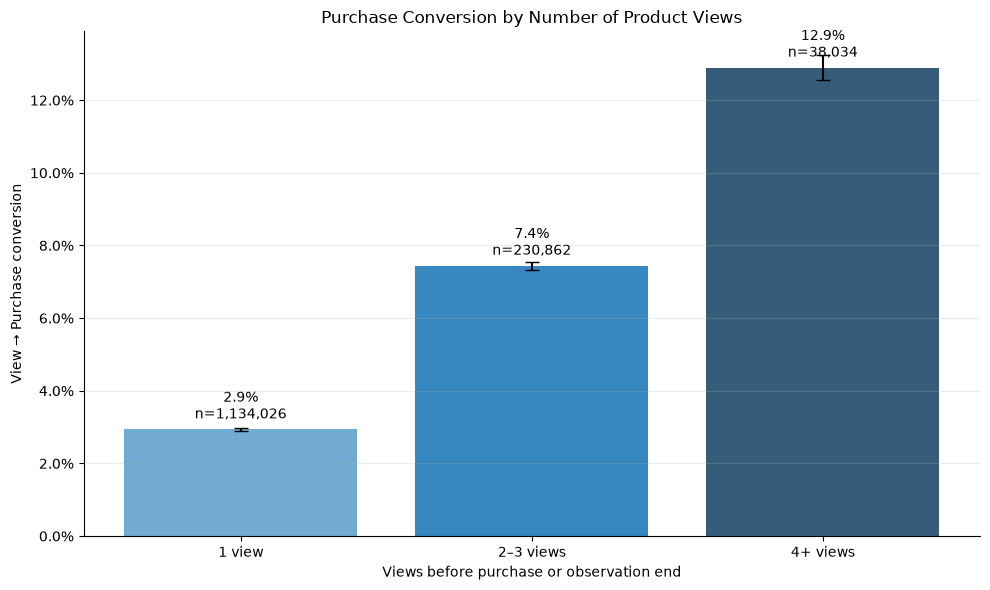

In [71]:
fig, ax = plt.subplots(figsize=(10, 6))

positions = np.arange(len(view_group_conversion))
rates = view_group_conversion["purchase_conversion"]

lower_errors = (
    rates - view_group_conversion["ci_low"]
)

upper_errors = (
    view_group_conversion["ci_high"] - rates
)

bars = ax.bar(
    positions,
    rates,
    color=sns.color_palette(
        "Blues_d",
        len(view_group_conversion),
    ),
)

ax.errorbar(
    positions,
    rates,
    yerr=np.vstack([lower_errors, upper_errors]),
    fmt="none",
    color="black",
    capsize=5,
)

for bar, row in zip(
    bars,
    view_group_conversion.itertuples(),
):
    ax.annotate(
        (
            f"{row.purchase_conversion:.1%}\n"
            f"n={row.user_product_pairs:,.0f}"
        ),
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
        ),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
    )

ax.set_xticks(
    positions,
    view_group_conversion["view_group"],
)
ax.set_title(
    "Purchase Conversion by Number of Product Views"
)
ax.set_xlabel("Views before purchase or observation end")
ax.set_ylabel("View → Purchase conversion")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="y", alpha=0.25)

sns.despine()
plt.tight_layout()
plt.show()

More views may indicate stronger interest, but they can also indicate uncertainty, comparison shopping or simply a longer opportunity to purchase. Purchasers and non-purchasers also have different observation endpoints, so this analysis does not establish causality. Additional investigation is needed.

### Statistical analysis

Hypotheses:

H₀: Purchase is independent of view-count group.
H₁: Purchase conversion differs between at least two groups.
alpha = 0.05

This section is using an omnibus chi-square test first, followed by pairwise proportion tests with Holm correction.

#### Omnibus chi-square test

In [72]:
behavior_test_data = (
    user_product_behavior
    .dropna(subset=["view_group"])
)

contingency_table = (
    pd.crosstab(
        behavior_test_data["view_group"],
        behavior_test_data["reached_purchase"],
    )
    .reindex(
        index=VIEW_GROUP_ORDER,
        columns=[False, True],
        fill_value=0,
    )
)

contingency_table.columns = [
    "not_purchased",
    "purchased",
]

display(contingency_table)

,not_purchased,purchased
view_group,,
1 view,1100755,33271
2–3 views,213684,17178
4+ views,33130,4904


In [73]:
chi_square, omnibus_p_value, degrees_freedom, expected = (
    stats.chi2_contingency(contingency_table)
)

total_pairs = contingency_table.to_numpy().sum()

cramers_v = np.sqrt(
    chi_square
    / (
        total_pairs
        * min(
            contingency_table.shape[0] - 1,
            contingency_table.shape[1] - 1,
        )
    )
)

print(f"Chi-square: {chi_square:,.2f}")
print(f"Degrees of freedom: {degrees_freedom}")
print(f"P-value: {omnibus_p_value:.3g}")
print(f"Cramér's V: {cramers_v:.3f}")
print(f"Smallest expected count: {expected.min():,.1f}")

Chi-square: 18,539.97
Degrees of freedom: 2
P-value: 0
Cramér's V: 0.115
Smallest expected count: 1,500.7


#### Pairwise proportion tests

In [74]:
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportions_ztest

PAIRWISE_COMPARISONS = [
    ("2–3 views", "1 view"),
    ("4+ views", "1 view"),
    ("4+ views", "2–3 views"),
]

pairwise_results = []
critical_value = stats.norm.ppf(0.975)

for deeper_group, comparison_group in PAIRWISE_COMPARISONS:
    deeper_data = behavior_test_data.loc[
        behavior_test_data["view_group"].eq(deeper_group)
    ]

    comparison_data = behavior_test_data.loc[
        behavior_test_data["view_group"].eq(comparison_group)
    ]

    deeper_purchases = int(
        deeper_data["reached_purchase"].sum()
    )
    comparison_purchases = int(
        comparison_data["reached_purchase"].sum()
    )

    deeper_total = len(deeper_data)
    comparison_total = len(comparison_data)

    deeper_rate = deeper_purchases / deeper_total
    comparison_rate = (
        comparison_purchases / comparison_total
    )

    difference = deeper_rate - comparison_rate

    standard_error = np.sqrt(
        deeper_rate * (1 - deeper_rate) / deeper_total
        + comparison_rate
        * (1 - comparison_rate)
        / comparison_total
    )

    confidence_low = (
        difference - critical_value * standard_error
    )
    confidence_high = (
        difference + critical_value * standard_error
    )

    z_statistic, p_value = proportions_ztest(
        count=[
            deeper_purchases,
            comparison_purchases,
        ],
        nobs=[
            deeper_total,
            comparison_total,
        ],
        alternative="two-sided",
    )

    risk_ratio = (
        deeper_rate / comparison_rate
        if comparison_rate > 0
        else np.nan
    )

    pairwise_results.append({
        "comparison": (
            f"{deeper_group} vs {comparison_group}"
        ),
        "deeper_rate": deeper_rate,
        "comparison_rate": comparison_rate,
        "difference_pp": difference * 100,
        "ci_low_pp": confidence_low * 100,
        "ci_high_pp": confidence_high * 100,
        "risk_ratio": risk_ratio,
        "z_statistic": z_statistic,
        "p_value": p_value,
    })

pairwise_results = pd.DataFrame(pairwise_results)

In [75]:
pairwise_results["adjusted_p_value"] = multipletests(
    pairwise_results["p_value"],
    alpha=0.05,
    method="holm",
)[1]

pairwise_results["statistically_significant"] = (
    pairwise_results["adjusted_p_value"] < 0.05
)

In [76]:
display(
    pairwise_results.style.format({
        "deeper_rate": "{:.2%}",
        "comparison_rate": "{:.2%}",
        "difference_pp": "{:+.2f} pp",
        "ci_low_pp": "{:+.2f} pp",
        "ci_high_pp": "{:+.2f} pp",
        "risk_ratio": "{:.2f}×",
        "z_statistic": "{:.2f}",
        "p_value": "{:.3g}",
        "adjusted_p_value": "{:.3g}",
    })
)

,comparison,deeper_rate,comparison_rate,difference_pp,ci_low_pp,ci_high_pp,risk_ratio,z_statistic,p_value,adjusted_p_value,statistically_significant
0,2–3 views vs 1 view,7.44%,2.93%,+4.51 pp,+4.40 pp,+4.62 pp,2.54×,104.62,0,0,True
1,4+ views vs 1 view,12.89%,2.93%,+9.96 pp,+9.62 pp,+10.30 pp,4.39×,107.63,0,0,True
2,4+ views vs 2–3 views,12.89%,7.44%,+5.45 pp,+5.10 pp,+5.81 pp,1.73×,35.89,4.3e-282,4.3e-282,True


#### Intermediate Conclusion

We reject H₀: purchase outcome is associated with view-count group. Cramér’s V indicates a relatively small overall association, despite the extremely strong statistical evidence. The huge sample makes even modest associations highly significant.

All pairwise comparisons remain statistically significant after Holm correction, and every confidence interval excludes zero. 

**Purchase conversion rises consistently with repeated product views. User-product pairs with four or more views converted at approximately 4.4 times the rate of pairs viewed once.**

However, repeated viewing should be treated as an indicator of purchase intent—not necessarily its cause. Interested users may naturally view products repeatedly, and longer observation time creates more opportunities both to view and purchase. Multiple pairs from the same user also weaken the test’s independence assumption.

A suitable product hypothesis is that **repeated viewers are a high-intent segment that may benefit from recently viewed reminders or targeted product information**. An A/B test would be needed to determine whether such an intervention increases conversion.

## Seasonal analysis

By analyzing October data two major product hypothesis were established:

1. High-priced products have stronger pre-cart friction
High-priced products are around three times less likely to reach purchase than low-priced products. Most of this difference occurs at View→Cart rather than Cart→Purchase.

**Hypothesis: Better value communication—richer descriptions, specifications, reviews, benefits, and reassurance—will increase add-to-cart conversion for high-priced products, particularly Runail and Irisk.**

2. Repeated viewers are a high-intent segment
View→Purchase increases from 2.93% for one view to 12.89% for four or more views.

**Hypothesis: Recently viewed reminders, targeted product information, or retargeting campaigns for repeat viewers will increase purchases. This requires an A/B test because the observed relationship is not necessarily causal.**


As October is not the only month in the present dataset, main product hypothesis need to be validated by month-by-month analysis including all the five months in the deteset.

### Building the consistent five-month dataset

The five source files are processed one month at a time with the October clean_event_data pipeline. Exact duplicates are measured on the original nine source fields and retained, matching the October analysis; this supports the same duplicate-sensitivity checks later.

five_month_df keeps only view, cart, and purchase rows needed for funnel analysis. To avoid retaining a second, all-event dataset in memory, monthly_event_type_audit preserves counts for every event type (including remove_from_cart) by month.

Seasonal periods are ordered whole-month proxies: October baseline (2019-10-01–10-31), Black Friday month (2019-11-01–11-30), Christmas month (2019-12-01–12-31), post-holiday (2020-01-01–01-31), and February (2020-02-01–02-29). They describe broad retail periods, not causal campaign windows.

In [78]:
FIVE_MONTH_FILES = {
    "2019-10": "2019-Oct.csv",
    "2019-11": "2019-Nov.csv",
    "2019-12": "2019-Dec.csv",
    "2020-01": "2020-Jan.csv",
    "2020-02": "2020-Feb.csv",
}

SOURCE_COLUMNS = [
    "event_time",
    "event_type",
    "product_id",
    "category_id",
    "category_code",
    "brand",
    "price",
    "user_id",
    "user_session",
]

# Explicit dtypes make the five files consistent and avoid pandas' mixed-type inference.
FIVE_MONTH_DTYPES = {
    "event_type": "string",
    "product_id": "Int64",
    "category_id": "Int64",
    "category_code": "string",
    "brand": "string",
    "price": "float64",
    "user_id": "Int64",
    "user_session": "string",
}

FUNNEL_EVENT_TYPES = ["view", "cart", "purchase"]
MONTH_ORDER = list(FIVE_MONTH_FILES)
SEASONAL_PERIOD_BY_MONTH = {
    "2019-10": "October baseline",
    "2019-11": "Black Friday month",
    "2019-12": "Christmas month",
    "2020-01": "Post-holiday",
    "2020-02": "February",
}
SEASONAL_PERIOD_ORDER = list(SEASONAL_PERIOD_BY_MONTH.values())

In [79]:
def build_five_month_dataset(data_directory):
    """Load, audit, clean, and combine one monthly file at a time."""
    analysis_months = []
    quality_records = []
    event_type_audits = []

    for month_key, filename in FIVE_MONTH_FILES.items():
        file_path = data_directory / filename
        raw_month = pd.read_csv(
            file_path,
            usecols=SOURCE_COLUMNS,
            dtype=FIVE_MONTH_DTYPES,
            low_memory=False,
        )

        missing_columns = set(SOURCE_COLUMNS) - set(raw_month.columns)
        if missing_columns:
            raise ValueError(
                f"{filename} is missing columns: {sorted(missing_columns)}"
            )

        # Audit before cleaning or filtering so no event type or source issue is hidden.
        normalized_event_type = (
            raw_month["event_type"].str.strip().str.lower().fillna("<missing>")
        )
        event_type_audits.append(
            normalized_event_type.value_counts(dropna=False)
            .rename_axis("event_type")
            .rename("event_count")
            .reset_index()
            .assign(month=month_key)
        )

        missing_brand = (
            raw_month["brand"].isna()
            | raw_month["brand"].str.strip().eq("")
        )
        missing_category_code = (
            raw_month["category_code"].isna()
            | raw_month["category_code"].str.strip().eq("")
        )
        zero_price = raw_month["price"].eq(0)

        quality_record = {
            "month": month_key,
            "source_rows": len(raw_month),
            # Number of additional rows that exactly repeat an earlier source row.
            "exact_duplicate_rows": raw_month.duplicated(
                subset=SOURCE_COLUMNS,
                keep="first",
            ).sum(),
            "missing_brand_rows": missing_brand.sum(),
            "missing_category_id_rows": raw_month["category_id"].isna().sum(),
            "missing_category_code_rows": missing_category_code.sum(),
            "zero_price_rows": zero_price.sum(),
            "zero_price_products": raw_month.loc[
                zero_price, "product_id"
            ].nunique(dropna=True),
        }

        # Reuse the October pipeline; exact duplicates intentionally remain present.
        cleaned_month = clean_event_data(
            raw_month,
            drop_exact_duplicates=False,
        )
        del raw_month, normalized_event_type

        # Enforce identical numeric dtypes after the pipeline's essential-field filter.
        cleaned_month = cleaned_month.astype({
            "product_id": "int64",
            "category_id": "int64",
            "price": "float64",
            "user_id": "int64",
        })

        expected_period = pd.Period(month_key, freq="M")
        outside_named_month = cleaned_month["event_month"].ne(expected_period)
        if outside_named_month.any():
            raise ValueError(
                f"{filename} contains "
                f"{outside_named_month.sum():,} rows outside {month_key}."
            )

        month_text = cleaned_month["event_month"].astype("string")
        cleaned_month["month"] = pd.Categorical(
            month_text,
            categories=MONTH_ORDER,
            ordered=True,
        )
        cleaned_month["seasonal_period"] = pd.Categorical(
            month_text.map(SEASONAL_PERIOD_BY_MONTH),
            categories=SEASONAL_PERIOD_ORDER,
            ordered=True,
        )
        quality_record["rows_after_cleaning"] = len(cleaned_month)

        analysis_month = cleaned_month.loc[
            cleaned_month["event_type"].isin(FUNNEL_EVENT_TYPES)
        ].copy()
        quality_record["analysis_rows"] = len(analysis_month)

        analysis_months.append(analysis_month)
        quality_records.append(quality_record)
        del cleaned_month, analysis_month, month_text

    five_month_data = pd.concat(
        analysis_months,
        ignore_index=True,
        copy=False,
    )
    del analysis_months

    monthly_quality = (
        pd.DataFrame(quality_records)
        .set_index("month")
        .reindex(MONTH_ORDER)
    )
    all_event_type_audit = (
        pd.concat(event_type_audits, ignore_index=True)
        .pivot(index="month", columns="event_type", values="event_count")
        .fillna(0)
        .astype("int64")
        .reindex(MONTH_ORDER)
    )

    return five_month_data, monthly_quality, all_event_type_audit

In [80]:
five_month_df, monthly_data_quality, monthly_event_type_audit = (
    build_five_month_dataset(data_dir)
)

print(
    f"Analysis dataset: {len(five_month_df):,} rows, "
    f"{five_month_df['event_time'].min()} to "
    f"{five_month_df['event_time'].max()}"
)

/var/folders/s2/2gtgcrjj5030j74h5kqtf5vw0000gn/T/ipykernel_34139/2254258641.py:106: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  five_month_data = pd.concat(


Analysis dataset: 16,713,161 rows, 2019-10-01 00:00:00+00:00 to 2020-02-29 23:59:59+00:00


#### Quality and coverage outputs

monthly_data_quality reports source-level exact duplicates, missing catalog fields, and both zero-price rows and distinct zero-price products. monthly_event_type_audit retains an auditable count of every event type without keeping five full raw DataFrames in memory. The final checks confirm UTC timestamps, month coverage/order, the funnel-event filter, and retained duplicate policy.

In [81]:
display(monthly_data_quality)
display(monthly_event_type_audit)

assert str(five_month_df["event_time"].dtype).endswith(", UTC]")
assert five_month_df["event_time"].notna().all()
assert set(five_month_df["event_type"].dropna().unique()) <= set(
    FUNNEL_EVENT_TYPES
)
assert list(five_month_df["month"].cat.categories) == MONTH_ORDER
assert five_month_df["month"].cat.ordered
assert list(five_month_df["seasonal_period"].cat.categories) == (
    SEASONAL_PERIOD_ORDER
)
assert five_month_df["seasonal_period"].cat.ordered
assert set(five_month_df["event_month"].astype("string").unique()) == set(
    MONTH_ORDER
)
assert monthly_data_quality["exact_duplicate_rows"].sum() > 0

five_month_df.dtypes.rename("dtype").to_frame()

,source_rows,exact_duplicate_rows,missing_brand_rows,missing_category_id_rows,missing_category_code_rows,zero_price_rows,zero_price_products,rows_after_cleaning,analysis_rows
month,,,,,,,,,
2019-10,4102283,213155,1659261,0,4034806,6066,1420,4102283,3340173
2019-11,4635837,246693,1986029,0,4560089,11625,1869,4635837,3710356
2019-12,3533286,183860,1510289,0,3474821,7589,2156,3533286,2868631
2020-01,4264752,225100,1775630,0,4190033,7623,1402,4264752,3449728
2020-02,4156682,240290,1825908,0,4079497,71254,17695,4156682,3344273


event_type,cart,purchase,remove_from_cart,view
month,,,,
2019-10,1232385,245624,762110,1862164
2019-11,1311807,322417,925481,2076132
2019-12,927124,213176,664655,1728331
2020-01,1148323,263797,815024,2037608
2020-02,1148694,241993,812409,1953586


,dtype
event_time,"datetime64[us, UTC]"
event_type,string
product_id,int64
category_id,int64
category_code,string
brand,string
price,float64
user_id,int64
user_session,string
is_valid_price,bool


The downstream monthly funnel work should use five_month_df. Exact duplicates and non-positive prices remain available for sensitivity filtering through the unchanged rows and is_valid_price; remove_from_cart is excluded only from the analysis table and remains represented in monthly_event_type_audit.

### Monthly Funnel Comparison

**User-product unit:** one `(user_id, product_id)` pair with a view in that month. Cart requires a later cart for the same pair, and purchase requires a later purchase after that qualifying cart. View → Cart and View → Purchase use viewed pairs as the denominator; Cart → Purchase uses qualified cart pairs.

**Session unit:** one `(user_id, user_session)` pair within a month, matching the October methodology. Repeated events become presence flags; order is **not** enforced, and products may differ across stages. Sessions missing `user_session` are excluded and reported.

In [82]:
Z_95 = 1.959963984540054
MONTHLY_FUNNEL_KEYS = ["user_id", "product_id"]
MONTHLY_SESSION_KEYS = ["user_id", "user_session"]


def safe_ratio(numerator, denominator):
    if pd.isna(denominator) or denominator <= 0:
        return np.nan
    return float(numerator) / float(denominator)


def wilson_95(successes, trials, z=Z_95):
    if pd.isna(trials) or trials <= 0 or pd.isna(successes):
        return np.nan, np.nan

    successes = float(successes)
    trials = float(trials)
    if successes < 0 or successes > trials:
        return np.nan, np.nan

    proportion = successes / trials
    z_squared = z**2
    denominator = 1 + z_squared / trials
    center = (proportion + z_squared / (2 * trials)) / denominator
    margin = (
        z
        * np.sqrt(
            proportion * (1 - proportion) / trials
            + z_squared / (4 * trials**2)
        )
        / denominator
    )
    return max(0.0, center - margin), min(1.0, center + margin)


def append_conversion_rows(rows, month, unit, viewed, carted, purchased):
    specifications = [
        ("View → Cart", carted, viewed),
        ("Cart → Purchase", purchased, carted),
        ("View → Purchase", purchased, viewed),
    ]
    for metric, numerator, denominator in specifications:
        ci_low, ci_high = wilson_95(numerator, denominator)
        rows.append({
            "month": month,
            "unit": unit,
            "metric": metric,
            "numerator": int(numerator),
            "denominator": int(denominator),
            "conversion_rate": safe_ratio(numerator, denominator),
            "ci_95_low": ci_low,
            "ci_95_high": ci_high,
        })


def build_monthly_user_product_funnel(data, month_order):
    required = set(
        ["month", "event_time", "event_type"] + MONTHLY_FUNNEL_KEYS
    )
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f"Missing required funnel columns: {sorted(missing)}")

    stage_rows = []
    conversion_rows = []

    for month_key in month_order:
        month_events = (
            data.loc[
                data["month"].eq(month_key),
                MONTHLY_FUNNEL_KEYS + ["event_time", "event_type"],
            ]
            .dropna(
                subset=MONTHLY_FUNNEL_KEYS + ["event_time", "event_type"]
            )
            .sort_values("event_time", kind="stable")
            .reset_index(drop=True)
        )
        month_events["event_order"] = np.arange(
            len(month_events), dtype="int64"
        )

        first_views = (
            month_events.loc[month_events["event_type"].eq("view")]
            .drop_duplicates(MONTHLY_FUNNEL_KEYS, keep="first")
            [MONTHLY_FUNNEL_KEYS + ["event_order"]]
            .rename(columns={"event_order": "first_view_order"})
        )

        cart_candidates = (
            month_events.loc[
                month_events["event_type"].eq("cart"),
                MONTHLY_FUNNEL_KEYS + ["event_order"],
            ]
            .merge(first_views, on=MONTHLY_FUNNEL_KEYS, how="inner")
        )
        cart_candidates = cart_candidates.loc[
            cart_candidates["event_order"]
            > cart_candidates["first_view_order"]
        ]
        first_carts = (
            cart_candidates
            .sort_values("event_order", kind="stable")
            .drop_duplicates(MONTHLY_FUNNEL_KEYS, keep="first")
            [MONTHLY_FUNNEL_KEYS + ["event_order"]]
            .rename(columns={"event_order": "first_cart_order"})
        )

        purchase_candidates = (
            month_events.loc[
                month_events["event_type"].eq("purchase"),
                MONTHLY_FUNNEL_KEYS + ["event_order"],
            ]
            .merge(first_carts, on=MONTHLY_FUNNEL_KEYS, how="inner")
        )
        purchase_candidates = purchase_candidates.loc[
            purchase_candidates["event_order"]
            > purchase_candidates["first_cart_order"]
        ]
        first_purchases = (
            purchase_candidates
            .sort_values("event_order", kind="stable")
            .drop_duplicates(MONTHLY_FUNNEL_KEYS, keep="first")
        )

        viewed = len(first_views)
        carted = len(first_carts)
        purchased = len(first_purchases)
        stage_rows.append({
            "month": month_key,
            "viewed_user_product_pairs": viewed,
            "qualified_cart_pairs": carted,
            "qualified_purchase_pairs": purchased,
            "cart_share_of_viewed": safe_ratio(carted, viewed),
            "purchase_share_of_viewed": safe_ratio(purchased, viewed),
        })
        append_conversion_rows(
            conversion_rows,
            month_key,
            "user-product pair",
            viewed,
            carted,
            purchased,
        )

        del (
            month_events,
            first_views,
            cart_candidates,
            first_carts,
            purchase_candidates,
            first_purchases,
        )

    stages = pd.DataFrame(stage_rows).set_index("month").reindex(month_order)
    conversions = pd.DataFrame(conversion_rows)
    conversions["month"] = pd.Categorical(
        conversions["month"], categories=month_order, ordered=True
    )
    conversions["metric"] = pd.Categorical(
        conversions["metric"],
        categories=["View → Cart", "Cart → Purchase", "View → Purchase"],
        ordered=True,
    )
    conversions = conversions.sort_values(["month", "metric"]).reset_index(
        drop=True
    )
    return stages, conversions


def build_monthly_session_funnel(data, month_order):
    required = set(["month", "event_type"] + MONTHLY_SESSION_KEYS)
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f"Missing required session columns: {sorted(missing)}")

    stage_rows = []
    conversion_rows = []

    for month_key in month_order:
        month_events = data.loc[
            data["month"].eq(month_key),
            MONTHLY_SESSION_KEYS + ["event_type"],
        ]
        missing_session_rows = int(month_events["user_session"].isna().sum())
        valid_events = month_events.dropna(
            subset=MONTHLY_SESSION_KEYS + ["event_type"]
        )

        session_presence = (
            valid_events
            .drop_duplicates(MONTHLY_SESSION_KEYS + ["event_type"])
            .assign(present=True)
            .pivot(
                index=MONTHLY_SESSION_KEYS,
                columns="event_type",
                values="present",
            )
            .fillna(False)
            .reindex(columns=FUNNEL_EVENT_TYPES, fill_value=False)
            .astype(bool)
        )

        has_view = session_presence["view"]
        reached_cart = has_view & session_presence["cart"]
        reached_purchase = reached_cart & session_presence["purchase"]
        viewed = int(has_view.sum())
        carted = int(reached_cart.sum())
        purchased = int(reached_purchase.sum())

        stage_rows.append({
            "month": month_key,
            "all_valid_sessions": len(session_presence),
            "missing_session_rows_excluded": missing_session_rows,
            "viewed_sessions": viewed,
            "viewed_and_cart_sessions": carted,
            "viewed_cart_purchase_sessions": purchased,
            "cart_share_of_viewed_sessions": safe_ratio(carted, viewed),
            "purchase_share_of_viewed_sessions": safe_ratio(purchased, viewed),
        })
        append_conversion_rows(
            conversion_rows,
            month_key,
            "session",
            viewed,
            carted,
            purchased,
        )

        del month_events, valid_events, session_presence

    stages = pd.DataFrame(stage_rows).set_index("month").reindex(month_order)
    conversions = pd.DataFrame(conversion_rows)
    conversions["month"] = pd.Categorical(
        conversions["month"], categories=month_order, ordered=True
    )
    conversions["metric"] = pd.Categorical(
        conversions["metric"],
        categories=["View → Cart", "Cart → Purchase", "View → Purchase"],
        ordered=True,
    )
    conversions = conversions.sort_values(["month", "metric"]).reset_index(
        drop=True
    )
    return stages, conversions


def build_monthly_raw_event_metrics(event_type_audit, month_order):
    counts = (
        event_type_audit
        .reindex(index=month_order, columns=FUNNEL_EVENT_TYPES)
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype("int64")
    )
    result = counts.rename(columns={
        "view": "view_events",
        "cart": "cart_events",
        "purchase": "purchase_events",
    })
    result["raw_cart_to_view_ratio"] = [
        safe_ratio(cart, view)
        for cart, view in zip(result["cart_events"], result["view_events"])
    ]
    result["raw_purchase_to_cart_ratio"] = [
        safe_ratio(purchase, cart)
        for purchase, cart in zip(
            result["purchase_events"], result["cart_events"]
        )
    ]
    result["raw_purchase_to_view_ratio"] = [
        safe_ratio(purchase, view)
        for purchase, view in zip(
            result["purchase_events"], result["view_events"]
        )
    ]
    result.index.name = "month"
    return result

In [83]:
(
    monthly_user_product_stages,
    monthly_user_product_conversions,
) = build_monthly_user_product_funnel(five_month_df, MONTH_ORDER)

monthly_raw_event_metrics = build_monthly_raw_event_metrics(
    monthly_event_type_audit,
    MONTH_ORDER,
)

(
    monthly_session_stages,
    monthly_session_conversions,
) = build_monthly_session_funnel(five_month_df, MONTH_ORDER)

#### Ordered user-product funnel

Counts are distinct viewed (user_id, product_id) pairs and the subsets that satisfy the strict within-month sequence. Same-timestamp ties follow the prepared row order, matching the October stable-sort methodology; a cart or purchase must have a strictly later event order. The conversion table shows each numerator and denominator explicitly.

In [84]:
display(
    monthly_user_product_stages.style.format({
        "viewed_user_product_pairs": "{:,.0f}",
        "qualified_cart_pairs": "{:,.0f}",
        "qualified_purchase_pairs": "{:,.0f}",
        "cart_share_of_viewed": "{:.2%}",
        "purchase_share_of_viewed": "{:.2%}",
    }, na_rep="—")
)

display(
    monthly_user_product_conversions.style.format({
        "numerator": "{:,.0f}",
        "denominator": "{:,.0f}",
        "conversion_rate": "{:.2%}",
        "ci_95_low": "{:.2%}",
        "ci_95_high": "{:.2%}",
    }, na_rep="—")
)

,viewed_user_product_pairs,qualified_cart_pairs,qualified_purchase_pairs,cart_share_of_viewed,purchase_share_of_viewed
month,,,,,
2019-10,"1,402,922","226,240","55,353",16.13%,3.95%
2019-11,"1,523,798","211,433","72,230",13.88%,4.74%
2019-12,"1,270,675","157,880","51,050",12.42%,4.02%
2020-01,"1,503,349","193,374","62,090",12.86%,4.13%
2020-02,"1,435,981","180,074","54,066",12.54%,3.77%


,month,unit,metric,numerator,denominator,conversion_rate,ci_95_low,ci_95_high
0,2019-10,user-product pair,View → Cart,"226,240","1,402,922",16.13%,16.07%,16.19%
1,2019-10,user-product pair,Cart → Purchase,"55,353","226,240",24.47%,24.29%,24.64%
2,2019-10,user-product pair,View → Purchase,"55,353","1,402,922",3.95%,3.91%,3.98%
3,2019-11,user-product pair,View → Cart,"211,433","1,523,798",13.88%,13.82%,13.93%
4,2019-11,user-product pair,Cart → Purchase,"72,230","211,433",34.16%,33.96%,34.36%
5,2019-11,user-product pair,View → Purchase,"72,230","1,523,798",4.74%,4.71%,4.77%
6,2019-12,user-product pair,View → Cart,"157,880","1,270,675",12.42%,12.37%,12.48%
7,2019-12,user-product pair,Cart → Purchase,"51,050","157,880",32.33%,32.10%,32.57%
8,2019-12,user-product pair,View → Purchase,"51,050","1,270,675",4.02%,3.98%,4.05%
9,2020-01,user-product pair,View → Cart,"193,374","1,503,349",12.86%,12.81%,12.92%


#### Session-level funnel

This is the October presence-based session definition: one (user_id, user_session) pair per month. View → Cart counts sessions containing both event types; Cart → Purchase counts sessions also containing purchase; View → Purchase uses viewed sessions as its denominator. **Event order is not enforced**, and the products at the three stages may differ. Rows without a session identifier are excluded before aggregation and shown as a diagnostic count.

In [86]:
display(
    monthly_session_stages.style.format({
        "all_valid_sessions": "{:,.0f}",
        "missing_session_rows_excluded": "{:,.0f}",
        "viewed_sessions": "{:,.0f}",
        "viewed_and_cart_sessions": "{:,.0f}",
        "viewed_cart_purchase_sessions": "{:,.0f}",
        "cart_share_of_viewed_sessions": "{:.2%}",
        "purchase_share_of_viewed_sessions": "{:.2%}",
    }, na_rep="—")
)

display(
    monthly_session_conversions.style.format({
        "numerator": "{:,.0f}",
        "denominator": "{:,.0f}",
        "conversion_rate": "{:.2%}",
        "ci_95_low": "{:.2%}",
        "ci_95_high": "{:.2%}",
    }, na_rep="—")
)

,all_valid_sessions,missing_session_rows_excluded,viewed_sessions,viewed_and_cart_sessions,viewed_cart_purchase_sessions,cart_share_of_viewed_sessions,purchase_share_of_viewed_sessions
month,,,,,,,
2019-10,"866,990",512,"826,170","190,750","20,487",23.09%,2.48%
2019-11,"933,075",670,"883,588","168,038","25,028",19.02%,2.83%
2019-12,"833,075",653,"794,466","130,125","19,819",16.38%,2.49%
2020-01,"957,481","1,072","912,981","155,898","22,112",17.08%,2.42%
2020-02,"922,783",900,"875,390","146,468","19,788",16.73%,2.26%


,month,unit,metric,numerator,denominator,conversion_rate,ci_95_low,ci_95_high
0,2019-10,session,View → Cart,"190,750","826,170",23.09%,23.00%,23.18%
1,2019-10,session,Cart → Purchase,"20,487","190,750",10.74%,10.60%,10.88%
2,2019-10,session,View → Purchase,"20,487","826,170",2.48%,2.45%,2.51%
3,2019-11,session,View → Cart,"168,038","883,588",19.02%,18.94%,19.10%
4,2019-11,session,Cart → Purchase,"25,028","168,038",14.89%,14.72%,15.07%
5,2019-11,session,View → Purchase,"25,028","883,588",2.83%,2.80%,2.87%
6,2019-12,session,View → Cart,"130,125","794,466",16.38%,16.30%,16.46%
7,2019-12,session,Cart → Purchase,"19,819","130,125",15.23%,15.04%,15.43%
8,2019-12,session,View → Purchase,"19,819","794,466",2.49%,2.46%,2.53%
9,2020-01,session,View → Cart,"155,898","912,981",17.08%,17.00%,17.15%


#### Interpretation

October has the strongest View→Cart rate at 16.13%, but the weakest Cart→Purchase rate at 24.47%. Users added products readily, but fewer completed purchases.

November has the highest View→Purchase rate at 4.74%. Although View→Cart falls to 13.88%, Cart→Purchase rises sharply to 34.16%.

December has the lowest View→Cart rate at 12.42%, while Cart→Purchase remains high at 32.33%. Users appear more selective before carting, but relatively committed afterward.

January shows a small recovery in View→Cart and View→Purchase, reaching 12.86% and 4.13%.

February has the lowest end-to-end conversion at 3.77%, driven by both low View→Cart conversion and a decline in Cart→Purchase to 30.02%.

The session-level funnel supports the same general pattern:

- October has the highest session View→Cart but lowest session Cart→Purchase.
- November has the highest session View→Purchase at 2.83%.
- February has the lowest session View→Purchase at 2.26%.

Therefore, monthly variation occurs at different funnel stages. October’s main weakness is post-cart completion, while December and February experience greater pre-cart friction. November performs best overall because stronger Cart→Purchase conversion compensates for its lower View→Cart rate.

The narrow confidence intervals indicate that these estimates are precise. Most monthly differences are statistically distinguishable, although their practical importance and causes still require further analysis.

### Five-Month Price Hypothesis Validation

This section intentionally proceeds directly from the monthly funnel comparison to price validation; it does **not** add a month-boundary or cohort step. It reuses the strict monthly (month, user_id, product_id) unit and October's first-view convention: price, brand, and category_id are fixed at the first qualifying view. Within each month, events are stably sorted by event_time, so source-row order breaks timestamp ties. A cart must have a strictly later event order than the first view, and a purchase must have a strictly later event order than the first qualifying cart. Repeated events therefore cannot double-count a funnel unit.

Price analyses exclude pairs whose first-view price is missing, non-finite, zero, or negative. The diagnostics below report the retained and excluded populations before any price-band comparisons.

In [87]:
PRICE_BAND_LABELS = [
    "Low",
    "Medium-low",
    "Medium",
    "Medium-high",
    "High",
]
PRICE_FUNNEL_METRICS = [
    "View → Cart",
    "Cart → Purchase",
    "View → Purchase",
]
PRICE_CHARACTERISTICS = ["price", "brand", "category_id"]


def build_monthly_price_funnel(data, month_order):
    """Build one strict ordered row per viewed month-user-product unit."""
    required = set(
        ["month", "event_time", "event_type"]
        + MONTHLY_FUNNEL_KEYS
        + PRICE_CHARACTERISTICS
    )
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f"Missing required price-funnel columns: {sorted(missing)}")

    monthly_units = []
    for month_key in month_order:
        month_events = (
            data.loc[
                data["month"].eq(month_key),
                MONTHLY_FUNNEL_KEYS
                + ["event_time", "event_type"]
                + PRICE_CHARACTERISTICS,
            ]
            .dropna(
                subset=MONTHLY_FUNNEL_KEYS + ["event_time", "event_type"]
            )
            .sort_values("event_time", kind="stable")
            .reset_index(drop=True)
        )
        month_events["event_order"] = np.arange(
            len(month_events), dtype="int64"
        )

        first_views = (
            month_events.loc[month_events["event_type"].eq("view")]
            .drop_duplicates(MONTHLY_FUNNEL_KEYS, keep="first")
            [
                MONTHLY_FUNNEL_KEYS
                + ["event_time", "event_order"]
                + PRICE_CHARACTERISTICS
            ]
            .rename(columns={
                "event_time": "first_view_time",
                "event_order": "first_view_order",
                "price": "view_price",
                "brand": "view_brand",
                "category_id": "view_category_id",
            })
        )

        cart_candidates = (
            month_events.loc[
                month_events["event_type"].eq("cart"),
                MONTHLY_FUNNEL_KEYS + ["event_time", "event_order"],
            ]
            .merge(
                first_views[MONTHLY_FUNNEL_KEYS + ["first_view_order"]],
                on=MONTHLY_FUNNEL_KEYS,
                how="inner",
                validate="many_to_one",
            )
        )
        first_carts = (
            cart_candidates.loc[
                cart_candidates["event_order"]
                > cart_candidates["first_view_order"]
            ]
            .sort_values("event_order", kind="stable")
            .drop_duplicates(MONTHLY_FUNNEL_KEYS, keep="first")
            [MONTHLY_FUNNEL_KEYS + ["event_time", "event_order"]]
            .rename(columns={
                "event_time": "first_cart_time",
                "event_order": "first_cart_order",
            })
        )

        purchase_candidates = (
            month_events.loc[
                month_events["event_type"].eq("purchase"),
                MONTHLY_FUNNEL_KEYS + ["event_time", "event_order"],
            ]
            .merge(
                first_carts[MONTHLY_FUNNEL_KEYS + ["first_cart_order"]],
                on=MONTHLY_FUNNEL_KEYS,
                how="inner",
                validate="many_to_one",
            )
        )
        first_purchases = (
            purchase_candidates.loc[
                purchase_candidates["event_order"]
                > purchase_candidates["first_cart_order"]
            ]
            .sort_values("event_order", kind="stable")
            .drop_duplicates(MONTHLY_FUNNEL_KEYS, keep="first")
            [MONTHLY_FUNNEL_KEYS + ["event_time", "event_order"]]
            .rename(columns={
                "event_time": "first_purchase_time",
                "event_order": "first_purchase_order",
            })
        )

        month_units = (
            first_views
            .merge(
                first_carts,
                on=MONTHLY_FUNNEL_KEYS,
                how="left",
                validate="one_to_one",
            )
            .merge(
                first_purchases,
                on=MONTHLY_FUNNEL_KEYS,
                how="left",
                validate="one_to_one",
            )
        )
        month_units.insert(0, "month", month_key)
        month_units["reached_view"] = True
        month_units["reached_cart"] = month_units["first_cart_order"].notna()
        month_units["reached_purchase"] = month_units[
            "first_purchase_order"
        ].notna()
        monthly_units.append(month_units)

        del (
            month_events,
            first_views,
            cart_candidates,
            first_carts,
            purchase_candidates,
            first_purchases,
            month_units,
        )

    result = pd.concat(monthly_units, ignore_index=True, copy=False)
    result["month"] = pd.Categorical(
        result["month"], categories=month_order, ordered=True
    )
    result["view_price"] = pd.to_numeric(result["view_price"], errors="coerce")
    result["valid_view_price"] = (
        np.isfinite(result["view_price"])
        & result["view_price"].gt(0)
    )
    assert not result.duplicated(["month"] + MONTHLY_FUNNEL_KEYS).any()
    assert (~result["reached_purchase"] | result["reached_cart"]).all()
    return result


def five_quantile_edges(values):
    """Return five strictly ordered numeric bands, robust to quantile ties."""
    clean = pd.Series(values).dropna().astype("float64")
    clean = clean[np.isfinite(clean)]
    unique_values, counts = np.unique(clean.to_numpy(), return_counts=True)
    if len(unique_values) < len(PRICE_BAND_LABELS):
        raise ValueError(
            "At least five distinct valid prices are required for five bands."
        )

    cumulative = counts.cumsum()
    split_indices = []
    previous = 0
    for split_number, fraction in enumerate((0.2, 0.4, 0.6, 0.8), start=1):
        proposed = int(np.searchsorted(
            cumulative, fraction * len(clean), side="right"
        ))
        remaining_splits = 4 - split_number
        upper_limit = len(unique_values) - 1 - remaining_splits
        split_index = min(max(proposed, previous + 1), upper_limit)
        split_indices.append(split_index)
        previous = split_index

    interior_edges = [
        unique_values[index - 1]
        + (unique_values[index] - unique_values[index - 1]) / 2
        for index in split_indices
    ]
    edges = np.array(
        [unique_values[0], *interior_edges, unique_values[-1]],
        dtype="float64",
    )
    if not np.all(np.diff(edges) > 0):
        raise ValueError("Could not construct five strictly ordered price bands.")
    return edges


def apply_price_edges(values, edges):
    return pd.cut(
        values,
        bins=edges,
        labels=PRICE_BAND_LABELS,
        include_lowest=True,
        ordered=True,
    )


def summarize_price_funnel(data, band_column, extra_groups=None):
    extra_groups = extra_groups or []
    groups = extra_groups + ["month", band_column]
    counts = (
        data.groupby(groups, observed=True, dropna=False)
        .agg(
            viewed_pairs=("reached_view", "sum"),
            carted_pairs=("reached_cart", "sum"),
            purchased_pairs=("reached_purchase", "sum"),
        )
        .reset_index()
    )
    rows = []
    for record in counts.to_dict("records"):
        specifications = [
            ("View → Cart", record["carted_pairs"], record["viewed_pairs"]),
            (
                "Cart → Purchase",
                record["purchased_pairs"],
                record["carted_pairs"],
            ),
            (
                "View → Purchase",
                record["purchased_pairs"],
                record["viewed_pairs"],
            ),
        ]
        identifying = {key: record[key] for key in groups}
        for metric, numerator, denominator in specifications:
            ci_low, ci_high = wilson_95(numerator, denominator)
            rows.append({
                **identifying,
                "metric": metric,
                "numerator": int(numerator),
                "denominator": int(denominator),
                "conversion_rate": safe_ratio(numerator, denominator),
                "ci_95_low": ci_low,
                "ci_95_high": ci_high,
            })
    summary = pd.DataFrame(rows)
    summary["metric"] = pd.Categorical(
        summary["metric"], categories=PRICE_FUNNEL_METRICS, ordered=True
    )
    return summary.sort_values(groups + ["metric"]).reset_index(drop=True)


def compact_rate_cell(row, minimum_denominator=1):
    if row["denominator"] < minimum_denominator:
        return f"insufficient (n={row['denominator']:,})"
    return (
        f"{row['conversion_rate']:.2%} "
        f"[{row['ci_95_low']:.2%}, {row['ci_95_high']:.2%}] "
        f"({row['numerator']:,}/{row['denominator']:,})"
    )

In [88]:
five_month_price_funnel = build_monthly_price_funnel(
    five_month_df,
    MONTH_ORDER,
)

price_retention_by_month = (
    five_month_price_funnel
    .groupby("month", observed=True)
    .agg(
        viewed_pairs=("reached_view", "size"),
        retained_valid_price_pairs=("valid_view_price", "sum"),
    )
    .reindex(MONTH_ORDER)
)
price_retention_by_month["excluded_invalid_price_pairs"] = (
    price_retention_by_month["viewed_pairs"]
    - price_retention_by_month["retained_valid_price_pairs"]
)
price_retention_by_month["retained_pct"] = (
    price_retention_by_month["retained_valid_price_pairs"]
    / price_retention_by_month["viewed_pairs"]
)
price_retention_by_month["excluded_pct"] = (
    price_retention_by_month["excluded_invalid_price_pairs"]
    / price_retention_by_month["viewed_pairs"]
)
display(
    price_retention_by_month.style.format({
        "viewed_pairs": "{:,.0f}",
        "retained_valid_price_pairs": "{:,.0f}",
        "excluded_invalid_price_pairs": "{:,.0f}",
        "retained_pct": "{:.2%}",
        "excluded_pct": "{:.2%}",
    })
)

valid_price_funnel = five_month_price_funnel.loc[
    five_month_price_funnel["valid_view_price"]
].copy()
global_price_edges = five_quantile_edges(valid_price_funnel["view_price"])
valid_price_funnel["global_price_band"] = apply_price_edges(
    valid_price_funnel["view_price"], global_price_edges
)
global_price_band_boundaries = pd.DataFrame({
    "global_price_band": PRICE_BAND_LABELS,
    "lower_boundary": global_price_edges[:-1],
    "upper_boundary": global_price_edges[1:],
    "viewed_pairs": (
        valid_price_funnel["global_price_band"]
        .value_counts(sort=False)
        .reindex(PRICE_BAND_LABELS, fill_value=0)
        .to_numpy()
    ),
})
display(
    global_price_band_boundaries.style.format({
        "lower_boundary": "${:,.2f}",
        "upper_boundary": "${:,.2f}",
        "viewed_pairs": "{:,.0f}",
    })
)

global_price_rates = summarize_price_funnel(
    valid_price_funnel,
    "global_price_band",
)
global_price_rate_display = global_price_rates.assign(
    estimate=lambda frame: frame.apply(compact_rate_cell, axis=1)
).pivot(
    index=["month", "global_price_band"],
    columns="metric",
    values="estimate",
).reindex(columns=PRICE_FUNNEL_METRICS)
display(global_price_rate_display)

/var/folders/s2/2gtgcrjj5030j74h5kqtf5vw0000gn/T/ipykernel_34139/3616559110.py:148: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  result = pd.concat(monthly_units, ignore_index=True, copy=False)


,viewed_pairs,retained_valid_price_pairs,excluded_invalid_price_pairs,retained_pct,excluded_pct
month,,,,,
2019-10,"1,402,922","1,398,705","4,217",99.70%,0.30%
2019-11,"1,523,798","1,518,787","5,011",99.67%,0.33%
2019-12,"1,270,675","1,266,131","4,544",99.64%,0.36%
2020-01,"1,503,349","1,499,032","4,317",99.71%,0.29%
2020-02,"1,435,981","1,431,600","4,381",99.69%,0.31%


,global_price_band,lower_boundary,upper_boundary,viewed_pairs
0,Low,$0.05,$2.38,"1,356,553"
1,Medium-low,$2.38,$4.11,"1,460,226"
2,Medium,$4.11,$6.11,"1,450,307"
3,Medium-high,$6.11,$12.31,"1,424,058"
4,High,$12.31,$327.78,"1,423,111"


metric                                                  View → Cart  \
month   global_price_band                                             
2019-10 High               10.24% [10.13%, 10.36%] (28,717/280,313)   
        Low                19.60% [19.45%, 19.75%] (52,438/267,592)   
        Medium             17.71% [17.57%, 17.85%] (49,784/281,167)   
        Medium-high        15.71% [15.58%, 15.84%] (44,668/284,329)   
        Medium-low         17.70% [17.56%, 17.84%] (50,488/285,304)   
2019-11 High                  8.51% [8.40%, 8.61%] (24,721/290,636)   
        Low                17.30% [17.17%, 17.43%] (55,235/319,324)   
        Medium             14.71% [14.58%, 14.83%] (44,804/304,619)   
        Medium-high        13.21% [13.09%, 13.34%] (38,008/287,668)   
        Medium-low         15.24% [15.12%, 15.37%] (48,244/316,540)   
2019-12 High                  7.33% [7.23%, 7.43%] (19,179/261,527)   
        Low                15.87% [15.72%, 16.01%] (38,268/241,198)   
        Medium             13.54% [13.41%, 13.67%] (35,899/265,115)   
        Medium-high        12.08% [11.96%, 12.21%] (30,162/249,633)   
        Medium-low         13.74% [13.61%, 13.88%] (34,165/248,658)   
2020-01 High                  7.51% [7.42%, 7.60%] (22,926/305,349)   
        Low                16.61% [16.46%, 16.75%] (44,094/265,530)   
        Medium             13.75% [13.63%, 13.87%] (41,371/300,898)   
        Medium-high        12.50% [12.38%, 12.62%] (37,832/302,712)   
        Medium-low         14.45% [14.33%, 14.57%] (46,890/324,543)   
2020-02 High                  7.60% [7.50%, 7.70%] (21,685/285,286)   
        Low                16.04% [15.90%, 16.18%] (42,177/262,909)   
        Medium             13.48% [13.35%, 13.60%] (40,230/298,508)   
        Medium-high        11.84% [11.73%, 11.96%] (35,491/299,716)   
        Medium-low         14.12% [13.99%, 14.25%] (40,270/285,181)   

metric                                             Cart → Purchase  \
month   global_price_band                                            
2019-10 High                23.11% [22.62%, 23.60%] (6,636/28,717)   
        Low                28.24% [27.85%, 28.62%] (14,806/52,438)   
        Medium             22.61% [22.25%, 22.98%] (11,258/49,784)   
        Medium-high        23.82% [23.43%, 24.22%] (10,641/44,668)   
        Medium-low         23.71% [23.35%, 24.09%] (11,973/50,488)   
2019-11 High                32.35% [31.77%, 32.94%] (7,998/24,721)   
        Low                36.88% [36.48%, 37.29%] (20,372/55,235)   
        Medium             32.85% [32.42%, 33.29%] (14,719/44,804)   
        Medium-high        33.30% [32.82%, 33.77%] (12,655/38,008)   
        Medium-low         33.98% [33.56%, 34.41%] (16,395/48,244)   
2019-12 High                33.14% [32.48%, 33.81%] (6,356/19,179)   
        Low                35.36% [34.88%, 35.84%] (13,532/38,268)   
        Medium             30.54% [30.07%, 31.02%] (10,965/35,899)   
        Medium-high         31.58% [31.05%, 32.10%] (9,524/30,162)   
        Medium-low         31.08% [30.59%, 31.57%] (10,618/34,165)   
2020-01 High                30.16% [29.57%, 30.76%] (6,914/22,926)   
        Low                34.93% [34.48%, 35.37%] (15,400/44,094)   
        Medium             30.34% [29.90%, 30.78%] (12,552/41,371)   
        Medium-high        31.18% [30.71%, 31.65%] (11,795/37,832)   
        Medium-low         32.79% [32.36%, 33.21%] (15,374/46,890)   
2020-02 High                28.79% [28.19%, 29.40%] (6,243/21,685)   
        Low                32.64% [32.19%, 33.09%] (13,766/42,177)   
        Medium             28.46% [28.02%, 28.91%] (11,451/40,230)   
        Medium-high        29.70% [29.23%, 30.18%] (10,542/35,491)   
        Medium-low         29.81% [29.36%, 30.25%] (12,003/40,270)   

metric                                           View → Purchase  
month   global_price_band                                         
2019-10 High                2.37% [2.31%, 2.42%] (6,636/2

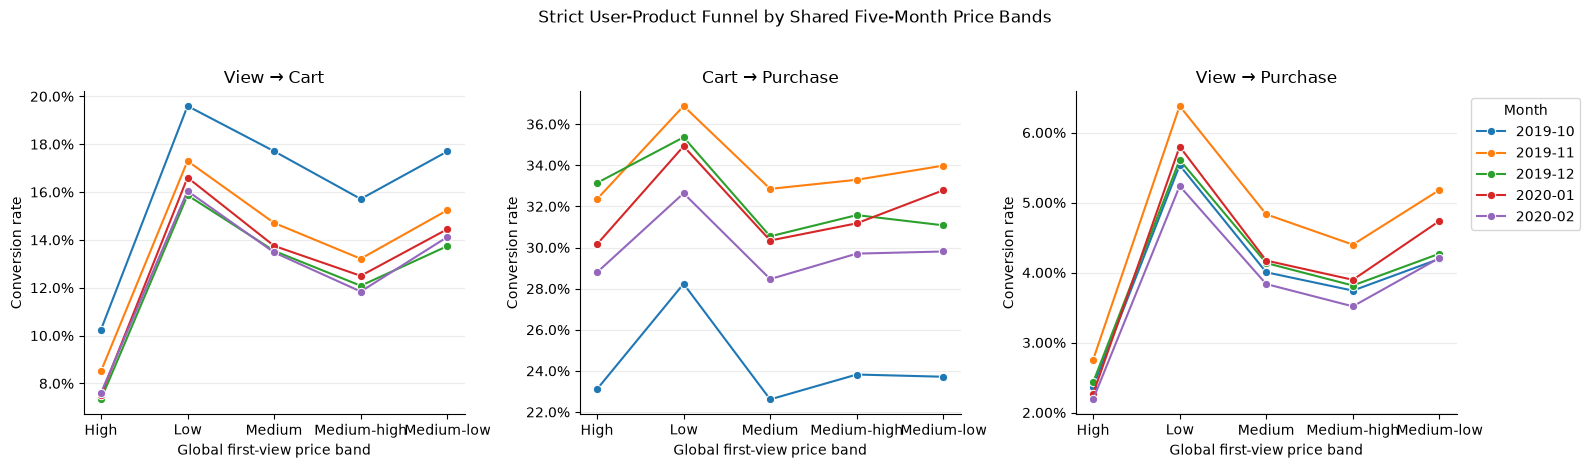

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)
for ax, metric in zip(axes, PRICE_FUNNEL_METRICS):
    plot_data = global_price_rates.loc[global_price_rates["metric"].eq(metric)]
    sns.lineplot(
        data=plot_data,
        x="global_price_band",
        y="conversion_rate",
        hue="month",
        hue_order=MONTH_ORDER,
        marker="o",
        ax=ax,
    )
    ax.set_title(metric)
    ax.set_xlabel("Global first-view price band")
    ax.set_ylabel("Conversion rate")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(axis="y", alpha=0.25)
    if ax is not axes[-1]:
        ax.get_legend().remove()
    else:
        ax.legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle(
    "Strict User-Product Funnel by Shared Five-Month Price Bands",
    y=1.03,
)
sns.despine()
plt.tight_layout()
plt.show()

#### Within-Month Quantile Sensitivity

The sensitivity analysis below creates five quantile-style bands independently inside each month. These bands compare a product's **relative price rank within its own month** and test whether the gradient is robust to month-specific price distributions. Their dollar ranges differ by month, so they must not be used for direct cross-month price-level comparisons; only the shared global bands above provide that comparison.

,month,within_month_price_band,lower_boundary,upper_boundary,viewed_pairs
0,2019-10,Low,$0.05,$2.38,"267,592"
1,2019-10,Medium-low,$2.38,$4.11,"285,304"
2,2019-10,Medium,$4.11,$6.18,"283,092"
3,2019-10,Medium-high,$6.18,$12.38,"282,757"
4,2019-10,High,$12.38,$307.60,"279,960"
5,2019-11,Low,$0.05,$2.28,"303,217"
6,2019-11,Medium-low,$2.28,$3.96,"287,523"
7,2019-11,Medium,$3.96,$5.71,"314,432"
8,2019-11,Medium-high,$5.71,$11.66,"309,589"
9,2019-11,High,$11.66,$327.78,"304,026"


metric                                                        View → Cart  \
month   within_month_price_band                                             
2019-10 High                     10.24% [10.13%, 10.35%] (28,673/279,960)   
        Low                      19.60% [19.45%, 19.75%] (52,438/267,592)   
        Medium                   17.71% [17.57%, 17.85%] (50,139/283,092)   
        Medium-high              15.69% [15.55%, 15.82%] (44,357/282,757)   
        Medium-low               17.70% [17.56%, 17.84%] (50,488/285,304)   
2019-11 High                        8.69% [8.59%, 8.79%] (26,415/304,026)   
        Low                      17.36% [17.23%, 17.50%] (52,647/303,217)   
        Medium                   14.79% [14.67%, 14.91%] (46,505/314,432)   
        Medium-high              13.39% [13.27%, 13.51%] (41,451/309,589)   
        Medium-low               15.30% [15.17%, 15.43%] (43,994/287,523)   
2019-12 High                        7.26% [7.16%, 7.36%] (18,431/253,797)   
        Low                      15.87% [15.72%, 16.01%] (38,268/241,198)   
        Medium                   13.47% [13.34%, 13.61%] (33,893/251,543)   
        Medium-high              11.98% [11.86%, 12.11%] (30,619/255,498)   
        Medium-low               13.81% [13.68%, 13.94%] (36,462/264,095)   
2020-01 High                        7.49% [7.39%, 7.58%] (22,735/303,656)   
        Low                      16.54% [16.41%, 16.68%] (49,397/298,625)   
        Medium                   13.79% [13.66%, 13.91%] (41,121/298,291)   
        Medium-high              12.47% [12.35%, 12.59%] (37,680/302,232)   
        Medium-low               14.24% [14.11%, 14.37%] (42,180/296,228)   
2020-02 High                        7.61% [7.51%, 7.71%] (21,901/287,794)   
        Low                      16.07% [15.94%, 16.20%] (45,923/285,781)   
        Medium                   13.52% [13.39%, 13.64%] (38,720/286,452)   
        Medium-high              11.75% [11.63%, 11.87%] (33,615/286,025)   
        Medium-low               13.90% [13.77%, 14.03%] (39,694/285,548)   

metric                                                   Cart → Purchase  \
month   within_month_price_band                                            
2019-10 High                      23.12% [22.63%, 23.61%] (6,629/28,673)   
        Low                      28.24% [27.85%, 28.62%] (14,806/52,438)   
        Medium                   22.65% [22.29%, 23.02%] (11,357/50,139)   
        Medium-high              23.78% [23.39%, 24.18%] (10,549/44,357)   
        Medium-low               23.71% [23.35%, 24.09%] (11,973/50,488)   
2019-11 High                      32.31% [31.75%, 32.88%] (8,536/26,415)   
        Low                      37.16% [36.75%, 37.57%] (19,564/52,647)   
        Medium                   32.64% [32.21%, 33.06%] (15,178/46,505)   
        Medium-high              33.25% [32.80%, 33.71%] (13,784/41,451)   
        Medium-low               34.27% [33.83%, 34.72%] (15,077/43,994)   
2019-12 High                      32.98% [32.31%, 33.66%] (6,079/18,431)   
        Low                      35.36% [34.88%, 35.84%] (13,532/38,268)   
        Medium                   30.52% [30.03%, 31.01%] (10,344/33,893)   
        Medium-high               31.72% [31.20%, 32.24%] (9,712/30,619)   
        Medium-low               31.07% [30.59%, 31.54%] (11,328/36,462)   
2020-01 High                      30.12% [29.52%, 30.72%] (6,847/22,735)   
        Low                      34.76% [34.34%, 35.18%] (17,169/49,397)   
        Medium                   30.45% [30.01%, 30.90%] (12,523/41,121)   
        Medium-high              31.15% [30.68%, 31.62%] (11,737/37,680)   
        Medium-low               32.62% [32.17%, 33.07%] (13,759/42,180)   
2020-02 High                      28.83% [28.23%, 29.43%] (6,313/21,901)   
        Low                      32.65% [32.22%, 33.08%] (14,994/45,923)   
        Medium                   28.68% [28.23%, 29.13%] (11,104/38,720)   
        Medium-high 

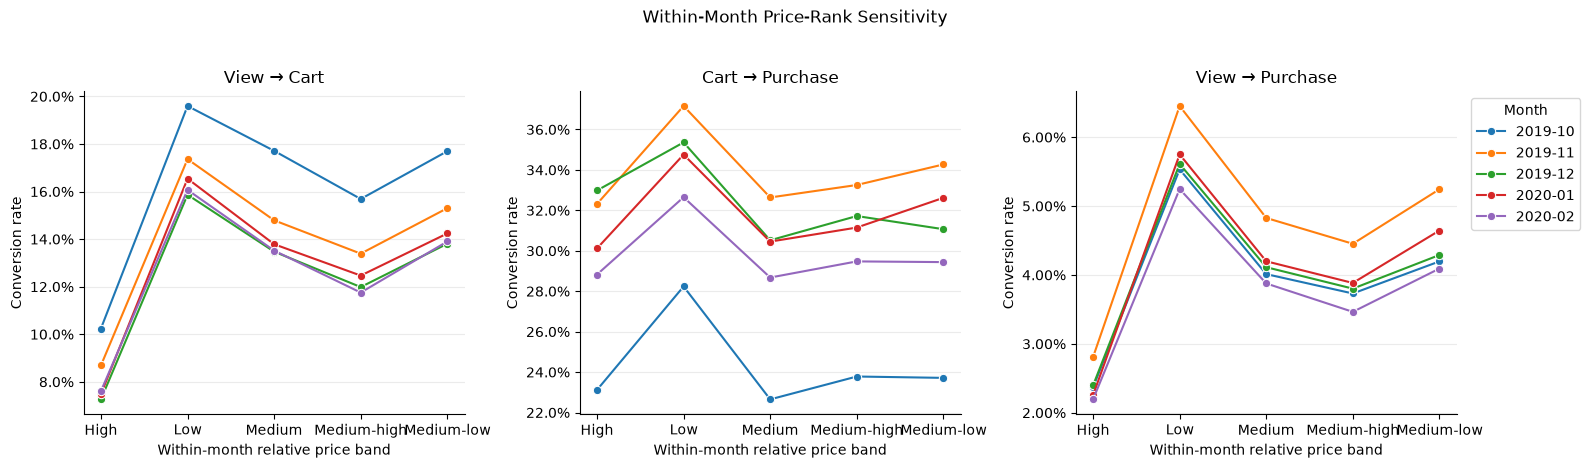

In [90]:
valid_price_funnel["within_month_price_band"] = pd.Categorical(
    [None] * len(valid_price_funnel),
    categories=PRICE_BAND_LABELS,
    ordered=True,
)
within_month_boundary_rows = []
for month_key in MONTH_ORDER:
    month_mask = valid_price_funnel["month"].eq(month_key)
    month_edges = five_quantile_edges(
        valid_price_funnel.loc[month_mask, "view_price"]
    )
    month_bands = apply_price_edges(
        valid_price_funnel.loc[month_mask, "view_price"], month_edges
    )
    valid_price_funnel.loc[
        month_mask, "within_month_price_band"
    ] = month_bands.astype("object")
    month_counts = month_bands.value_counts(sort=False).reindex(
        PRICE_BAND_LABELS, fill_value=0
    )
    within_month_boundary_rows.extend([
        {
            "month": month_key,
            "within_month_price_band": label,
            "lower_boundary": month_edges[index],
            "upper_boundary": month_edges[index + 1],
            "viewed_pairs": int(month_counts.loc[label]),
        }
        for index, label in enumerate(PRICE_BAND_LABELS)
    ])
valid_price_funnel["within_month_price_band"] = pd.Categorical(
    valid_price_funnel["within_month_price_band"],
    categories=PRICE_BAND_LABELS,
    ordered=True,
)
within_month_price_boundaries = pd.DataFrame(within_month_boundary_rows)
display(
    within_month_price_boundaries.style.format({
        "lower_boundary": "${:,.2f}",
        "upper_boundary": "${:,.2f}",
        "viewed_pairs": "{:,.0f}",
    })
)
within_month_price_rates = summarize_price_funnel(
    valid_price_funnel,
    "within_month_price_band",
)
within_month_rate_display = within_month_price_rates.assign(
    estimate=lambda frame: frame.apply(compact_rate_cell, axis=1)
).pivot(
    index=["month", "within_month_price_band"],
    columns="metric",
    values="estimate",
).reindex(columns=PRICE_FUNNEL_METRICS)
display(within_month_rate_display)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)
for ax, metric in zip(axes, PRICE_FUNNEL_METRICS):
    plot_data = within_month_price_rates.loc[
        within_month_price_rates["metric"].eq(metric)
    ]
    sns.lineplot(
        data=plot_data,
        x="within_month_price_band",
        y="conversion_rate",
        hue="month",
        hue_order=MONTH_ORDER,
        marker="o",
        ax=ax,
    )
    ax.set_title(metric)
    ax.set_xlabel("Within-month relative price band")
    ax.set_ylabel("Conversion rate")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(axis="y", alpha=0.25)
    if ax is not axes[-1]:
        ax.get_legend().remove()
    else:
        ax.legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Within-Month Price-Rank Sensitivity", y=1.03)
sns.despine()
plt.tight_layout()
plt.show()

#### Price Effects Within Major Brands and Categories

Major groups follow the October volume convention, now applied transparently to the complete five-month viewed-pair funnel: retain groups with at least 1,000 viewed pairs and 200 qualified carts, then take the 10 largest brands and 15 largest `category_id` values by viewed-pair volume. Missing brands/categories are retained in the funnel but are not treated as named groups. Group selection uses all viewed pairs; the report also shows how many have valid first-view prices. `category_id` is preserved because `category_code` is mostly missing.

For rate displays, any cell with fewer than 200 observations in its stage-specific denominator is labeled `insufficient` rather than interpreted. Thus View→Cart and View→Purchase require 200 views in the cell, while Cart→Purchase requires 200 qualified carts.

In [91]:
FIVE_MONTH_MIN_GROUP_VIEWS = 1_000
FIVE_MONTH_MIN_GROUP_CARTS = 200
FIVE_MONTH_TOP_BRANDS = 10
FIVE_MONTH_TOP_CATEGORIES = 15
MIN_GROUP_BAND_DENOMINATOR = 200


def select_major_groups(data, group_column, top_n):
    volumes = (
        data.dropna(subset=[group_column])
        .groupby(group_column, observed=True)
        .agg(
            viewed_pairs=("reached_view", "sum"),
            qualified_cart_pairs=("reached_cart", "sum"),
            qualified_purchase_pairs=("reached_purchase", "sum"),
            valid_price_pairs=("valid_view_price", "sum"),
        )
        .reset_index()
    )
    return (
        volumes.loc[
            volumes["viewed_pairs"].ge(FIVE_MONTH_MIN_GROUP_VIEWS)
            & volumes["qualified_cart_pairs"].ge(FIVE_MONTH_MIN_GROUP_CARTS)
        ]
        .nlargest(top_n, "viewed_pairs")
        .reset_index(drop=True)
    )


major_brand_report = select_major_groups(
    five_month_price_funnel, "view_brand", FIVE_MONTH_TOP_BRANDS
)
major_category_report = select_major_groups(
    five_month_price_funnel, "view_category_id", FIVE_MONTH_TOP_CATEGORIES
)
for report in (major_brand_report, major_category_report):
    display(
        report.style.format({
            "viewed_pairs": "{:,.0f}",
            "qualified_cart_pairs": "{:,.0f}",
            "qualified_purchase_pairs": "{:,.0f}",
            "valid_price_pairs": "{:,.0f}",
        })
    )


def summarize_major_group_price_effects(data, group_column, selected_groups):
    counts = (
        data.loc[data[group_column].isin(selected_groups)]
        .groupby(
            [group_column, "global_price_band"],
            observed=True,
            dropna=False,
        )
        .agg(
            viewed_pairs=("reached_view", "sum"),
            carted_pairs=("reached_cart", "sum"),
            purchased_pairs=("reached_purchase", "sum"),
        )
        .reset_index()
    )
    rows = []
    for record in counts.to_dict("records"):
        for metric, numerator, denominator in [
            ("View → Cart", record["carted_pairs"], record["viewed_pairs"]),
            (
                "Cart → Purchase",
                record["purchased_pairs"],
                record["carted_pairs"],
            ),
            (
                "View → Purchase",
                record["purchased_pairs"],
                record["viewed_pairs"],
            ),
        ]:
            ci_low, ci_high = wilson_95(numerator, denominator)
            rows.append({
                group_column: record[group_column],
                "global_price_band": record["global_price_band"],
                "metric": metric,
                "numerator": int(numerator),
                "denominator": int(denominator),
                "conversion_rate": safe_ratio(numerator, denominator),
                "ci_95_low": ci_low,
                "ci_95_high": ci_high,
            })
    return pd.DataFrame(rows)


def display_group_price_rates(summary, group_column, group_order):
    formatted = summary.assign(
        estimate=lambda frame: frame.apply(
            compact_rate_cell,
            axis=1,
            minimum_denominator=MIN_GROUP_BAND_DENOMINATOR,
        )
    )
    for metric in PRICE_FUNNEL_METRICS:
        print(metric)
        display(
            formatted.loc[formatted["metric"].eq(metric)]
            .pivot(
                index=group_column,
                columns="global_price_band",
                values="estimate",
            )
            .reindex(index=group_order, columns=PRICE_BAND_LABELS)
        )


brand_price_rates = summarize_major_group_price_effects(
    valid_price_funnel,
    "view_brand",
    major_brand_report["view_brand"].tolist(),
)
category_price_rates = summarize_major_group_price_effects(
    valid_price_funnel,
    "view_category_id",
    major_category_report["view_category_id"].tolist(),
)
display_group_price_rates(
    brand_price_rates,
    "view_brand",
    major_brand_report["view_brand"].tolist(),
)
display_group_price_rates(
    category_price_rates,
    "view_category_id",
    major_category_report["view_category_id"].tolist(),
)

,view_brand,viewed_pairs,qualified_cart_pairs,qualified_purchase_pairs,valid_price_pairs
0,runail,"448,293","67,512","22,324","448,287"
1,irisk,"308,303","43,960","13,930","308,303"
2,grattol,"289,025","41,899","11,744","289,025"
3,masura,"248,072","34,521","9,208","248,070"
4,estel,"155,921","19,755","6,525","155,921"
5,kapous,"144,436","14,754","4,771","144,436"
6,ingarden,"130,559","19,816","5,712","130,557"
7,bpw.style,"127,904","19,802","6,014","127,904"
8,jessnail,"120,986","9,423","2,642","120,986"
9,concept,"92,997","10,763","3,402","92,997"


,view_category_id,viewed_pairs,qualified_cart_pairs,qualified_purchase_pairs,valid_price_pairs
0,1487580007675986893,"306,020","43,302","12,396","301,855"
1,1487580005092295511,"296,004","42,699","12,100","295,621"
2,1487580005595612013,"221,493","33,254","9,324","221,414"
3,1602943681873052386,"216,159","30,889","8,623","216,147"
4,1487580006300255120,"190,958","9,579","2,569","190,754"
5,1487580013841613016,"186,773","17,194","4,789","186,752"
6,1487580008246412266,"178,265","20,955","6,194","177,605"
7,1487580005268456287,"170,689","22,375","7,436","170,414"
8,1487580013950664926,"165,424","11,092","3,177","164,553"
9,1487580005671109489,"164,655","26,044","7,258","164,504"


View → Cart


global_price_band,Low,Medium-low,Medium,Medium-high,High
view_brand,,,,,
runail,"19.99% [19.77%, 20.21%] (25,023/125,200)","16.10% [15.92%, 16.29%] (24,027/149,223)","13.64% [13.38%, 13.91%] (8,628/63,234)","12.87% [12.54%, 13.20%] (5,141/39,961)","6.64% [6.46%, 6.83%] (4,693/70,669)"
irisk,"17.08% [16.85%, 17.31%] (17,908/104,842)","16.10% [15.87%, 16.33%] (15,827/98,325)","11.34% [10.95%, 11.75%] (2,683/23,652)","11.95% [11.60%, 12.30%] (4,041/33,829)","7.35% [7.12%, 7.58%] (3,501/47,655)"
grattol,"21.61% [20.35%, 22.93%] (846/3,915)","21.29% [20.29%, 22.34%] (1,306/6,133)","14.08% [13.94%, 14.23%] (32,008/227,300)","15.11% [14.79%, 15.43%] (7,295/48,295)","13.13% [12.03%, 14.31%] (444/3,382)"
masura,"15.76% [15.56%, 15.97%] (19,201/121,812)","11.99% [11.76%, 12.24%] (8,465/70,576)","12.99% [12.60%, 13.39%] (3,679/28,323)","12.39% [11.93%, 12.87%] (2,340/18,884)","9.86% [9.25%, 10.52%] (836/8,475)"
estel,"18.06% [17.20%, 18.97%] (1,310/7,252)","11.28% [10.92%, 11.66%] (3,155/27,963)","14.60% [14.24%, 14.97%] (5,266/36,060)","13.45% [13.18%, 13.73%] (7,915/58,832)","8.17% [7.84%, 8.51%] (2,109/25,814)"
kapous,"22.56% [21.50%, 23.65%] (1,300/5,763)","7.80% [7.62%, 7.97%] (6,885/88,313)","13.26% [12.93%, 13.59%] (5,346/40,317)","12.43% [11.78%, 13.12%] (1,160/9,329)","8.82% [6.96%, 11.13%] (63/714)"
ingarden,"15.86% [15.24%, 16.50%] (2,034/12,823)","18.41% [17.88%, 18.96%] (3,687/20,023)","15.67% [15.40%, 15.94%] (11,073/70,681)","12.44% [11.96%, 12.94%] (2,171/17,452)","8.88% [8.33%, 9.47%] (851/9,578)"
bpw.style,"15.48% [15.28%, 15.68%] (19,802/127,904)",NaN,NaN,NaN,NaN
jessnail,"17.56% [16.73%, 18.42%] (1,372/7,813)","16.48% [15.54%, 17.47%] (932/5,655)","12.88% [10.72%, 15.39%] (102/792)","7.11% [6.15%, 8.20%] (172/2,420)","6.56% [6.41%, 6.71%] (6,845/104,306)"


Cart → Purchase


...

global_price_band,Low,Medium-low,Medium,Medium-high,High
view_category_id,,,,,
1487580007675986893,"14.39% [14.26%, 14.52%] (40,479/281,366)","13.30% [12.77%, 13.84%] (2,069/15,557)",insufficient (n=38),"5.54% [4.93%, 6.21%] (271/4,894)",NaN
1487580005092295511,"11.65% [10.68%, 12.68%] (461/3,958)","15.30% [14.79%, 15.83%] (2,816/18,400)","15.00% [14.70%, 15.31%] (7,847/52,300)","14.20% [14.04%, 14.36%] (25,031/176,309)","14.60% [14.27%, 14.93%] (6,518/44,654)"
1487580005595612013,"10.96% [10.53%, 11.41%] (2,112/19,273)","15.65% [15.49%, 15.82%] (29,132/186,116)","12.72% [12.09%, 13.38%] (1,294/10,174)","15.87% [14.70%, 17.11%] (562/3,541)","5.97% [5.08%, 7.02%] (138/2,310)"
1602943681873052386,NaN,"11.67% [9.30%, 14.56%] (67/574)","14.30% [14.15%, 14.45%] (30,822/215,573)",NaN,NaN
1487580006300255120,"13.48% [11.97%, 15.15%] (240/1,780)",NaN,"16.27% [12.91%, 20.31%] (62/381)",NaN,"4.92% [4.82%, 5.01%] (9,270/188,593)"
1487580013841613016,"14.66% [13.71%, 15.67%] (728/4,965)","8.00% [7.84%, 8.16%] (8,691/108,697)","10.59% [10.28%, 10.90%] (3,918/37,009)","11.54% [11.13%, 11.96%] (2,614/22,648)","9.25% [8.77%, 9.76%] (1,243/13,433)"
1487580008246412266,"15.26% [13.58%, 17.11%] (244/1,599)","13.86% [13.13%, 14.63%] (1,119/8,072)","13.61% [13.28%, 13.94%] (5,637/41,420)","12.39% [12.15%, 12.63%] (9,166/73,987)","9.09% [8.85%, 9.34%] (4,776/52,527)"
1487580005268456287,"12.27% [9.14%, 16.28%] (40/326)","12.87% [12.38%, 13.37%] (2,293/17,819)","13.71% [13.33%, 14.10%] (4,224/30,801)","12.81% [12.61%, 13.02%] (13,329/104,022)","14.22% [13.70%, 14.74%] (2,480/17,446)"
1487580013950664926,"2.91% [1.54%, 5.44%] (9/309)","6.82% [5.81%, 8.00%] (139/2,037)","12.41% [11.26%, 13.65%] (363/2,926)","11.93% [11.47%, 12.41%] (2,206/18,490)","5.93% [5.80%, 6.05%] (8,343/140,791)"


Cart → Purchase


global_price_band,Low,Medium-low,Medium,Medium-high,High
view_category_id,,,,,
1487580007675986893,"28.94% [28.50%, 29.39%] (11,716/40,479)","25.57% [23.73%, 27.49%] (529/2,069)",insufficient (n=1),"22.14% [17.61%, 27.45%] (60/271)",NaN
1487580005092295511,"19.31% [15.96%, 23.16%] (89/461)","26.63% [25.03%, 28.30%] (750/2,816)","27.05% [26.08%, 28.05%] (2,123/7,847)","28.32% [27.77%, 28.88%] (7,089/25,031)","31.33% [30.21%, 32.47%] (2,042/6,518)"
1487580005595612013,"23.67% [21.91%, 25.53%] (500/2,112)","28.29% [27.77%, 28.81%] (8,240/29,132)","29.75% [27.32%, 32.30%] (385/1,294)","30.60% [26.94%, 34.54%] (172/562)",insufficient (n=138)
1602943681873052386,NaN,insufficient (n=67),"27.93% [27.43%, 28.43%] (8,609/30,822)",NaN,NaN
1487580006300255120,"20.42% [15.80%, 25.96%] (49/240)",NaN,insufficient (n=62),NaN,"26.94% [26.04%, 27.85%] (2,497/9,270)"
1487580013841613016,"24.18% [21.21%, 27.42%] (176/728)","30.43% [29.48%, 31.41%] (2,645/8,691)","29.10% [27.70%, 30.54%] (1,140/3,918)","23.07% [21.49%, 24.72%] (603/2,614)","18.10% [16.06%, 20.34%] (225/1,243)"
1487580008246412266,"37.70% [31.86%, 43.93%] (92/244)","30.47% [27.85%, 33.23%] (341/1,119)","30.73% [29.53%, 31.94%] (1,732/5,637)","29.46% [28.53%, 30.40%] (2,700/9,166)","27.70% [26.45%, 28.99%] (1,323/4,776)"
1487580005268456287,insufficient (n=40),"33.10% [31.20%, 35.05%] (759/2,293)","32.91% [31.51%, 34.34%] (1,390/4,224)","32.79% [32.00%, 33.59%] (4,371/13,329)","36.25% [34.38%, 38.16%] (899/2,480)"
1487580013950664926,insufficient (n=9),insufficient (n=139),"28.65% [24.24%, 33.51%] (104/363)","23.75% [22.02%, 25.57%] (524/2,206)","29.92% [28.94%, 30.91%] (2,496/8,343)"


View → Purchase


global_price_band,Low,Medium-low,Medium,Medium-high,High
view_category_id,,,,,
1487580007675986893,"4.16% [4.09%, 4.24%] (11,716/281,366)","3.40% [3.13%, 3.70%] (529/15,557)",insufficient (n=38),"1.23% [0.95%, 1.57%] (60/4,894)",NaN
1487580005092295511,"2.25% [1.83%, 2.76%] (89/3,958)","4.08% [3.80%, 4.37%] (750/18,400)","4.06% [3.89%, 4.23%] (2,123/52,300)","4.02% [3.93%, 4.11%] (7,089/176,309)","4.57% [4.38%, 4.77%] (2,042/44,654)"
1487580005595612013,"2.59% [2.38%, 2.83%] (500/19,273)","4.43% [4.33%, 4.52%] (8,240/186,116)","3.78% [3.43%, 4.17%] (385/10,174)","4.86% [4.20%, 5.62%] (172/3,541)","1.04% [0.70%, 1.54%] (24/2,310)"
1602943681873052386,NaN,"2.44% [1.46%, 4.05%] (14/574)","3.99% [3.91%, 4.08%] (8,609/215,573)",NaN,NaN
1487580006300255120,"2.75% [2.09%, 3.62%] (49/1,780)",NaN,"5.77% [3.84%, 8.59%] (22/381)",NaN,"1.32% [1.27%, 1.38%] (2,497/188,593)"
1487580013841613016,"3.54% [3.07%, 4.10%] (176/4,965)","2.43% [2.34%, 2.53%] (2,645/108,697)","3.08% [2.91%, 3.26%] (1,140/37,009)","2.66% [2.46%, 2.88%] (603/22,648)","1.67% [1.47%, 1.91%] (225/13,433)"
1487580008246412266,"5.75% [4.71%, 7.00%] (92/1,599)","4.22% [3.81%, 4.69%] (341/8,072)","4.18% [3.99%, 4.38%] (1,732/41,420)","3.65% [3.52%, 3.79%] (2,700/73,987)","2.52% [2.39%, 2.66%] (1,323/52,527)"
1487580005268456287,"4.29% [2.58%, 7.08%] (14/326)","4.26% [3.97%, 4.57%] (759/17,819)","4.51% [4.29%, 4.75%] (1,390/30,801)","4.20% [4.08%, 4.33%] (4,371/104,022)","5.15% [4.83%, 5.49%] (899/17,446)"
1487580013950664926,"0.32% [0.06%, 1.81%] (1/309)","1.72% [1.24%, 2.38%] (35/2,037)","3.55% [2.94%, 4.29%] (104/2,926)","2.83% [2.60%, 3.08%] (524/18,490)","1.77% [1.71%, 1.84%] (2,496/140,791)"


#### Price Band × Month Interaction Tests

Each funnel stage is tested separately with grouped binomial GLMs, avoiding expansion back to millions of pair rows. The additive model contains month and shared global price-band main effects; the comparison model also contains their interaction. View→Cart and View→Purchase use viewed pairs as their binomial risk sets, while Cart→Purchase uses only qualified carts. A significant likelihood-ratio test means the association between global price band and conversion varies by month; it does not identify which month/band drives the difference and does not imply causality. Holm-adjusted p-values control family-wise error across the three stage tests.

In [92]:
import warnings


def interaction_design_matrices(grouped):
    month_dummies = pd.get_dummies(
        grouped["month"].astype("string"),
        prefix="month",
        drop_first=True,
        dtype="float64",
    )
    band_dummies = pd.get_dummies(
        grouped["global_price_band"].astype("string"),
        prefix="band",
        drop_first=True,
        dtype="float64",
    )
    intercept = pd.DataFrame(
        {"intercept": np.ones(len(grouped))}, index=grouped.index
    )
    additive = pd.concat([intercept, month_dummies, band_dummies], axis=1)
    interaction = pd.DataFrame(
        {
            f"{month_column}:{band_column}": (
                month_dummies[month_column] * band_dummies[band_column]
            )
            for month_column in month_dummies
            for band_column in band_dummies
        },
        index=grouped.index,
    )
    return additive, pd.concat([additive, interaction], axis=1)


def grouped_price_month_interaction_test(rate_summary, metric):
    grouped = (
        rate_summary.loc[
            rate_summary["metric"].eq(metric),
            ["month", "global_price_band", "numerator", "denominator"],
        ]
        .loc[lambda frame: frame["denominator"].gt(0)]
        .reset_index(drop=True)
    )
    result = {
        "metric": metric,
        "test_statistic": np.nan,
        "degrees_of_freedom": np.nan,
        "p_value": np.nan,
        "status": "not fitted",
    }
    try:
        if grouped["month"].nunique() < 2:
            raise ValueError("fewer than two represented months")
        if grouped["global_price_band"].nunique() < 2:
            raise ValueError("fewer than two represented price bands")
        if (grouped["numerator"] > grouped["denominator"]).any():
            raise ValueError("a numerator exceeds its stage-specific denominator")
        boundary_cells = grouped["numerator"].eq(0) | grouped[
            "numerator"
        ].eq(grouped["denominator"])
        if boundary_cells.any():
            raise RuntimeError(
                "zero-success or all-success cells create separation risk"
            )
        additive_x, full_x = interaction_design_matrices(grouped)
        additive_rank = np.linalg.matrix_rank(additive_x.to_numpy())
        full_rank = np.linalg.matrix_rank(full_x.to_numpy())
        if additive_rank < additive_x.shape[1] or full_rank < full_x.shape[1]:
            raise ValueError("additive or interaction design matrix is singular")
        degrees_of_freedom = full_rank - additive_rank
        if degrees_of_freedom <= 0:
            raise ValueError("interaction design has no estimable degrees of freedom")
        endog = grouped["numerator"] / grouped["denominator"]
        weights = grouped["denominator"].astype("float64")
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            additive_fit = sm.GLM(
                endog,
                additive_x,
                family=sm.families.Binomial(),
                freq_weights=weights,
            ).fit(maxiter=100, disp=0)
            full_fit = sm.GLM(
                endog,
                full_x,
                family=sm.families.Binomial(),
                freq_weights=weights,
            ).fit(maxiter=100, disp=0)
        if not additive_fit.converged or not full_fit.converged:
            raise RuntimeError("one or both GLMs did not converge")
        statistic = max(0.0, 2 * (full_fit.llf - additive_fit.llf))
        if not np.isfinite(statistic):
            raise RuntimeError("non-finite likelihood-ratio statistic")
        non_saturation_warnings = {
            str(item.message)
            for item in caught
            if "perfect separation" not in str(item.message).lower()
        }
        warning_text = "; ".join(sorted(non_saturation_warnings))
        result.update({
            "test_statistic": statistic,
            "degrees_of_freedom": int(degrees_of_freedom),
            "p_value": stats.chi2.sf(statistic, degrees_of_freedom),
            "status": "ok" if not warning_text else f"ok; {warning_text}",
        })
    except Exception as error:
        result["status"] = f"failed gracefully: {type(error).__name__}: {error}"
    return result


def holm_adjust(p_values):
    adjusted = pd.Series(np.nan, index=p_values.index, dtype="float64")
    valid = p_values.dropna().sort_values()
    running_maximum = 0.0
    total = len(valid)
    for rank, (index, p_value) in enumerate(valid.items()):
        running_maximum = max(running_maximum, (total - rank) * p_value)
        adjusted.loc[index] = min(1.0, running_maximum)
    return adjusted


price_month_interaction_tests = pd.DataFrame([
    grouped_price_month_interaction_test(global_price_rates, metric)
    for metric in PRICE_FUNNEL_METRICS
])
price_month_interaction_tests["holm_adjusted_p_value"] = holm_adjust(
    price_month_interaction_tests["p_value"]
)
price_month_interaction_tests = price_month_interaction_tests[
    [
        "metric",
        "test_statistic",
        "degrees_of_freedom",
        "p_value",
        "holm_adjusted_p_value",
        "status",
    ]
]
display(
    price_month_interaction_tests.style.format({
        "test_statistic": "{:,.3f}",
        "degrees_of_freedom": "{:.0f}",
        "p_value": "{:.3g}",
        "holm_adjusted_p_value": "{:.3g}",
    }, na_rep="—")
)

,metric,test_statistic,degrees_of_freedom,p_value,holm_adjusted_p_value,status
0,View → Cart,259.929,16,4.73e-46,1.42e-45,ok; divide by zero encountered in scalar divide
1,Cart → Purchase,143.904,16,1.24e-22,2.47e-22,ok; divide by zero encountered in scalar divide
2,View → Purchase,116.707,16,2.35e-17,2.35e-17,ok; divide by zero encountered in scalar divide


### Section Conclusion

The five-month analysis provides strong and temporally consistent evidence of a negative association between product price and conversion. Using shared price bands, products in the highest band ($12.31 – $327.78) had substantially lower View→Cart conversion than products in the lowest band ($0.05 – $2.38) in every month. The monthly difference ranged from 8.44 to 9.36 percentage points.

This pattern continued through the complete funnel. View→Purchase conversion was 5.24%–6.38% for low-priced products, compared with only 2.19%–2.75% for high-priced products. Thus, high-priced products were approximately 57%–61% less likely to complete the ordered funnel.

Most of the difference occurred before products were added to the cart:

- View→Cart was approximately 48%–55% lower for high-priced products.
- Cart→Purchase was only approximately 6%–18% lower.

The within-month quantile sensitivity analysis produced the same general pattern, indicating that the result is not an artifact of applying one set of global price boundaries. Similar declines were also observed within several major brands, including Runail and Irisk, reducing the likelihood that the aggregate result is explained entirely by brand composition.

The significant price-band × month interactions show that the strength of the association changes over time.

These interactions do not contradict the hypothesis: the direction remains negative in every month, while its magnitude varies. Category-level results are less uniform, however, indicating that the price relationship is not universal for every product category.

Overall, the October hypothesis is supported across all five months: high-priced products experience lower end-to-end conversion, and the dominant source of friction occurs at the View→Cart stage. This suggests that high-priced products may benefit most from stronger pre-cart value communication, including detailed product information, reviews, benefits, comparisons, and reassurance.

##### Important statistical qualification

The interaction tests assess whether the price relationship changes by month; they do not directly test whether an overall price effect exists. Furthermore, this observational analysis cannot establish causality because price is related to brand, category, product quality, promotions, and customer mix. The model output also contains a divide-by-zero fitting warning; it does not necessarily invalidate the likelihood-ratio results, but it should be resolved before treating those tests as final evidence.

### Five-Month Repeated-View Hypothesis Validation

This validation uses a fixed landmark design to reduce reverse causality and equalize observation time. Each (user_id, product_id) pair is assigned to the month of its first observed view. By default, views are counted only in the 7-day exposure interval [first view, first view + 7 days), followed by a 14-day outcome interval [landmark, landmark + 14 days). The constants below are intentionally configurable.

The primary cohort requires complete exposure plus follow-up coverage and excludes any pair with a cart **or** purchase during exposure. Thus, every counted view precedes any analyzed conversion. The estimand applies only to pairs that remain unconverted through the landmark; it is intentionally different from the earlier full-month descriptive repeated-view analysis. Complete-window exclusions—especially late-February starts—are reported explicitly rather than treated as non-conversions.

Follow-up uses the notebook's strict same-product funnel. A qualifying cart must occur in follow-up, and a purchase qualifies only when its stable event order is later than that cart. Stable sorting by event_time preserves source-row order for same-timestamp ties. These observational associations do not establish that repeated views cause conversion.

In [93]:
LANDMARK_EXPOSURE_DAYS = 7
LANDMARK_FOLLOWUP_DAYS = 14
LANDMARK_VIEW_GROUPS = ["1 view", "2–3 views", "4+ views"]
LANDMARK_KEYS = ["user_id", "product_id"]


def build_repeated_view_landmark(
    data,
    month_order,
    exposure_days=LANDMARK_EXPOSURE_DAYS,
    followup_days=LANDMARK_FOLLOWUP_DAYS,
):
    """Build a fixed-window, strict post-landmark user-product cohort."""
    if exposure_days <= 0 or followup_days <= 0:
        raise ValueError("Exposure and follow-up windows must both be positive.")
    required = set(
        LANDMARK_KEYS
        + ["event_time", "event_type", "price", "brand", "category_id"]
    )
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f"Missing landmark columns: {sorted(missing)}")
    if not data.index.is_unique:
        raise ValueError("A unique row index is required for stable tie ordering.")

    event_time = pd.to_datetime(data["event_time"], utc=True, errors="coerce")
    valid_event = event_time.notna() & data["event_type"].isin(FUNNEL_EVENT_TYPES)
    view_mask = valid_event & data["event_type"].eq("view")
    view_positions = np.flatnonzero(view_mask.to_numpy())
    first_views = data.loc[
        view_mask,
        LANDMARK_KEYS + ["event_time", "price", "brand", "category_id"],
    ].copy()
    first_views["_source_order"] = view_positions
    first_views["event_time"] = event_time.loc[view_mask].to_numpy()
    first_views = (
        first_views.sort_values("event_time", kind="stable")
        .drop_duplicates(LANDMARK_KEYS, keep="first")
        .rename(columns={
            "event_time": "first_view_time",
            "_source_order": "first_view_order",
            "price": "first_view_price",
            "brand": "first_view_brand",
            "category_id": "first_view_category_id",
        })
    )
    first_views["first_view_month"] = first_views[
        "first_view_time"
    ].dt.strftime("%Y-%m")
    first_views = first_views.loc[
        first_views["first_view_month"].isin(month_order)
    ].copy()
    exposure_delta = pd.Timedelta(days=exposure_days)
    followup_delta = pd.Timedelta(days=followup_days)
    first_views["landmark_time"] = first_views["first_view_time"] + exposure_delta
    first_views["followup_end_time"] = (
        first_views["landmark_time"] + followup_delta
    )
    data_end = event_time.loc[valid_event].max()
    first_views["complete_window"] = first_views["followup_end_time"].le(data_end)

    cohort_parts = []
    diagnostic_rows = []
    event_columns = LANDMARK_KEYS + ["event_time", "event_type"]
    for month_key in month_order:
        month_candidates = first_views.loc[
            first_views["first_view_month"].eq(month_key)
        ].copy()
        complete = month_candidates.loc[month_candidates["complete_window"]].copy()

        if complete.empty:
            complete["view_count"] = pd.Series(dtype="int64")
            complete["early_conversion"] = pd.Series(dtype="bool")
            complete["followup_cart"] = pd.Series(dtype="bool")
            complete["followup_purchase"] = pd.Series(dtype="bool")
        else:
            lower = complete["first_view_time"].min()
            upper = complete["followup_end_time"].max()
            time_mask = valid_event & event_time.ge(lower) & event_time.lt(upper)
            event_positions = np.flatnonzero(time_mask.to_numpy())
            events = data.loc[time_mask, event_columns].copy()
            events["event_time"] = event_time.loc[time_mask].to_numpy()
            events["event_order"] = event_positions
            events = events.merge(
                complete[
                    LANDMARK_KEYS
                    + [
                        "first_view_time",
                        "first_view_order",
                        "landmark_time",
                        "followup_end_time",
                    ]
                ],
                on=LANDMARK_KEYS,
                how="inner",
                validate="many_to_one",
            )
            after_first_view = events["event_time"].gt(events["first_view_time"]) | (
                events["event_time"].eq(events["first_view_time"])
                & events["event_order"].ge(events["first_view_order"])
            )
            events = events.loc[after_first_view]
            in_exposure = events["event_time"].lt(events["landmark_time"])
            in_followup = (
                events["event_time"].ge(events["landmark_time"])
                & events["event_time"].lt(events["followup_end_time"])
            )

            exposure_events = events.loc[in_exposure]
            exposure_views = (
                exposure_events.loc[exposure_events["event_type"].eq("view")]
                .groupby(LANDMARK_KEYS, observed=True)
                .size()
                .rename("view_count")
                .reset_index()
            )
            early_pairs = (
                exposure_events.loc[
                    exposure_events["event_type"].isin(["cart", "purchase"]),
                    LANDMARK_KEYS,
                ]
                .drop_duplicates()
                .assign(early_conversion=True)
            )

            followup_events = events.loc[in_followup]
            first_carts = (
                followup_events.loc[
                    followup_events["event_type"].eq("cart"),
                    LANDMARK_KEYS + ["event_time", "event_order"],
                ]
                .sort_values(["event_time", "event_order"], kind="stable")
                .drop_duplicates(LANDMARK_KEYS, keep="first")
                .rename(columns={
                    "event_time": "followup_cart_time",
                    "event_order": "followup_cart_order",
                })
            )
            purchase_candidates = followup_events.loc[
                followup_events["event_type"].eq("purchase"),
                LANDMARK_KEYS + ["event_time", "event_order"],
            ].merge(first_carts, on=LANDMARK_KEYS, how="inner", validate="many_to_one")
            purchase_after_cart = (
                purchase_candidates["event_time"].gt(
                    purchase_candidates["followup_cart_time"]
                )
                | (
                    purchase_candidates["event_time"].eq(
                        purchase_candidates["followup_cart_time"]
                    )
                    & purchase_candidates["event_order"].gt(
                        purchase_candidates["followup_cart_order"]
                    )
                )
            )
            purchased_pairs = (
                purchase_candidates.loc[purchase_after_cart, LANDMARK_KEYS]
                .drop_duplicates()
                .assign(followup_purchase=True)
            )
            carted_pairs = first_carts[LANDMARK_KEYS].assign(followup_cart=True)
            complete = (
                complete.merge(exposure_views, on=LANDMARK_KEYS, how="left")
                .merge(early_pairs, on=LANDMARK_KEYS, how="left")
                .merge(carted_pairs, on=LANDMARK_KEYS, how="left")
                .merge(purchased_pairs, on=LANDMARK_KEYS, how="left")
            )
            complete["view_count"] = complete["view_count"].fillna(0).astype("int64")
            for flag in ["early_conversion", "followup_cart", "followup_purchase"]:
                complete[flag] = complete[flag].fillna(False).astype(bool)
            del events, exposure_events, followup_events, purchase_candidates

        final_month = complete.loc[~complete["early_conversion"]].copy()
        final_month["view_group"] = pd.cut(
            final_month["view_count"],
            bins=[0, 1, 3, np.inf],
            labels=LANDMARK_VIEW_GROUPS,
            ordered=True,
        )
        assert final_month["view_group"].notna().all()
        assert (~final_month["followup_purchase"] | final_month["followup_cart"]).all()
        cohort_parts.append(final_month)

        total = len(month_candidates)
        incomplete = int((~month_candidates["complete_window"]).sum())
        early = int(complete["early_conversion"].sum())
        final = len(final_month)
        diagnostic_rows.append({
            "first_view_month": month_key,
            "candidate_pairs": total,
            "incomplete_window_exclusions": incomplete,
            "incomplete_pct_candidates": safe_ratio(incomplete, total),
            "complete_window_pairs": len(complete),
            "early_conversion_exclusions": early,
            "early_pct_complete": safe_ratio(early, len(complete)),
            "final_landmark_cohort": final,
            "retained_pct_candidates": safe_ratio(final, total),
        })

    cohort = pd.concat(cohort_parts, ignore_index=True, copy=False)
    cohort["first_view_month"] = pd.Categorical(
        cohort["first_view_month"], categories=month_order, ordered=True
    )
    diagnostics = pd.DataFrame(diagnostic_rows)
    assert not cohort.duplicated(LANDMARK_KEYS).any()
    return cohort, diagnostics


def summarize_landmark_rates(cohort):
    counts = (
        cohort.groupby(
            ["first_view_month", "view_group"], observed=True, dropna=False
        )
        .agg(
            cohort_pairs=("product_id", "size"),
            followup_carts=("followup_cart", "sum"),
            followup_purchases=("followup_purchase", "sum"),
        )
        .reset_index()
    )
    rows = []
    for row in counts.itertuples(index=False):
        specifications = [
            ("View → Cart", row.followup_carts, row.cohort_pairs),
            ("View → Purchase", row.followup_purchases, row.cohort_pairs),
            ("Cart → Purchase", row.followup_purchases, row.followup_carts),
        ]
        for outcome, numerator, denominator in specifications:
            low, high = wilson_95(numerator, denominator)
            rows.append({
                "first_view_month": row.first_view_month,
                "view_group": row.view_group,
                "outcome": outcome,
                "numerator": int(numerator),
                "denominator": int(denominator),
                "rate": safe_ratio(numerator, denominator),
                "ci_95_low": low,
                "ci_95_high": high,
            })
    return pd.DataFrame(rows), counts

/var/folders/s2/2gtgcrjj5030j74h5kqtf5vw0000gn/T/ipykernel_34139/2487928076.py:200: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  cohort = pd.concat(cohort_parts, ignore_index=True, copy=False)


,first_view_month,candidate_pairs,incomplete_window_exclusions,incomplete_pct_candidates,complete_window_pairs,early_conversion_exclusions,early_pct_complete,final_landmark_cohort,retained_pct_candidates
0,2019-10,"1,402,922",0,0.00%,"1,402,922","248,414",17.71%,"1,154,508",82.29%
1,2019-11,"1,480,142",0,0.00%,"1,480,142","234,762",15.86%,"1,245,380",84.14%
2,2019-12,"1,215,985",0,0.00%,"1,215,985","169,163",13.91%,"1,046,822",86.09%
3,2020-01,"1,440,508",0,0.00%,"1,440,508","206,893",14.36%,"1,233,615",85.64%
4,2020-02,"1,359,607","965,806",71.04%,"393,801","54,044",13.72%,"339,757",24.99%


,first_view_month,view_group,cohort_pairs,followup_carts,followup_purchases
0,2019-10,1 view,"972,510","4,749","1,329"
1,2019-10,2–3 views,"164,000","1,442",451
2,2019-10,4+ views,"17,998",341,109
3,2019-11,1 view,"1,048,801","5,373","1,532"
4,2019-11,2–3 views,"176,342","1,702",528
5,2019-11,4+ views,"20,237",409,123
6,2019-12,1 view,"879,764","3,236",850
7,2019-12,2–3 views,"150,505",989,321
8,2019-12,4+ views,"16,553",240,75
9,2020-01,1 view,"1,036,951","4,633","1,202"


,first_view_month,view_group,outcome,numerator,denominator,rate,ci_95_low,ci_95_high
0,2019-10,1 view,View → Cart,"4,749","972,510",0.49%,0.47%,0.50%
1,2019-10,1 view,View → Purchase,"1,329","972,510",0.14%,0.13%,0.14%
2,2019-10,1 view,Cart → Purchase,"1,329","4,749",27.98%,26.73%,29.28%
3,2019-10,2–3 views,View → Cart,"1,442","164,000",0.88%,0.84%,0.93%
4,2019-10,2–3 views,View → Purchase,451,"164,000",0.27%,0.25%,0.30%
5,2019-10,2–3 views,Cart → Purchase,451,"1,442",31.28%,28.94%,33.72%
6,2019-10,4+ views,View → Cart,341,"17,998",1.89%,1.71%,2.10%
7,2019-10,4+ views,View → Purchase,109,"17,998",0.61%,0.50%,0.73%
8,2019-10,4+ views,Cart → Purchase,109,341,31.96%,27.24%,37.09%
9,2019-11,1 view,View → Cart,"5,373","1,048,801",0.51%,0.50%,0.53%


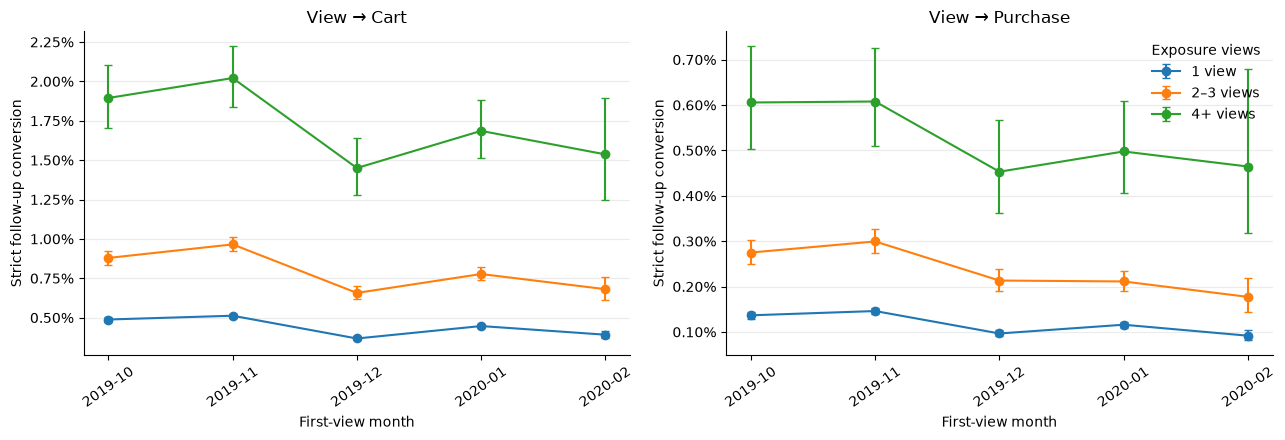

In [95]:
repeated_view_landmark, repeated_view_retention = build_repeated_view_landmark(
    five_month_df,
    MONTH_ORDER,
    exposure_days=LANDMARK_EXPOSURE_DAYS,
    followup_days=LANDMARK_FOLLOWUP_DAYS,
)
landmark_monthly_rates, landmark_monthly_counts = summarize_landmark_rates(
    repeated_view_landmark
)

display(
    repeated_view_retention.style.format({
        "candidate_pairs": "{:,.0f}",
        "incomplete_window_exclusions": "{:,.0f}",
        "incomplete_pct_candidates": "{:.2%}",
        "complete_window_pairs": "{:,.0f}",
        "early_conversion_exclusions": "{:,.0f}",
        "early_pct_complete": "{:.2%}",
        "final_landmark_cohort": "{:,.0f}",
        "retained_pct_candidates": "{:.2%}",
    }, na_rep="—")
)
display(
    landmark_monthly_counts.style.format({
        "cohort_pairs": "{:,.0f}",
        "followup_carts": "{:,.0f}",
        "followup_purchases": "{:,.0f}",
    }, na_rep="—")
)
display(
    landmark_monthly_rates.style.format({
        "numerator": "{:,.0f}",
        "denominator": "{:,.0f}",
        "rate": "{:.2%}",
        "ci_95_low": "{:.2%}",
        "ci_95_high": "{:.2%}",
    }, na_rep="—")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for ax, outcome in zip(axes, ["View → Cart", "View → Purchase"]):
    plot_data = landmark_monthly_rates.loc[
        landmark_monthly_rates["outcome"].eq(outcome)
    ]
    for view_group in LANDMARK_VIEW_GROUPS:
        group_data = (
            plot_data.loc[plot_data["view_group"].eq(view_group)]
            .set_index("first_view_month")
            .reindex(MONTH_ORDER)
            .reset_index()
        )
        x = np.arange(len(MONTH_ORDER))
        rate = group_data["rate"].to_numpy(dtype="float64")
        low = group_data["ci_95_low"].to_numpy(dtype="float64")
        high = group_data["ci_95_high"].to_numpy(dtype="float64")
        ax.errorbar(
            x,
            rate,
            yerr=np.vstack([rate - low, high - rate]),
            marker="o",
            capsize=3,
            label=view_group,
        )
    ax.set_title(outcome)
    ax.set_xticks(np.arange(len(MONTH_ORDER)), MONTH_ORDER, rotation=35)
    ax.set_xlabel("First-view month")
    ax.set_ylabel("Strict follow-up conversion")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(axis="y", alpha=0.25)
axes[1].legend(title="Exposure views", frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

In [96]:
from statsmodels.stats.proportion import proportions_ztest


def unadjusted_landmark_inference(cohort):
    """Omnibus tests and reference-group effects for the two primary outcomes."""
    outcome_columns = {
        "View → Cart": "followup_cart",
        "View → Purchase": "followup_purchase",
    }
    omnibus_rows = []
    contrast_rows = []
    z = stats.norm.ppf(0.975)

    for outcome, outcome_column in outcome_columns.items():
        grouped = (
            cohort.groupby("view_group", observed=True)[outcome_column]
            .agg(["sum", "count"])
            .reindex(LANDMARK_VIEW_GROUPS)
            .fillna(0)
        )
        table = np.column_stack([
            grouped["count"].to_numpy() - grouped["sum"].to_numpy(),
            grouped["sum"].to_numpy(),
        ])
        represented = table.sum(axis=1) > 0
        try:
            if represented.sum() < 2:
                raise ValueError("fewer than two represented view groups")
            chi2, p_value, degrees_freedom, expected = stats.chi2_contingency(
                table[represented]
            )
            omnibus_rows.append({
                "outcome": outcome,
                "chi_square": chi2,
                "degrees_of_freedom": degrees_freedom,
                "p_value": p_value,
                "smallest_expected_count": expected.min(),
                "status": "ok",
            })
        except Exception as error:
            omnibus_rows.append({
                "outcome": outcome,
                "chi_square": np.nan,
                "degrees_of_freedom": np.nan,
                "p_value": np.nan,
                "smallest_expected_count": np.nan,
                "status": f"failed gracefully: {type(error).__name__}: {error}",
            })

        reference_successes = float(grouped.loc["1 view", "sum"])
        reference_total = float(grouped.loc["1 view", "count"])
        for comparison in ["2–3 views", "4+ views"]:
            successes = float(grouped.loc[comparison, "sum"])
            total = float(grouped.loc[comparison, "count"])
            result = {
                "outcome": outcome,
                "comparison": f"{comparison} vs 1 view",
                "comparison_numerator": successes,
                "comparison_denominator": total,
                "reference_numerator": reference_successes,
                "reference_denominator": reference_total,
                "comparison_rate": safe_ratio(successes, total),
                "reference_rate": safe_ratio(reference_successes, reference_total),
                "risk_difference": np.nan,
                "risk_difference_ci_low": np.nan,
                "risk_difference_ci_high": np.nan,
                "risk_ratio": np.nan,
                "risk_ratio_ci_low": np.nan,
                "risk_ratio_ci_high": np.nan,
                "p_value": np.nan,
                "continuity_correction": False,
                "status": "not fitted",
            }
            try:
                if total <= 0 or reference_total <= 0:
                    raise ValueError("an compared group has no observations")
                rate = successes / total
                reference_rate = reference_successes / reference_total
                difference = rate - reference_rate
                difference_se = np.sqrt(
                    rate * (1 - rate) / total
                    + reference_rate * (1 - reference_rate) / reference_total
                )
                result.update({
                    "risk_difference": difference,
                    "risk_difference_ci_low": difference - z * difference_se,
                    "risk_difference_ci_high": difference + z * difference_se,
                })
                cells = np.array([
                    successes,
                    total - successes,
                    reference_successes,
                    reference_total - reference_successes,
                ], dtype="float64")
                corrected = bool((cells == 0).any())
                if corrected:
                    cells += 0.5
                a, b, c, d = cells
                n_comparison, n_reference = a + b, c + d
                risk_ratio = (a / n_comparison) / (c / n_reference)
                log_rr_se = np.sqrt(1 / a - 1 / n_comparison + 1 / c - 1 / n_reference)
                _, p_value = proportions_ztest(
                    [successes, reference_successes],
                    [total, reference_total],
                )
                result.update({
                    "risk_ratio": risk_ratio,
                    "risk_ratio_ci_low": np.exp(np.log(risk_ratio) - z * log_rr_se),
                    "risk_ratio_ci_high": np.exp(np.log(risk_ratio) + z * log_rr_se),
                    "p_value": p_value,
                    "continuity_correction": corrected,
                    "status": "ok",
                })
            except Exception as error:
                result["status"] = (
                    f"failed gracefully: {type(error).__name__}: {error}"
                )
            contrast_rows.append(result)

    omnibus = pd.DataFrame(omnibus_rows)
    omnibus["holm_adjusted_p_value"] = holm_adjust(omnibus["p_value"])
    contrasts = pd.DataFrame(contrast_rows)
    contrasts["holm_adjusted_p_value"] = holm_adjust(contrasts["p_value"])
    return omnibus, contrasts


landmark_omnibus_tests, landmark_unadjusted_effects = (
    unadjusted_landmark_inference(repeated_view_landmark)
)
display(
    landmark_omnibus_tests.style.format({
        "chi_square": "{:,.2f}",
        "degrees_of_freedom": "{:.0f}",
        "p_value": "{:.3g}",
        "holm_adjusted_p_value": "{:.3g}",
        "smallest_expected_count": "{:,.1f}",
    }, na_rep="—")
)
display(
    landmark_unadjusted_effects.style.format({
        "comparison_numerator": "{:,.0f}",
        "comparison_denominator": "{:,.0f}",
        "reference_numerator": "{:,.0f}",
        "reference_denominator": "{:,.0f}",
        "comparison_rate": "{:.2%}",
        "reference_rate": "{:.2%}",
        "risk_difference": "{:+.2%}",
        "risk_difference_ci_low": "{:+.2%}",
        "risk_difference_ci_high": "{:+.2%}",
        "risk_ratio": "{:.2f}×",
        "risk_ratio_ci_low": "{:.2f}×",
        "risk_ratio_ci_high": "{:.2f}×",
        "p_value": "{:.3g}",
        "holm_adjusted_p_value": "{:.3g}",
    }, na_rep="—")
)

,outcome,chi_square,degrees_of_freedom,p_value,smallest_expected_count,status,holm_adjusted_p_value
0,View → Cart,"3,887.46",2,0,415.1,ok,0
1,View → Purchase,"1,477.15",2,0,116.0,ok,0


,outcome,comparison,comparison_numerator,comparison_denominator,reference_numerator,reference_denominator,comparison_rate,reference_rate,risk_difference,risk_difference_ci_low,risk_difference_ci_high,risk_ratio,risk_ratio_ci_low,risk_ratio_ci_high,p_value,continuity_correction,status,holm_adjusted_p_value
0,View → Cart,2–3 views vs 1 view,"5,854","718,466","19,106","4,222,545",0.81%,0.45%,+0.36%,+0.34%,+0.38%,1.80×,1.75×,1.85×,0,False,ok,0
1,View → Cart,4+ views vs 1 view,"1,391","79,071","19,106","4,222,545",1.76%,0.45%,+1.31%,+1.21%,+1.40%,3.89×,3.68×,4.10×,0,False,ok,0
2,View → Purchase,2–3 views vs 1 view,"1,764","718,466","5,174","4,222,545",0.25%,0.12%,+0.12%,+0.11%,+0.13%,2.00×,1.90×,2.11×,4.57e-146,False,ok,4.57e-146
3,View → Purchase,4+ views vs 1 view,426,"79,071","5,174","4,222,545",0.54%,0.12%,+0.42%,+0.37%,+0.47%,4.40×,3.98×,4.85×,6.47e-227,False,ok,1.29e-226


#### Covariate-adjusted grouped binomial models

Separate grouped binomial GLMs are fit for follow-up cart and follow-up purchase. Both use the final landmark cohort as the risk set. The focal predictors are 2–3 views and 4+ views (reference: 1 view), with additive controls for first-view month, the previously defined shared global_price_edges, grouped first-view brand, and grouped first-view category.

To keep the model compact and definitions auditable, a brand/category is “major” when it represents at least 1% of the final cohort and at least 1,000 pairs, capped at the 10 largest brands and 15 largest categories. Remaining observed levels become Other; missing values become Unknown. Missing, non-finite, zero, or negative first-view prices become Invalid/Unknown; valid prices use the existing five shared global bands. The code displays the retained major levels and their counts. Observed covariate combinations are aggregated before fitting, so millions of pair rows are not expanded into a model matrix.

Odds ratios remain associational. Multiple pairs from one user violate simple pair independence, confidence intervals are not user-clustered, and intent, product quality, promotion, and other unmeasured factors can still confound results. Singularity, separation, non-convergence, absent focal groups, and non-estimable coefficients are returned as explicit statuses rather than hidden.

In [97]:
LANDMARK_MAJOR_MIN_SHARE = 0.01
LANDMARK_MAJOR_MIN_PAIRS = 1_000
LANDMARK_MAX_BRANDS = 10
LANDMARK_MAX_CATEGORIES = 15


def collapse_landmark_levels(series, level_name, maximum_levels):
    text = series.astype("string").str.strip()
    missing = text.isna() | text.eq("") | text.eq("<NA>")
    observed = text.mask(missing).dropna()
    counts = observed.value_counts()
    minimum = max(
        LANDMARK_MAJOR_MIN_PAIRS,
        int(np.ceil(LANDMARK_MAJOR_MIN_SHARE * len(series))),
    )
    major = counts.loc[counts.ge(minimum)].head(maximum_levels).index.tolist()
    grouped = text.where(text.isin(major), "Other").mask(missing, "Unknown")
    report = pd.DataFrame({
        "variable": level_name,
        "major_level": major,
        "cohort_pairs": [int(counts.loc[level]) for level in major],
        "minimum_pairs_required": minimum,
        "maximum_levels": maximum_levels,
    })
    return grouped, report


def prepare_landmark_adjustment_data(cohort, price_edges):
    model_data = cohort[
        [
            "first_view_month",
            "view_group",
            "first_view_price",
            "first_view_brand",
            "first_view_category_id",
            "followup_cart",
            "followup_purchase",
        ]
    ].copy()
    price = pd.to_numeric(model_data["first_view_price"], errors="coerce")
    valid_price = np.isfinite(price) & price.gt(0)
    price_group = pd.Series("Invalid/Unknown", index=model_data.index, dtype="string")
    price_group.loc[valid_price] = apply_price_edges(
        price.loc[valid_price], price_edges
    ).astype("string")
    model_data["global_price_band_model"] = price_group
    model_data["brand_group"], brand_report = collapse_landmark_levels(
        model_data["first_view_brand"], "brand", LANDMARK_MAX_BRANDS
    )
    model_data["category_group"], category_report = collapse_landmark_levels(
        model_data["first_view_category_id"],
        "category_id",
        LANDMARK_MAX_CATEGORIES,
    )
    model_data["view_group"] = pd.Categorical(
        model_data["view_group"],
        categories=LANDMARK_VIEW_GROUPS,
        ordered=True,
    )
    report = pd.concat([brand_report, category_report], ignore_index=True)
    return model_data, report


def landmark_design_matrix(grouped):
    view = pd.get_dummies(
        grouped["view_group"], prefix="view", drop_first=True, dtype="float64"
    )
    controls = []
    for column, prefix in [
        ("first_view_month", "month"),
        ("global_price_band_model", "price"),
        ("brand_group", "brand"),
        ("category_group", "category"),
    ]:
        values = grouped[column].astype("string")
        levels = sorted(values.dropna().unique().tolist())
        categorical = pd.Categorical(values, categories=levels)
        controls.append(
            pd.get_dummies(
                categorical, prefix=prefix, drop_first=True, dtype="float64"
            )
        )
    candidate = pd.concat(
        [
            pd.DataFrame({"intercept": np.ones(len(grouped))}),
            view.reset_index(drop=True),
            *[frame.reset_index(drop=True) for frame in controls],
        ],
        axis=1,
    )
    selected = []
    current_rank = 0
    for column in candidate.columns:
        proposed = candidate[selected + [column]].to_numpy(dtype="float64")
        proposed_rank = np.linalg.matrix_rank(proposed)
        if proposed_rank > current_rank:
            selected.append(column)
            current_rank = proposed_rank
    return candidate[selected], [column for column in candidate if column not in selected]


def fit_landmark_grouped_glm(model_data, outcome_column, outcome_label):
    covariates = [
        "view_group",
        "first_view_month",
        "global_price_band_model",
        "brand_group",
        "category_group",
    ]
    grouped = (
        model_data.groupby(covariates, observed=True, dropna=False)
        .agg(successes=(outcome_column, "sum"), trials=(outcome_column, "size"))
        .reset_index()
    )
    result_rows = []
    model_status = "not fitted"
    dropped_columns = []
    try:
        if grouped["trials"].sum() != len(model_data):
            raise ValueError("grouped trials do not equal the outcome risk set")
        design, dropped_columns = landmark_design_matrix(grouped)
        focal_columns = {
            "2–3 views": "view_2–3 views",
            "4+ views": "view_4+ views",
        }
        absent = [
            label for label, column in focal_columns.items() if column not in design
        ]
        if absent:
            raise ValueError(f"non-estimable focal groups: {absent}")
        endog = grouped["successes"] / grouped["trials"]
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            fit = sm.GLM(
                endog,
                design,
                family=sm.families.Binomial(),
                freq_weights=grouped["trials"].astype("float64"),
            ).fit(maxiter=100, disp=0)
        if not fit.converged:
            raise RuntimeError("GLM did not converge")
        warning_text = "; ".join(sorted({str(item.message) for item in caught}))
        model_status = "ok" if not warning_text else f"ok with warning: {warning_text}"
        for label, column in focal_columns.items():
            coefficient = fit.params[column]
            standard_error = fit.bse[column]
            p_value = fit.pvalues[column]
            if not np.isfinite([coefficient, standard_error, p_value]).all():
                raise RuntimeError(f"non-finite estimate for {label}")
            if abs(coefficient) > 20 or standard_error > 10:
                raise RuntimeError(
                    f"separation or weak identification suspected for {label}"
                )
            result_rows.append({
                "outcome": outcome_label,
                "comparison": f"{label} vs 1 view",
                "adjusted_odds_ratio": np.exp(coefficient),
                "ci_95_low": np.exp(coefficient - Z_95 * standard_error),
                "ci_95_high": np.exp(coefficient + Z_95 * standard_error),
                "p_value": p_value,
                "risk_set_pairs": int(grouped["trials"].sum()),
                "aggregated_cells": len(grouped),
                "design_columns": design.shape[1],
                "dropped_singular_columns": len(dropped_columns),
                "status": model_status,
            })
    except Exception as error:
        model_status = f"failed gracefully: {type(error).__name__}: {error}"
        for label in ["2–3 views", "4+ views"]:
            result_rows.append({
                "outcome": outcome_label,
                "comparison": f"{label} vs 1 view",
                "adjusted_odds_ratio": np.nan,
                "ci_95_low": np.nan,
                "ci_95_high": np.nan,
                "p_value": np.nan,
                "risk_set_pairs": len(model_data),
                "aggregated_cells": len(grouped),
                "design_columns": np.nan,
                "dropped_singular_columns": len(dropped_columns),
                "status": model_status,
            })
    return result_rows


landmark_model_data, landmark_major_level_report = (
    prepare_landmark_adjustment_data(repeated_view_landmark, global_price_edges)
)
landmark_adjusted_effects = pd.DataFrame(
    fit_landmark_grouped_glm(
        landmark_model_data, "followup_cart", "View → Cart"
    )
    + fit_landmark_grouped_glm(
        landmark_model_data, "followup_purchase", "View → Purchase"
    )
)
landmark_adjusted_effects["holm_adjusted_p_value"] = holm_adjust(
    landmark_adjusted_effects["p_value"]
)

display(landmark_major_level_report)
display(
    landmark_adjusted_effects.style.format({
        "adjusted_odds_ratio": "{:.2f}",
        "ci_95_low": "{:.2f}",
        "ci_95_high": "{:.2f}",
        "p_value": "{:.3g}",
        "holm_adjusted_p_value": "{:.3g}",
        "risk_set_pairs": "{:,.0f}",
        "aggregated_cells": "{:,.0f}",
        "design_columns": "{:,.0f}",
        "dropped_singular_columns": "{:,.0f}",
    }, na_rep="—")
)

,variable,major_level,cohort_pairs,minimum_pairs_required,maximum_levels
0,brand,runail,312431,50201,10
1,brand,irisk,215935,50201,10
2,brand,grattol,197678,50201,10
3,brand,masura,170815,50201,10
4,brand,estel,111508,50201,10
5,brand,kapous,109811,50201,10
6,brand,jessnail,92041,50201,10
7,brand,bpw.style,89337,50201,10
8,brand,ingarden,86557,50201,10
9,brand,concept,68991,50201,10


,outcome,comparison,adjusted_odds_ratio,ci_95_low,ci_95_high,p_value,risk_set_pairs,aggregated_cells,design_columns,dropped_singular_columns,status,holm_adjusted_p_value
0,View → Cart,2–3 views vs 1 view,1.83,1.78,1.89,0,"5,020,082","3,496",38,0,ok,0
1,View → Cart,4+ views vs 1 view,3.95,3.74,4.18,0,"5,020,082","3,496",38,0,ok,0
2,View → Purchase,2–3 views vs 1 view,2.04,1.93,2.15,3.7e-146,"5,020,082","3,496",38,0,ok,3.7e-146
3,View → Purchase,4+ views vs 1 view,4.47,4.05,4.94,2.13e-192,"5,020,082","3,496",38,0,ok,4.27e-192


In [98]:
def validate_repeated_view_landmark_synthetic():
    rows = []

    def add(user, product, when, event_type, price=25.0, brand="major", category=1):
        rows.append({
            "user_id": user,
            "product_id": product,
            "event_time": pd.Timestamp(when, tz="UTC"),
            "event_type": event_type,
            "price": price,
            "brand": brand,
            "category_id": category,
        })

    # One view; cart and purchase tie, with cart first in stable source order.
    add(1, 101, "2020-01-01 00:00", "view")
    add(1, 101, "2020-01-02 00:00", "cart")
    add(1, 101, "2020-01-02 00:00", "purchase")
    # Exactly three exposure views and no outcome.
    for hour in [0, 6, 12]:
        add(2, 102, f"2020-01-01 {hour:02d}:00", "view", price=15.0)
    # Exactly four views and a strict tied cart-then-purchase.
    for hour in [0, 4, 8, 12]:
        add(3, 103, f"2020-01-01 {hour:02d}:00", "view", price=45.0)
    add(3, 103, "2020-01-02 12:00", "cart")
    add(3, 103, "2020-01-02 12:00", "purchase")
    # Exposure conversion must be excluded.
    add(4, 104, "2020-01-01 00:00", "view")
    add(4, 104, "2020-01-01 12:00", "cart")
    # Late start must be excluded for incomplete follow-up.
    add(5, 105, "2020-01-09 00:00", "view")
    # A purchase before a tied cart cannot qualify; a later tied purchase can.
    add(6, 106, "2020-01-01 00:00", "view")
    add(6, 106, "2020-01-02 08:00", "purchase")
    add(6, 106, "2020-01-02 08:00", "cart")
    add(6, 106, "2020-01-02 08:00", "purchase")
    # Missing catalog values and invalid price remain explicit model groups.
    add(7, 107, "2020-01-01 00:00", "view", price=0.0, brand=None, category=None)
    # Extends observed availability without creating another viewed pair.
    add(99, 999, "2020-01-10 00:00", "cart")

    synthetic = pd.DataFrame(rows)
    cohort, retention = build_repeated_view_landmark(
        synthetic,
        ["2020-01"],
        exposure_days=1,
        followup_days=2,
    )
    indexed = cohort.set_index("user_id")
    assert retention.loc[0, "candidate_pairs"] == 7
    assert retention.loc[0, "incomplete_window_exclusions"] == 1
    assert retention.loc[0, "early_conversion_exclusions"] == 1
    assert retention.loc[0, "final_landmark_cohort"] == 5
    assert indexed.loc[2, "view_group"] == "2–3 views"
    assert indexed.loc[3, "view_group"] == "4+ views"
    assert indexed.loc[1, "followup_purchase"]
    assert indexed.loc[6, "followup_purchase"]
    assert indexed.loc[7, "first_view_price"] == 0
    assert pd.isna(indexed.loc[7, "first_view_brand"])
    assert pd.isna(indexed.loc[7, "first_view_category_id"])

    rates, _ = summarize_landmark_rates(cohort)
    assert (rates["numerator"] <= rates["denominator"]).all()
    assert rates[["ci_95_low", "ci_95_high"]].dropna().ge(0).all().all()
    assert rates[["ci_95_low", "ci_95_high"]].dropna().le(1).all().all()

    synthetic_edges = np.array([1.0, 10.0, 20.0, 30.0, 40.0, 100.0])
    model_data, report = prepare_landmark_adjustment_data(cohort, synthetic_edges)
    assert model_data.loc[indexed.index.get_loc(7), "global_price_band_model"] == (
        "Invalid/Unknown"
    )
    assert model_data.loc[indexed.index.get_loc(7), "brand_group"] == "Unknown"
    sparse_results = pd.DataFrame(
        fit_landmark_grouped_glm(model_data, "followup_purchase", "View → Purchase")
    )
    assert len(sparse_results) == 2
    assert sparse_results["status"].notna().all()

    holm_example = holm_adjust(pd.Series([0.01, 0.04, 0.03]))
    assert np.allclose(holm_example.to_numpy(), [0.03, 0.06, 0.06])
    return pd.DataFrame({
        "check": [
            "fixed windows and exclusions",
            "exact ordered view groups",
            "strict tied cart → purchase order",
            "missing/invalid covariate groups",
            "Wilson bounds and denominators",
            "sparse/singular GLM handling",
            "Holm correction",
        ],
        "result": ["passed"] * 7,
    }), report, sparse_results


synthetic_validation_results, synthetic_major_report, synthetic_sparse_glm = (
    validate_repeated_view_landmark_synthetic()
)
display(synthetic_validation_results)
display(synthetic_sparse_glm[["outcome", "comparison", "status"]])

/var/folders/s2/2gtgcrjj5030j74h5kqtf5vw0000gn/T/ipykernel_34139/2487928076.py:200: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  cohort = pd.concat(cohort_parts, ignore_index=True, copy=False)


,check,result
0,fixed windows and exclusions,passed
1,exact ordered view groups,passed
2,strict tied cart → purchase order,passed
3,missing/invalid covariate groups,passed
4,Wilson bounds and denominators,passed
5,sparse/singular GLM handling,passed
6,Holm correction,passed


,outcome,comparison,status
0,View → Purchase,2–3 views vs 1 view,failed gracefully: RuntimeError: separation or...
1,View → Purchase,4+ views vs 1 view,failed gracefully: RuntimeError: separation or...


### Section Conclusion
Using a seven-day exposure window followed by a fourteen-day outcome window, user-product pairs with repeated views were consistently more likely to subsequently reach cart and purchase than pairs viewed only once. A monotonic relationship was observed in every analyzed month, and it remained strong after adjustment for price, brand, category, and month.

Therefore, repeated product views are a robust indicator of future purchase intent. Users with two or more views—especially those with four or more—represent a suitable audience for recently viewed reminders, additional product information, or carefully targeted remarketing experiments.

However, repeated viewing should be treated as a predictive signal, not a proven cause of conversion. Unobserved factors such as underlying product interest may cause both repeated views and later purchases. **An A/B test is required to determine whether targeting this segment actually produces incremental conversions.**

#### Limitations

- Absolute post-landmark conversion remains low: 0.12% for one view versus 0.54% for 4+ views. The relative increase is large, but business value depends on campaign cost.
- The 4+ group contains only 79,071 pairs, approximately 1.6% of the final cohort.
- Early converters were intentionally excluded, so these rates should not be compared directly with the earlier full-month funnel.
- February retains only 24.99% of candidate pairs because 71.04% lacked a complete follow-up window. Its results represent early-February cohorts, not the entire month.

## Project Conclusion

This project examined how users progress through the shopping funnel of an online cosmetics store and identified product-related characteristics associated with purchase conversion. The analysis began with October 2019 and was subsequently validated across five months, from October 2019 through February 2020.

The primary unit of analysis was a user-product pair following the strict ordered sequence:

**View → Cart → Purchase**

This approach prevents repeated events from inflating funnel counts and ensures that carts and purchases occur after the corresponding product view.

### Overall funnel performance

Conversion varied meaningfully across months. October had the highest View→Cart rate but the lowest Cart→Purchase rate, indicating strong initial interest but relatively weak purchase completion. November achieved the highest end-to-end View→Purchase conversion because its strong Cart→Purchase performance compensated for a lower View→Cart rate. Conversion weakened again in February.

These patterns suggest that funnel friction does not occur at the same stage throughout the year. However, the monthly labels represent broad seasonal periods, and the analysis does not establish that Black Friday, Christmas, or other seasonal events caused the observed differences.

### Validated price hypothesis

The first hypothesis proposed that high-priced products experience stronger conversion friction, particularly before users add them to their carts.

This hypothesis was supported across all five months. Using common price bands, products in the highest band had substantially lower View→Cart and View→Purchase conversion than products in the lowest band in every month.

High-priced products were approximately 57%–61% less likely to complete the View→Purchase funnel. The largest difference consistently occurred at View→Cart:

- View→Cart was approximately 48%–55% lower for high-priced products.
- Cart→Purchase was only approximately 6%–18% lower.

The within-month price-band sensitivity analysis produced the same general pattern. Similar results were also observed within several major brands, including Runail and Irisk, indicating that the aggregate relationship is not explained entirely by brand composition.

Nevertheless, category-level results were heterogeneous. Some categories did not show a negative price gradient, demonstrating that a single catalog-wide pricing rule would be inappropriate.

Overall, price is a strong predictor of pre-cart friction. High-priced products may require clearer value communication through detailed descriptions, specifications, benefits, reviews, comparisons, guarantees, and other trust-building information.

The results remain observational. They show that price and conversion are associated but do not prove that higher prices cause lower conversion.

### Validated repeated-view hypothesis

The second hypothesis proposed that repeated product views identify users with stronger subsequent purchase intent.

This hypothesis was also supported across the five-month dataset using a fixed landmark design. Views were measured during a seven-day exposure period, while carts and purchases were measured during a subsequent fourteen-day follow-up period. Pairs converting during the exposure period were excluded to ensure that repeated views preceded the analyzed outcomes.

Compared with products viewed once:

- Products viewed 2–3 times had approximately 1.8 times the subsequent View→Cart rate and twice the View→Purchase rate.
- Products viewed 4 or more times had approximately 3.9 times the View→Cart rate and 4.4 times the View→Purchase rate.

After controlling for month, price band, brand, and category, the association remained strong:

- Adjusted View→Cart odds were 1.83 times higher for 2–3 views and 3.95 times higher for 4+ views.
- Adjusted View→Purchase odds were 2.04 times higher for 2–3 views and 4.47 times higher for 4+ views.

The relationship was monotonic in every month and occurred primarily at the View→Cart stage. Repeated views therefore provide a useful signal for identifying users who are interested in a product but have not yet expressed purchase intent.

Repeated viewing should still be interpreted as a predictive signal rather than a cause of conversion. Users may repeatedly view products because they already have stronger underlying interest.

### Product opportunities

The analysis identifies several potential opportunities:

1. **Improve high-priced product pages**  
   Test richer descriptions, reviews, product comparisons, benefits, usage guidance, and reassurance for expensive products.

2. **Target repeated viewers**  
   Test recently viewed reminders, personalized recommendations, price or availability notifications, and additional product information for users with multiple views.

3. **Use category-specific strategies**  
   Price effects differ across categories. Product-page, pricing, and promotional strategies should therefore be adapted to individual categories rather than applied uniformly.

4. **Prioritize pre-cart improvements**  
   Both validated hypotheses primarily affect View→Cart. This suggests that product discovery, presentation, trust, and value communication may offer greater opportunities than general checkout changes.

5. **Investigate weak brands and categories separately**  
   Groups with low View→Cart but normal Cart→Purchase conversion likely have a product-presentation problem rather than a checkout-completion problem.

## Recommended further investigations

### High-priority experiments

1. **High-price product-page A/B test**  
   Randomly assign high-priced product pages to the current design or an enhanced design containing richer product information, reviews, comparisons, and trust signals. The primary metric should be View→Cart, with View→Purchase as a secondary metric.

2. **Repeated-view targeting experiment**  
   Randomly assign eligible repeat viewers to a reminder or product-information intervention and a no-contact control group. Measure incremental purchases rather than conversion among contacted users alone.

3. **Randomized promotion test**  
   Test whether a discount, free delivery, bundle, or loyalty incentive reduces high-price friction. This would help distinguish sensitivity to price from uncertainty about product value.

Experiments should report absolute conversion lift, confidence intervals, revenue, margin, and cost per incremental purchase. The repeated-view segment has high relative conversion but low absolute conversion, so profitability cannot be inferred from conversion rates alone.

### Additional analytical work

- Use first-view cohorts with cross-month follow-up to capture journeys beginning near the end of a month.
- Apply survival analysis to study time from view to cart and purchase.
- Model price as a continuous variable to detect nonlinear thresholds hidden by price bands.
- Estimate separate price effects by brand and category using hierarchical or multilevel models.
- Investigate individual products that receive many views but unusually few carts.
- Examine cart removals and abandonment patterns for high-priced products.
- Compare new and returning users where user history is available.
- Investigate whether repeated viewing represents positive consideration or unresolved uncertainty.
- Repeat the analysis after removing exact duplicates as a sensitivity check.
- Use user-clustered uncertainty estimates because one user can interact with multiple products.

### Data-quality improvements

Brand information is missing for a substantial portion of events, while category_code is almost entirely missing. Improving product metadata would make brand and category conclusions more representative and interpretable. February also contains unusually many zero-price records, which should be investigated before conducting price-sensitive analysis.

## Final conclusion

The project identifies two robust and actionable predictive patterns. First, high-priced products consistently experience stronger conversion friction, predominantly before the add-to-cart stage. Second, repeated product views identify a small but substantially higher-intent user segment.

These findings support prioritizing interventions that improve product value communication and help undecided users progress from product interest to purchase intent. The next stage should use randomized experiments to determine whether enhanced high-price product pages and targeted repeat-view interventions produce incremental, profitable purchases.